In [1]:
# Uncomment in new environment.
!pip install -r ../requirements.txt
#!git clone https://github.com/mohamesb/PyKalmanSmoothingGlucose.git
#!pip install optuna
#!pip install optuna-integration[tfkeras]

ERROR: Could not find a version that satisfies the requirement collections (from versions: none)
ERROR: No matching distribution found for collections


## 30 Minutes - Prediction Horizon

### Data Processing

In [2]:
# REPLACEMENT Cell 1: Robust processing & preprocessing (no leakage, no NaNs)
# - Resamples each subject to a strict 5-minute grid
# - Uses the PyKalman smoothing helper when available
# - Reindexes smoother output to 5-min grid and fills remaining gaps
# - Splits by subject into train/test BEFORE fitting scalers (80/20)
# - Produces per_subject_train, per_subject_test, X_tr_all, y_tr_all, cg_scaler, feat_scaler
# Run this cell in place of the earlier preprocessing cell.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from datetime import timedelta
import sys, subprocess

# ensure smoothing helper installed (same as before)
#subprocess.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/miriamkw/PyKalmanSmoothingGlucose.git"], stdout=subprocess.DEVNULL)
from smoother.smooth_SMBG_data import smooth_smbg_data

# Parameters (easy to change)
DATA_PATH = "../data/OhioT1DM.csv"
#N_IN = 12   # history (12*5 = 60 min)
N_OUT = 6   # horizon (6*5 = 30 min)
N_IN = N_OUT * 3 # history is double horizon (30-min -> 60-min)
RANDOM_STATE = 42
RESAMPLE_RULE = '5T'  # 5 minutes

# Read and sort
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['id','date']).reset_index(drop=True)

# Features to keep (same as before)
feat_cols = ['carbs','bolus','basal','galvanic_skin_response','skin_temp',
             'acceleration','workout_intensity','workout_duration','heartrate','air_temp','steps']
#df['CGM_derative'] = df.groupby('id')['CGM'].diff().fillna(0.0)
#df['carbs_derative'] = df.groupby('id')['carbs'].diff().fillna(0.0)
all_features = ['CGM'] + feat_cols

# Helper: robust smoothing + reindexing to regular 5-min grid
def smooth_and_resample_subject(df_sub):
    """
    Input: df_sub sorted by date for a single subject
    Output: df_reg indexed by a strict 5-min grid from min->max with no NaNs in CGM_smoothed or feature columns
    """
    subj_id = df_sub['id'].iloc[0] if 'id' in df_sub.columns else 'unknown'


    # create full regular index (5-min) spanning subject's time range
    tmin = df_sub['date'].min()
    tmax = df_sub['date'].max()
    # ensure we extend to include endpoints cleanly
    full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)
    # original times and values
    t_orig = df_sub['date'].values
    y_orig = df_sub['CGM'].values.astype(float)

    # Try Kalman smoother on original points (works on irregular timestamps)
    y_smooth_at_out = None
    try:
        res = smooth_smbg_data(t_orig, y_orig, outlier_removal=1, dynamic_model=2)
        # prefer 'y_smoothed_at_tout' if present (smoother evaluated at requested grid)
        y_s = res.get('y_smoothed_at_tout', res.get('y_smoothed', None))
        if y_s is not None:
            # 'y_s' is aligned with the input timestamps by default; we'll map it to timestamps
            # If there's an explicit 'tout' use that; otherwise map to original times
            tout = res.get('tout', None)
            if tout is not None:
                # create series at the smoother's output times -> reindex to 5-min grid
                smooth_series = pd.Series(y_s, index=pd.to_datetime(tout))
            else:
                smooth_series = pd.Series(y_s, index=df_sub['date'].values)
            # reindex to regular grid by interpolation
            smooth_reg = smooth_series.reindex(smooth_series.index.union(full_idx)).sort_index().interpolate(method='time').reindex(full_idx)
            y_smooth_at_out = smooth_reg.values
            # success message
            print(f"[Kalman] succeeded for subject {subj_id} — smoother output used.")

    except Exception as e:
        y_smooth_at_out = None
        # exception from Kalman smoothing
        print(f"[Kalman] exception for subject {subj_id}: {e}\nFalling back to interpolation+median filter.")


    # Fallback: if Kalman smoothing failed or produced NaNs, do robust pandas interpolation + median filter
    if y_smooth_at_out is None or np.isnan(y_smooth_at_out).all():
        print(f"[Kalman] no usable output for subject {subj_id} — using fallback interpolation + median filter.")
        # Build a series of original CGM at original times then reindex and interpolate
        s_orig = pd.Series(y_orig, index=df_sub['date'].values)
        s_reg = s_orig.reindex(s_orig.index.union(full_idx)).sort_index().interpolate(method='time').reindex(full_idx)
        # small rolling median to reduce spikes (window 3)
        s_med = s_reg.rolling(window=3, min_periods=1, center=True).median()
        y_smooth_at_out = s_med.values

    # Now ensure no NaNs remain: interpolation -> forward/back fill -> replace remaining with global median of subject raw CGM
    y_series = pd.Series(y_smooth_at_out, index=full_idx)
    if y_series.isna().any():
        y_series = y_series.interpolate(limit_direction='both')
    if y_series.isna().any():
        y_series = y_series.fillna(method='ffill').fillna(method='bfill')
    if y_series.isna().any():
        # last resort: fill with subject median (should rarely happen)
        subj_med = np.nanmedian(y_orig) if np.isfinite(y_orig).any() else 100.0
        y_series = y_series.fillna(subj_med)

    # For other features: we resample to full grid and forward-fill/backfill
    df_sub_idx = df_sub.set_index('date')
    # keep only the feature columns we care about
    other = df_sub_idx.reindex(df_sub_idx.index.union(full_idx))[feat_cols].sort_index()
    other = other.interpolate(method='time').reindex(full_idx)
    # forward/backfill any remaining NaNs and replace all-NaN columns with zeros if necessary
    other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)

    # assemble output dataframe
    out = other.copy()
    out = out.assign(CGM_smoothed = y_series.values)
    # add CGM derivative computed on the resampled & smoothed series
    out['CGM_derivative'] = out['CGM_smoothed'].diff().fillna(0.0).values
    out['carb_derivative'] = out['carbs'].diff().fillna(0.0).values
    out = out.reset_index().rename(columns={'index':'date'})
    # ensure column order
    cols = ['date','CGM_smoothed', 'CGM_derivative', 'carb_derivative'] + feat_cols
    out = out[cols]
    return out


# Process all subjects
per_subject = {}
for sid, g in df.groupby('id'):
    g_sorted = g.sort_values('date').reset_index(drop=True)
    per_subject[sid] = smooth_and_resample_subject(g_sorted)


# Ensure no NaNs anywhere in CGM_smoothed across subjects (sanity check)
for sid, df_s in per_subject.items():
    if df_s['CGM_smoothed'].isna().any():
        raise RuntimeError(f"NaNs remain in CGM_smoothed for subject {sid} after smoothing/filling.")
#df['CGM_derative'] = df.groupby('id')['CGM_smoothed'].diff().fillna(0.0)
#feat_cols += ['CGM_derative']
print(df.head()) # show initial data post smoothning

# Split subjects into train/test (80/20) BEFORE fitting scalers to avoid leakage
subject_ids = sorted(list(per_subject.keys()))
train_ids, test_ids = train_test_split(subject_ids, test_size=0.2, random_state=RANDOM_STATE)
print(f"Subjects total: {len(subject_ids)}  train: {len(train_ids)}  test: {len(test_ids)}")

# Fit scalers only on training subjects (no leakage)
all_cgm_train = np.concatenate([per_subject[s]['CGM_smoothed'].values for s in train_ids])
cg_scaler = MinMaxScaler(feature_range=(0,1))
cg_scaler.fit(all_cgm_train.reshape(-1,1))

# Fit feature scaler on training subject rows stacked
all_feats = []
for s in train_ids:
    all_feats.append(per_subject[s][feat_cols].values)
all_feats = np.vstack(all_feats)
feat_scaler = StandardScaler()
feat_scaler.fit(all_feats)

# Sequence creation (same as earlier but robust about empty outputs)
def create_sequences(df_s, n_in=N_IN, n_out=N_OUT):
    """
    produce X (n_samples, n_in, n_features) and y (n_samples, n_out, 1)
    where first channel is scaled CGM and remaining channels are scaled features
    """
    X_list = []
    y_list = []
    cgm = df_s['CGM_smoothed'].values.astype(float)
    other = df_s[feat_cols].values.astype(float)
    # scale
    cgm_s = cg_scaler.transform(cgm.reshape(-1,1)).reshape(-1)
    other_s = feat_scaler.transform(other)
    L = len(df_s)
    for i in range(n_in, L - n_out + 1):
        xin = np.column_stack([cgm_s[i-n_in:i], other_s[i-n_in:i]])  # shape (n_in, 1+len(feat_cols))
        yout = cgm_s[i:i+n_out].reshape(n_out,1)
        X_list.append(xin)
        y_list.append(yout)
    if len(X_list) == 0:
        return np.zeros((0,n_in,1+len(feat_cols))), np.zeros((0,n_out,1))
    X = np.stack(X_list)
    y = np.stack(y_list)
    return X, y

# Build per_subject_train and per_subject_test
per_subject_train = {}
per_subject_test = {}
for sid in train_ids:
    X,y = create_sequences(per_subject[sid])
    per_subject_train[sid] = {'X':X,'y':y}
for sid in test_ids:
    X,y = create_sequences(per_subject[sid])
    per_subject_test[sid] = {'X':X,'y':y}

# Aggregate X_tr_all, y_tr_all (concatenate across train subjects) safely
X_tr_list = [per_subject_train[s]['X'] for s in per_subject_train if per_subject_train[s]['X'].shape[0] > 0]
y_tr_list = [per_subject_train[s]['y'] for s in per_subject_train if per_subject_train[s]['y'].shape[0] > 0]
if len(X_tr_list) > 0:
    X_tr_all = np.concatenate(X_tr_list, axis=0)
    y_tr_all = np.concatenate(y_tr_list, axis=0)
else:
    X_tr_all = np.zeros((0,N_IN,1+len(feat_cols)))
    y_tr_all = np.zeros((0,N_OUT,1))

print("Finished preprocessing.")
print("X_tr_all shape:", X_tr_all.shape, "y_tr_all shape:", y_tr_all.shape)
# These variables are now safe (no NaNs) and ready for training the models.


C:\Users\msbdj\AppData\Local\Temp\ipykernel_25376\1709811256.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


Autodetected mg/dL as unit
Smoother flagged measurement 1743 as outlier: t = 10045.0, y = 8.769008769008769 [mmol/L].
Smoother flagged measurement 8689 as outlier: t = 47370.0, y = 6.382506382506382 [mmol/L].
Smoother flagged measurement 14727 as outlier: t = 80995.0, y = 16.87201687201687 [mmol/L].
Smoother flagged measurement 14728 as outlier: t = 81000.0, y = 12.654012654012654 [mmol/L].
Smoother needs a second pass due to outliers detected. Total # outliers in input data: 4
[Kalman] succeeded for subject 540 — smoother output used.
Autodetected mg/dL as unit


C:\Users\msbdj\AppData\Local\Temp\ipykernel_25376\1709811256.py:112: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)
C:\Users\msbdj\AppData\Local\Temp\ipykernel_25376\1709811256.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


Smoother flagged measurement 975 as outlier: t = 5055.0, y = 4.828504828504828 [mmol/L].
Smoother flagged measurement 1563 as outlier: t = 7995.0, y = 15.54001554001554 [mmol/L].
Smoother flagged measurement 1564 as outlier: t = 8000.0, y = 14.263514263514264 [mmol/L].
Smoother flagged measurement 1566 as outlier: t = 8010.0, y = 9.268509268509268 [mmol/L].
Smoother flagged measurement 1574 as outlier: t = 8050.0, y = 13.32001332001332 [mmol/L].
Smoother flagged measurement 1575 as outlier: t = 8055.0, y = 12.543012543012543 [mmol/L].
Smoother flagged measurement 1577 as outlier: t = 8065.0, y = 8.935508935508935 [mmol/L].
Smoother flagged measurement 1608 as outlier: t = 8220.0, y = 9.213009213009213 [mmol/L].
Smoother flagged measurement 1610 as outlier: t = 8230.0, y = 6.715506715506716 [mmol/L].
Smoother flagged measurement 1615 as outlier: t = 8255.0, y = 9.046509046509046 [mmol/L].
Smoother flagged measurement 1617 as outlier: t = 8265.0, y = 5.9940059940059935 [mmol/L].
Smoother

C:\Users\msbdj\AppData\Local\Temp\ipykernel_25376\1709811256.py:112: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)
C:\Users\msbdj\AppData\Local\Temp\ipykernel_25376\1709811256.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


...

Smoother flagged measurement 267 as outlier: t = 2360.0, y = 16.206016206016205 [mmol/L].
Smoother flagged measurement 4922 as outlier: t = 26710.0, y = 9.879009879009878 [mmol/L].
Smoother flagged measurement 7918 as outlier: t = 46800.0, y = 5.328005328005328 [mmol/L].
Smoother flagged measurement 7997 as outlier: t = 47445.0, y = 5.55000555000555 [mmol/L].
Smoother flagged measurement 8020 as outlier: t = 47565.0, y = 9.324009324009324 [mmol/L].
Smoother flagged measurement 8183 as outlier: t = 48895.0, y = 7.548007548007548 [mmol/L].
Smoother flagged measurement 8878 as outlier: t = 54555.0, y = 11.71051171051171 [mmol/L].
Smoother flagged measurement 9048 as outlier: t = 55425.0, y = 8.935508935508935 [mmol/L].
Smoother flagged measurement 9052 as outlier: t = 55445.0, y = 6.271506271506271 [mmol/L].
Smoother flagged measurement 9054 as outlier: t = 55455.0, y = 8.824508824508824 [mmol/L].
Smoother flagged measurement 9055 as outlier: t = 55460.0, y = 8.047508047508048 [mmol/L].
S

C:\Users\msbdj\AppData\Local\Temp\ipykernel_25376\1709811256.py:112: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)
C:\Users\msbdj\AppData\Local\Temp\ipykernel_25376\1709811256.py:53: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=tmin.floor('5T'), end=tmax.ceil('5T'), freq=RESAMPLE_RULE)


Smoother flagged measurement 624 as outlier: t = 8070.0, y = 3.4410034410034407 [mmol/L].
Smoother flagged measurement 625 as outlier: t = 8075.0, y = 6.271506271506271 [mmol/L].
Smoother flagged measurement 779 as outlier: t = 9595.0, y = 7.104007104007104 [mmol/L].
Smoother flagged measurement 1734 as outlier: t = 14395.0, y = 13.264513264513264 [mmol/L].
Smoother flagged measurement 2199 as outlier: t = 19905.0, y = 6.438006438006438 [mmol/L].
Smoother flagged measurement 2200 as outlier: t = 19910.0, y = 9.37950937950938 [mmol/L].
Smoother flagged measurement 2367 as outlier: t = 20930.0, y = 10.71151071151071 [mmol/L].
Smoother flagged measurement 2508 as outlier: t = 21635.0, y = 10.989010989010989 [mmol/L].
Smoother flagged measurement 2730 as outlier: t = 22750.0, y = 5.772005772005771 [mmol/L].
Smoother flagged measurement 3916 as outlier: t = 29285.0, y = 5.772005772005771 [mmol/L].
Smoother flagged measurement 5538 as outlier: t = 38705.0, y = 7.104007104007104 [mmol/L].
Smo

C:\Users\msbdj\AppData\Local\Temp\ipykernel_25376\1709811256.py:112: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  other = other.fillna(method='ffill').fillna(method='bfill').fillna(0.0)


Finished preprocessing.
X_tr_all shape: (142477, 18, 12) y_tr_all shape: (142477, 6, 1)


In [3]:
# Assemble a single DataFrame from per_subject and show head(10) of the smoothed/resampled dataset
df_smoothed_list = []
for sid, df_s in per_subject.items():
    tmp = df_s.copy()
    tmp['id'] = sid
    df_smoothed_list.append(tmp)
df_smoothed_all = pd.concat(df_smoothed_list, ignore_index=True)
print("Smoothed / resampled dataset (head 10):")
print(df_smoothed_all.head(143))
print(df_smoothed_all.info())

Smoothed / resampled dataset (head 10):
                   date  CGM_smoothed  CGM_derivative  carb_derivative  carbs  \
0   2027-05-19 00:05:00     76.111665        0.000000              0.0   57.0   
1   2027-05-19 00:10:00     76.111665        0.000000              0.0   57.0   
2   2027-05-19 00:15:00     76.111665        0.000000              0.0   57.0   
3   2027-05-19 00:20:00     76.111665        0.000000              0.0   57.0   
4   2027-05-19 00:25:00     76.111665        0.000000              0.0   57.0   
..                  ...           ...             ...              ...    ...   
138 2027-05-19 11:35:00     76.111665        0.000000              0.0   57.0   
139 2027-05-19 11:40:00     76.111665        0.000000              0.0   57.0   
140 2027-05-19 11:45:00     71.848437       -4.263228              0.0   57.0   
141 2027-05-19 11:50:00     67.766023       -4.082414              0.0   57.0   
142 2027-05-19 11:55:00     64.745067       -3.020956              0.

## PCA - Data processing

In [4]:
# PCA transform cell (run after your preprocessing cell)
from sklearn.decomposition import PCA
import numpy as np

PCA_N_COMPONENTS = 0.95  # or an int like 5

# assume X_tr_all, per_subject_train, per_subject_test, N_IN, N_OUT exist
n_feat = X_tr_all.shape[2] - 1

if n_feat <= 0 or X_tr_all.shape[0] == 0:
    pca = None
    per_subject_train_pca = {k: {'X': v['X'].copy(), 'y': v['y'].copy()} for k, v in per_subject_train.items()}
    per_subject_test_pca  = {k: {'X': v['X'].copy(), 'y': v['y'].copy()} for k, v in per_subject_test.items()}
    X_tr_all_pca = X_tr_all.copy()
    y_tr_all_pca = y_tr_all.copy()
else:
    feats_train = X_tr_all[:, :, 1:].reshape(-1, n_feat)
    pca = PCA(n_components=PCA_N_COMPONENTS, svd_solver='full')
    pca.fit(feats_train)

    def transform_X(X):
        if X.shape[0] == 0:
            return X.copy()
        cgm = X[:, :, :1]
        feats = X[:, :, 1:].reshape(-1, n_feat)
        feats_pca = pca.transform(feats).reshape(X.shape[0], X.shape[1], pca.n_components_)
        return np.concatenate([cgm, feats_pca], axis=2)

    per_subject_train_pca = {sid: {'X': transform_X(obj['X']), 'y': obj['y'].copy()}
                             for sid, obj in per_subject_train.items()}
    per_subject_test_pca  = {sid: {'X': transform_X(obj['X']), 'y': obj['y'].copy()}
                             for sid, obj in per_subject_test.items()}

    train_Xs = [per_subject_train_pca[s]['X'] for s in per_subject_train_pca if per_subject_train_pca[s]['X'].shape[0] > 0]
    train_ys = [per_subject_train_pca[s]['y'] for s in per_subject_train_pca if per_subject_train_pca[s]['y'].shape[0] > 0]

    if train_Xs:
        X_tr_all_pca = np.concatenate(train_Xs, axis=0)
        y_tr_all_pca = np.concatenate(train_ys, axis=0)
    else:
        X_tr_all_pca = np.zeros((0, N_IN, 1 + pca.n_components_))
        y_tr_all_pca = np.zeros((0, N_OUT, 1))

    print("PCA transformation complete.")
    print("X_tr_all_pca shape:", X_tr_all_pca.shape, "y_tr_all_pca shape:", y_tr_all_pca.shape)
# available: pca, per_subject_train_pca, per_subject_test_pca, X_tr_all_pca, y_tr_all_pca
    print("before PCA transformation:", X_tr_all.shape, y_tr_all.shape)



PCA transformation complete.
X_tr_all_pca shape: (142477, 18, 10) y_tr_all_pca shape: (142477, 6, 1)
before PCA transformation: (142477, 18, 12) (142477, 6, 1)


In [5]:
X_tr_all = X_tr_all_pca  # use PCA-transformed data
y_tr_all = y_tr_all_pca  # use PCA-transformed data
# available: pca, per_subject_train_pca, per_subject_test_pca, X_tr_all_pca, y_tr_all_pca
per_subject_train = per_subject_train_pca
per_subject_test = per_subject_test_pca

## Zero Order Model - Persistance:

In [6]:
# Cell 3: Zero-order (persistence) baseline
# Structure: Processing data, Feature engineering & selection, Training model, Test model
# This is trivial — no training. For multi-step we repeat last observed CGM value across all future steps.

import numpy as np

def persistence_predict_subject(sid):
    #info = per_subject_test.get(sid, None)
    info = per_subject_test_pca.get(sid, None) # test on PCA-transformed data
    if info is None or info['X'].shape[0]==0:
        return np.zeros((0, N_OUT, 1))
    X = info['X']  # shape (n_samples, n_in, n_feats)
    # the first channel was scaled CGM at each timestep
    last_cgm_scaled = X[:, -1, 0]  # (n_samples,)
    # For each horizon step, predict the previous cgm (repeat); shape (n_samples, n_out,1)
    preds = np.tile(last_cgm_scaled.reshape(-1,1,1), (1, N_OUT, 1))
    return preds

persistence_model = {"predict": persistence_predict_subject}


Hyperparameter tuning - Optuna - LSTM

In [7]:
# Cell 1: Simple Optuna hyperparameter tuning for the LSTM used below
# Minimal example — tune LSTM sizes, learning rate and batch size, return best params.
import optuna
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# use the preprocessed arrays expected by the later cell
#X = X_tr_all  # (N_samples, n_in, n_features)
#y = y_tr_all.reshape((y_tr_all.shape[0], y_tr_all.shape[1]))  # flatten target to (N, n_out)
X = X_tr_all_pca  # (N_samples, n_in, n_features) from PCA cell
y = y_tr_all_pca.reshape((y_tr_all_pca.shape[0], y_tr_all_pca.shape[1]))  # flatten target to (N, n_out)


n_in = X.shape[1]
n_feats = X.shape[2]
n_out = y.shape[1]

def build_model(trial):
    l1 = trial.suggest_int("lstm1_units", 32, 128, step=16)
    l2 = trial.suggest_int("lstm2_units", 16, 64, step=16)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    model = Sequential([
        LSTM(l1, return_sequences=True, input_shape=(n_in, n_feats)),
        LSTM(l2, return_sequences=False),
        Dense(n_out, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return model

def objective(trial):
    model = build_model(trial)
    batch = trial.suggest_categorical("batch_size", [32, 64, 128])
    # small number of epochs for quick tuning; increase as needed
    history = model.fit(X, y, epochs=3, batch_size=batch, validation_split=0.1, verbose=0)
    val_loss = history.history["val_loss"][-1]
    tf.keras.backend.clear_session()
    return val_loss

study = optuna.create_study(direction="minimize")
# adjust n_trials as you like (10 is a small, quick run)
study.optimize(objective, n_trials=20)

print("Optuna finished. Best validation loss:", study.best_value)
print("Best hyperparameters:", study.best_params)
# you can access study.best_params to set up the final model / replace constants in the next cell


[I 2025-12-04 10:25:53,592] A new study created in memory with name: no-name-d5db3879-37a8-4239-91c5-f02af975a2b9
C:\Users\msbdj\AppData\Local\Temp\ipykernel_25376\3379372078.py:24: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
c:\Users\msbdj\anaconda3\envs\ttk4250\lib\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[I 2025-12-04 10:28:16,554] Trial 0 finished with value: 0.0006827044999226928 and parameters: {'lstm1_units': 80, 'lstm2_units': 16, 'lr': 0.0006200430145529284, 'batch_size': 32}. Best is trial 0 with value: 0.0006827044999226928.
[I 2025-12-04 10:29:49,311] Trial 1 finished with value: 0.0026675730478018522 and parameters: {'lstm1_units': 96, 'lstm2_units': 48, 'lr': 0.00016826538095421746, 'batch_size': 128}. Best is trial 0 with value: 0.0006827044999226928.
[I 2025-12-04 10:32:00,023] Trial 2 finished with value: 0.002189233899116516 and parameters: {'lstm1_units': 48, 'lstm2_units': 48, 'lr': 0.0001387875365230916, 'batch_size': 32}. Best is trial 0 with value: 0.0006827044999226928.
[I 2025-12-04 10:34:03,997] Trial 3 finished with value: 0.0006146335508674383 and parameters: {'lstm1_units': 32, 'lstm2_units': 48, 'lr': 0.0020837359999949876, 'batch_size': 32}. Best is trial 3 with value: 0.0006146335508674383.
[I 2025-12-04 10:35:52,601] Trial 4 finished with value: 0.00171578

Optuna finished. Best validation loss: 0.0005511324270628393
Best hyperparameters: {'lstm1_units': 96, 'lstm2_units': 64, 'lr': 0.0013363573755252429, 'batch_size': 32}


## Pure LSTM Model - Vanilla LSTM:

In [9]:
# Cell 2: Vanilla LSTM (multi-step multi-input)
# Headings: Processing data, Feature engineering & selection, Training model, Test model
# Expects variables from Cell 1: per_subject_train, per_subject_test, X_tr_all, y_tr_all, cg_scaler

import numpy as np
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, TimeDistributed
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ---------- Processing data (use aggregated arrays from preproc cell) ----------
#X_train = X_tr_all  # shape (N_samples, n_in, n_features)
#y_train = y_tr_all  # shape (N_samples, n_out, 1)
X_train = X_tr_all_pca  # shape (N_samples, n_in, n_features) from PCA cell
y_train = y_tr_all_pca  # shape (N_samples, n_out, 1) from PCA cell

batch_size = 64  # from Optuna or fixed
# total epochs placeholder (we split into pre/post)
epochs = 15  # reduced for quicker testing
lstm_unit_1 = 64  # example from Optuna; replace with best found
lstm_unit_2 = 32  # example from Optuna; replace with best found
learning_rate = 0.0020879837635642134  # example from Optuna; replace with best found
validation_split = 0.05  # fraction of training data for validation
pretrain_epochs = epochs      # phase 1 epochs (MSE)
posttrain_epochs = epochs     # phase 2 epochs (paper loss)
n_in = X_train.shape[1]
n_feats = X_train.shape[2]
n_out = y_train.shape[1]

# ---------- Feature engineering: no further features added; keep shape as is ----------
# ---------- Custom surrogate loss (differentiable approximation of compound metric) ----------
# We use RMSE + alpha * soft-glycemia mismatch (soft classes via logistic around thresholds)
alpha = 0.6
k_soft = 0.08  # slope for soft thresholds (tuneable)

# paper constants
C = 32.9170
w_left = 19.0
w_right = 1.0
T_mgdl = 105.0  # target BG in mg/dL

# slope-cost constants (tuneable)
a = 1.0
b = 1.0

eps = 1e-8

# helper: convert scaled values back to mg/dL using your scaler
min_v = float(cg_scaler.data_min_[0])
max_v = float(cg_scaler.data_max_[0])

def _to_mgdl(tensor_scaled):
    """tensor_scaled: shape (batch, n_out) or (...). Inverse min-max scaling to mg/dL."""
    return tensor_scaled * (max_v - min_v) + min_v

def _zone_cost(bg_mgdl):
    """bg_mgdl: tensor of BG in mg/dL, any shape. Returns zone cost same shape."""
    # log difference squared
    # add eps to log to avoid -inf/nan
    log_bg = tf.math.log(bg_mgdl + eps)
    log_T = tf.math.log(T_mgdl + eps)
    diff2 = tf.square(log_bg - log_T)

    # piecewise multiply by C*w_left or C*w_right
    left_mask = tf.cast(bg_mgdl < T_mgdl, dtype=bg_mgdl.dtype)
    right_mask = 1.0 - left_mask
    cost = C * (w_left * diff2 * left_mask + w_right * diff2 * right_mask)
    return cost

def _slope_cost(delta_bg_mgdl):
    """delta_bg_mgdl: difference in mg/dL. Uses formula in paper but converted to mmol/L inside."""
    # convert mg/dL -> mmol/L by /18.0
    delta_mmol = delta_bg_mgdl / 18.0
    # piecewise: if delta < 0 use 2b*(Δ)^2, else a*(Δ)^2
    neg_mask = tf.cast(delta_mmol < 0.0, dtype=delta_mmol.dtype)
    pos_mask = 1.0 - neg_mask
    cost = (2.0 * b) * tf.square(delta_mmol) * neg_mask + a * tf.square(delta_mmol) * pos_mask
    return cost

def lstm_paper_loss(y_true, y_pred):
    """
    y_true, y_pred: expected shapes (batch, n_out) because you flatten targets before fit.
    Returns scalar loss: mean( weight * squared_error ) + alpha * mean( abs_error )
    where weight = zone_cost(y_true_mgdl) + slope_cost(delta_y_true_mgdl) + 1
    """
    # ensure float32
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # convert to mg/dL
    y_true_mgdl = _to_mgdl(y_true)
    y_pred_mgdl = _to_mgdl(y_pred)

    # compute slope/delta along horizon axis (axis=1). For first horizon delta=0
    # shape (batch, n_out)
    y_true_shifted = tf.concat([y_true_mgdl[:, :1] * 0.0, y_true_mgdl[:, :-1]], axis=1)
    delta_true = y_true_mgdl - y_true_shifted

    # zone cost and slope cost per element
    zone = _zone_cost(y_true_mgdl)          # shape (batch,n_out)
    slope = _slope_cost(delta_true)        # shape (batch,n_out)
    weights = zone + slope + 1.0           # baseline +1 as in paper

    # weighted MSE (average over all elements)
    se = tf.square(y_pred - y_true)        # in scaled units
    weighted_se = weights * se
    mse_weighted = tf.reduce_mean(weighted_se)

    # L1 term (in scaled units)
    l1 = tf.reduce_mean(tf.abs(y_pred - y_true))

    # Paper returns MSE_weighted + alpha * L1
    loss = mse_weighted + alpha * l1

    return loss



def soft_glycemia_probs(y):
    # y: tensor of glucose values in scaled space -> convert to mg/dL by inverse scaling inside loss
    y = tf.reshape(y, (-1,))  # flatten
    # inverse scale using stored scaler parameters (min/max). We compute mg/dL approximations:
    min_v = float(cg_scaler.data_min_[0]); max_v = float(cg_scaler.data_max_[0])
    y_mgdl = y * (max_v - min_v) + min_v
    # probabilities: hypo prob ~ sigmoid(k*(70 - y)), hyper prob ~ sigmoid(k*(y - 180))
    hypo = tf.sigmoid(k_soft * (70.0 - y_mgdl))
    hyper = tf.sigmoid(k_soft * (y_mgdl - 180.0))
    norm = 1.0 - tf.clip_by_value(hypo + hyper, 0.0, 1.0)
    probs = tf.stack([hypo, norm, hyper], axis=1)
    return probs

def lstm_surrogate_loss(y_true, y_pred):
    # y_true/y_pred shapes (batch, n_out, 1)
    # RMSE term
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    rmse = tf.sqrt(mse + 1e-8)
    # soft glycemia mismatch: compute probs and L1 difference
    pt = soft_glycemia_probs(y_true)
    pp = soft_glycemia_probs(y_pred)
    soft_diff = tf.reduce_mean(tf.abs(pt - pp))
    return rmse + alpha * soft_diff

# ---------- Training model ----------
tf.keras.backend.clear_session()
model = Sequential([
    LSTM(lstm_unit_1, return_sequences=True, input_shape=(n_in, n_feats)),
    LSTM(lstm_unit_2, return_sequences=False),
    Dense(n_out*1),
    # reshape at training-time to (n_out,1) in loss; Keras expects final shape (batch, n_out)
])
# we'll wrap outputs to (batch, n_out, 1) by custom lambda at training time in fit callbacks,
# but simplest is to compile with target flattened to (n_out,) so cast both
model.add(Dense(n_out, activation='relu'))

# prepare training targets flattened to (batch, n_out)
y_train_flat = y_train.reshape((y_train.shape[0], n_out))

# ----------------- Phase 1: Pre-train with MSE -----------------
print("Phase 1: Pre-training with MSE")
opt_pre = Adam(learning_rate=0.0010162539225705358)  # example from Optuna; replace with best lr found
#opt_pre = Adam(learning_rate=1e-3) --- IGNORE ---
model.compile(optimizer=opt_pre, loss='mse')
print(model.summary())
callbacks_post = [
    #ModelCheckpoint(posttrain_ckpt, save_best_only=True, monitor='val_loss', save_weights_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
]
model.fit(X_train, y_train_flat, epochs=pretrain_epochs, batch_size=batch_size, verbose=2, validation_split=validation_split, callbacks=callbacks_post)
# NOTE: recompile() will reset optimizer state (momentum, etc.). If you want to preserve optimizer
# state between phases you must copy it manually or use other techniques (not shown here).

# ----------------- Phase 2: Post-train / Fine-tune with paper loss -----------------
print("Phase 2: Fine-tuning with lstm_paper_loss")
# use a smaller learning rate for fine-tuning (optional)
opt_post = Adam(learning_rate=1e-4)
model.compile(optimizer=opt_post, loss=lstm_paper_loss)
# You can inspect the model summary again or skip it; it's the same architecture.
callbacks_post = [
    #ModelCheckpoint(posttrain_ckpt, save_best_only=True, monitor='val_loss', save_weights_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
]
model.fit(X_train, y_train_flat, epochs=posttrain_epochs, batch_size=batch_size, verbose=2, validation_split=validation_split, callbacks=callbacks_post)

# ---------- Test model: prediction helper ----------
def lstm_predict_on_subject(sid):
    #info = per_subject_test.get(sid, None)
    info = per_subject_test_pca.get(sid, None) # test on PCA-transformed data
    if info is None or info['X'].shape[0]==0:
        return np.zeros((0, n_out,1))
    X = info['X']
    y_hat_flat = model.predict(X, batch_size=64)
    y_hat = y_hat_flat.reshape((-1, n_out,1))
    return y_hat

# expose model variable for later evaluation
lstm_model = model


Phase 1: Pre-training with MSE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 18, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,856 (124.44 KB)

 Trainable params: 31,856 (124.44 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
2115/2115 - 35s - 17ms/step - loss: 0.0043 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 2/15
2115/2115 - 29s - 14ms/step - loss: 0.0011 - val_loss: 7.1325e-04 - learning_rate: 0.0010
Epoch 3/15
2115/2115 - 31s - 15ms/step - loss: 8.2849e-04 - val_loss: 7.5801e-04 - learning_rate: 0.0010
Epoch 4/15
2115/2115 - 30s - 14ms/step - loss: 7.2464e-04 - val_loss: 5.3629e-04 - learning_rate: 0.0010
Epoch 5/15
2115/2115 - 30s - 14ms/step - loss: 6.7857e-04 - val_loss: 5.7214e-04 - learning_rate: 0.0010
Epoch 6/15
2115/2115 - 42s - 20ms/step - loss: 6.2652e-04 - val_loss: 6.7077e-04 - learning_rate: 0.0010
Epoch 7/15

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.000508126977365464.
2115/2115 - 29s - 14ms/step - loss: 6.0079e-04 - val_loss: 5.9333e-04 - learning_rate: 0.0010
Epoch 8/15
2115/2115 - 41s - 19ms/step - loss: 5.1240e-04 - val_loss: 5.3853e-04 - learning_rate: 5.0813e-04
Epoch 9/15
2115/2115 - 29s - 14ms/step - loss: 4.9594e-04 - val_loss: 4.3268e-04 - lear

## Bergman Minimal Model:

In [10]:
# Corrected Cell 4: Simple Bergman minimal-like model (with cleaning & diagnostics)
import numpy as np
from scipy.optimize import least_squares

dt_min = 5.0
dt = dt_min / 60.0

# Build training dataset (as before)
train_sequences = []
#for sid, info in per_subject_train.items():
for sid, info in per_subject_train_pca.items():
    subj_df = per_subject[sid]
    L = subj_df.shape[0]
    for i in range(N_IN, L - N_OUT + 1):
        G_init = subj_df['CGM_smoothed'].values[i-1]
        bolus_seq = subj_df['bolus'].values[i:i+N_OUT]
        carbs_seq = subj_df['carbs'].values[i:i+N_OUT]
        y_true = subj_df['CGM_smoothed'].values[i:i+N_OUT]
        train_sequences.append((G_init, bolus_seq, carbs_seq, y_true))

if len(train_sequences) == 0:
    raise RuntimeError("No training sequences found for Bergman fit. Check preprocessing cell.")

# --- CLEAN: remove any sequences with non-finite values ---
clean_sequences = []
bad_count = 0
for seq in train_sequences:
    G_init, bolus_seq, carbs_seq, y_true = seq
    ok = True
    # check all arrays/scalars for finiteness
    try:
        if not np.isfinite(float(G_init)):
            ok = False
    except Exception:
        ok = False
    for arr in (bolus_seq, carbs_seq, y_true):
        a = np.asarray(arr, dtype=float)
        if not np.all(np.isfinite(a)):
            ok = False
            break
    if ok:
        clean_sequences.append((float(G_init),
                                np.asarray(bolus_seq, dtype=float),
                                np.asarray(carbs_seq, dtype=float),
                                np.asarray(y_true, dtype=float)))
    else:
        bad_count += 1

print(f"Total sequences collected: {len(train_sequences)}  Clean: {len(clean_sequences)}  Removed (bad): {bad_count}")

if len(clean_sequences) == 0:
    raise RuntimeError("All sequences removed during cleaning — inspect raw data for NaNs/infs.")

# Model simulator (same as before, but ensure numeric types)
def simulate_bergman(params, seq):
    p1, p2, p3, k_i, Gb = params
    G_init, bolus_seq, carbs_seq, _ = seq
    N = len(bolus_seq)
    G = float(G_init)
    I = 0.0
    preds = np.empty(N, dtype=float)
    # guard small / large values of k_i for numeric stability
    k_i = float(k_i)
    for t in range(N):
        bt = float(bolus_seq[t])
        ct = float(carbs_seq[t])
        # insulin action update
        I = I * np.exp(-k_i) + bt
        meal_effect = p3 * ct
        dG = -p1 * (G - Gb) - p2 * I + meal_effect
        G = G + dG * (dt_min / 5.0)
        # Clip to physiologically plausible range to avoid any exploding numbers
        if not np.isfinite(G):
            # return an array of NaNs so residuals become non-finite (but we filtered input sequences already)
            return np.full(N, np.nan, dtype=float)
        preds[t] = G
    return preds

# Objective using cleaned sequences
def residuals_for_all(params):
    res_list = []
    for seq in clean_sequences:
        y_true = seq[3]
        y_pred = simulate_bergman(params, seq)
        # if simulation returned non-finite values, raise early with info
        if not np.all(np.isfinite(y_pred)):
            # return a vector containing a large finite value (least_squares expects finite), or raise
            # we choose to raise to get diagnostics
            raise RuntimeError("Non-finite predictions produced by simulate_bergman at params: " + str(params))
        res_list.append(y_pred - y_true)
    if len(res_list) == 0:
        return np.array([0.0])
    return np.concatenate(res_list)

# initial guess & bounds
p0 = np.array([0.01, 0.001, 0.01, 0.5, 100.0])
lb = [1e-5, 1e-6, 0.0, 1e-3, 40.0]
ub = [1.0, 1.0, 1.0, 5.0, 200.0]

print("Fitting bergman minimal model to training data (least squares)...")
try:
    res = least_squares(residuals_for_all, p0, bounds=(lb, ub), verbose=2, xtol=1e-4, max_nfev=500)
    p_opt = res.x
    print("Optimized params:", p_opt)
except Exception as e:
    # helpful debug info
    print("Error during least_squares:", repr(e))
    # try to evaluate residuals at p0 to see where non-finite appears
    try:
        r0 = residuals_for_all(p0)
        print("Residuals at p0 finite (unexpected).")
    except Exception as e2:
        print("Residuals at p0 raised:", repr(e2))
    raise

# Test-time predictor using fitted params (unchanged)
def bergman_predict_subject(sid):
    #info = per_subject_test.get(sid, None)
    info = per_subject_test_pca.get(sid, None) # test on PCA-transformed data
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    subj = per_subject[sid]
    preds_all = []
    L = subj.shape[0]
    for i in range(N_IN, L - N_OUT + 1):
        G_init = subj['CGM_smoothed'].values[i-1]
        bolus_seq = subj['bolus'].values[i:i+N_OUT]
        carbs_seq = subj['carbs'].values[i:i+N_OUT]
        y_pred = simulate_bergman(p_opt, (G_init, bolus_seq, carbs_seq, None))
        # if simulation produced non-finite (shouldn't happen), clip / replace
        if not np.all(np.isfinite(y_pred)):
            y_pred = np.nan_to_num(y_pred, nan=np.nanmedian(y_pred[np.isfinite(y_pred)]) if np.any(np.isfinite(y_pred)) else 100.0)
        y_pred_scaled = cg_scaler.transform(y_pred.reshape(-1,1)).reshape(-1,1)
        preds_all.append(y_pred_scaled)
    if len(preds_all) == 0:
        return np.zeros((0, N_OUT, 1))
    return np.stack(preds_all)

bergman_model = {"params": p_opt, "predict": bergman_predict_subject}


Total sequences collected: 142477  Clean: 142477  Removed (bad): 0
Fitting bergman minimal model to training data (least squares)...
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.9700e+07                                    7.15e+06    
       1              2         9.7896e+07      1.80e+06       3.23e+01       2.09e+06    
       2              3         9.7516e+07      3.80e+05       2.26e+01       2.46e+07    
       3              4         9.7482e+07      3.40e+04       6.39e+00       6.43e+05    
       4              5         9.7482e+07      2.95e+02       5.23e-01       4.65e+03    
       5              6         9.7482e+07      2.69e+01       4.69e-02       2.54e+02    
       6              7         9.7482e+07      3.91e+00       1.66e-02       1.09e+02    
       7              8         9.7482e+07      2.66e-01       5.04e-03       3.40e+01    
Both `ftol` and `xtol` termination conditions ar

## Hyperparameter tuning - Optuna - ML-Corrector:

In [ ]:
# Cell (NEW): Optuna hyperparameter tuning for LSTM corrector
# Simple tuning: tunes LSTM units, learning rate and batch size using validation loss (MSE).
import optuna
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# NOTE: This cell expects X_corr, y_corr, n_in, n_feats, n_out and val_split to be defined
# (they are defined in the cell below). Run that cell first, then run this tuning cell.

def build_and_train_model(units, lr, batch_size, epochs=5):
    tf.keras.backend.clear_session()
    model = Sequential([
        LSTM(units, return_sequences=False, input_shape=(n_in, n_feats)),
        Dense(n_out, activation='linear')
    ])
    opt = Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse')
    history = model.fit(
        X_corr, y_corr,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=val_split,
        verbose=0
    )
    # return final validation loss
    return history.history['val_loss'][-1]

def objective(trial):
    units = trial.suggest_int("units", 8, 128, step=8)
    lr = trial.suggest_loguniform("lr", 1e-5, 1e-3)
    #lr_2 = trial.suggest_loguniform("lr_2", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    # use small number of epochs for quick tuning; 
    val_loss = build_and_train_model(units=units, lr=lr, batch_size=batch_size, epochs=5)
    return val_loss

# run study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

# best results
best_params = study.best_params
best_value = study.best_value
print("Optuna best value (val_loss):", best_value)
print("Optuna best params:", best_params)

# expose best_params for later cells
optuna_best_params = best_params


[I 2025-12-03 15:47:13,611] A new study created in memory with name: no-name-853302ff-cd75-4609-a02b-879d46be102c
  0%|          | 0/20 [00:00<?, ?it/s]C:\Users\mohamesb\AppData\Local\Temp\ipykernel_14744\3086115272.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-5, 1e-3)
c:\Users\mohamesb\Documents\Thesis\BG-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
Best trial: 0. Best value: 0.0011891:   5%|▌         | 1/20 [00:41<13:11, 41.66s/it]

[I 2025-12-03 15:47:55,273] Trial 0 finished with value: 0.0011890974128618836 and parameters: {'units': 32, 'lr': 0.00020876100990636093, 'batch_size': 64}. Best is trial 0 with value: 0.0011890974128618836.


Best trial: 0. Best value: 0.0011891:  10%|█         | 2/20 [01:35<14:43, 49.08s/it]

[I 2025-12-03 15:48:49,544] Trial 1 finished with value: 0.0015209742123261094 and parameters: {'units': 64, 'lr': 6.77887532930374e-05, 'batch_size': 64}. Best is trial 0 with value: 0.0011890974128618836.


Best trial: 0. Best value: 0.0011891:  15%|█▌        | 3/20 [02:43<16:21, 57.75s/it]

...

[I 2025-12-03 16:16:11,403] Trial 17 finished with value: 0.0007021622150205076 and parameters: {'units': 128, 'lr': 0.00035211136089076633, 'batch_size': 32}. Best is trial 13 with value: 0.0004814409476239234.


Best trial: 13. Best value: 0.000481441:  95%|█████████▌| 19/20 [30:50<02:13, 133.25s/it]

[I 2025-12-03 16:18:04,366] Trial 18 finished with value: 0.0005334190209396183 and parameters: {'units': 104, 'lr': 0.000586091394911227, 'batch_size': 32}. Best is trial 13 with value: 0.0004814409476239234.


Best trial: 13. Best value: 0.000481441: 100%|██████████| 20/20 [32:08<00:00, 96.44s/it] 

[I 2025-12-03 16:19:22,434] Trial 19 finished with value: 0.002152081113308668 and parameters: {'units': 40, 'lr': 3.805428896160037e-05, 'batch_size': 32}. Best is trial 13 with value: 0.0004814409476239234.
Optuna best value (val_loss): 0.0004814409476239234
Optuna best params: {'units': 128, 'lr': 0.0009040609873132181, 'batch_size': 32}


## Hybrid Model - ML Corrector:

In [11]:
# Cell 5 (UPDATED): Hybrid ML-corrector (LSTM corrector on residuals)
# Two-phase training: phase 1 pre-train with MSE, phase 2 post-train with lstm_paper_loss_hybrid.

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping


#lstm_units_corrector = 60
lstm_units_corrector = 128  # from Optuna tuning post pca
# ---------- Build training data where target = residual (true - bergman_pred) ----------
X_corr = []
y_corr = []
#for sid, info in per_subject_train.items(): testing PCA below:
for sid, info in per_subject_train_pca.items():
    Xs = info['X']   # scaled inputs
    if Xs.shape[0] == 0:
        continue
    subj = per_subject[sid]
    L = subj.shape[0]
    for i in range(N_IN, L - N_OUT + 1):
        xin = Xs[i - N_IN]  # input sequence aligned with create_sequences indexing
        G_init = subj['CGM_smoothed'].values[i-1]
        bolus_seq = subj['bolus'].values[i:i+N_OUT]
        carbs_seq = subj['carbs'].values[i:i+N_OUT]
        berg_pred = simulate_bergman(bergman_model['params'], (G_init, bolus_seq, carbs_seq, None))
        berg_pred_scaled = cg_scaler.transform(berg_pred.reshape(-1,1)).reshape(-1,1)
        y_true_scaled = cg_scaler.transform(subj['CGM_smoothed'].values[i:i+N_OUT].reshape(-1,1)).reshape(-1,1)
        resid = (y_true_scaled - berg_pred_scaled).reshape(N_OUT)  # flattened n_out
        X_corr.append(xin)
        y_corr.append(resid)
if len(X_corr) == 0:
    raise RuntimeError("No training data found for ML-corrector.")
X_corr = np.stack(X_corr).astype(np.float32)  # (N_samples, n_in, n_feats)
y_corr = np.stack(y_corr).astype(np.float32)  # (N_samples, n_out)

n_in = X_corr.shape[1]
n_feats = X_corr.shape[2]
n_out = y_corr.shape[1]

# ---------- Stabilized lstm_paper_loss_hybrid (unchanged) ----------
# constants from paper
C = 32.9170
w_left = 19.0
w_right = 1.0
T_mgdl = 105.0  # target BG in mg/dL

# slope-cost constants (tuneable)
a = 1.0
b = 1.0

eps = 1e-6   # slightly larger eps for numerical safety

min_v = float(cg_scaler.data_min_[0])
max_v = float(cg_scaler.data_max_[0])
scale_range = max_v - min_v if (max_v - min_v) != 0 else 1.0

def _to_mgdl(tensor_scaled):
    """Inverse min-max scaling, clip to safe positive values to avoid log(0)."""
    mgdl = tensor_scaled * scale_range + min_v
    # clip to >= small positive to avoid log/zero issues
    return tf.clip_by_value(mgdl, 1e-3, 1000.0)  # upper clip to avoid extreme outliers

def _zone_cost(bg_mgdl):
    """Stable zone cost using log difference squared with small eps added."""
    bg = tf.cast(bg_mgdl, tf.float32)
    log_bg = tf.math.log(bg + eps)
    log_T = tf.math.log(tf.cast(T_mgdl, tf.float32) + eps)
    diff2 = tf.square(log_bg - log_T)
    left_mask = tf.cast(bg < T_mgdl, dtype=bg.dtype)
    right_mask = 1.0 - left_mask
    cost = C * (w_left * diff2 * left_mask + w_right * diff2 * right_mask)
    return cost

def _slope_cost(delta_bg_mgdl):
    """Slope cost; convert mg/dL -> mmol/L safely and apply piecewise weights."""
    delta = tf.cast(delta_bg_mgdl, tf.float32) / 18.0
    neg_mask = tf.cast(delta < 0.0, dtype=delta.dtype)
    pos_mask = 1.0 - neg_mask
    cost = (2.0 * b) * tf.square(delta) * neg_mask + a * tf.square(delta) * pos_mask
    return cost

alpha = 0.6  # L1 weight (can tune)

def lstm_paper_loss_hybrid(y_true, y_pred):
    """
    y_true / y_pred are in scaled units [0,1] shape (batch, n_out).
    Loss computed in mg/dL with stabilized operations and normalized weights.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # convert to mg/dL and clip
    y_true_mg = _to_mgdl(y_true)
    y_pred_mg = _to_mgdl(y_pred)

    # compute delta (slope) from true in mg/dL (first delta is 0)
    y_true_shift = tf.concat([y_true_mg[:, :1] * 0.0, y_true_mg[:, :-1]], axis=1)
    delta_true = y_true_mg - y_true_shift

    # zone and slope cost
    zone = _zone_cost(y_true_mg)           # (batch, n_out)
    slope = _slope_cost(delta_true)       # (batch, n_out)
    weights = zone + slope + 1.0          # baseline +1

    # normalize weights to avoid extremely large multipliers
    mean_w = tf.reduce_mean(weights)
    weights_norm = weights / (mean_w + 1e-6)

    # use squared error in mg/dL (consistent units)
    se_mg = tf.square(y_pred_mg - y_true_mg)
    weighted_se = weights_norm * se_mg
    mse_weighted = tf.reduce_mean(weighted_se)

    # L1 in mg/dL (normalized by scale_range to keep comparable magnitude)
    l1_mg = tf.reduce_mean(tf.abs(y_pred_mg - y_true_mg)) / (scale_range + 1e-6)

    loss = mse_weighted + alpha * l1_mg
    # final safety clip to avoid NaN/Inf
    loss = tf.where(tf.math.is_finite(loss), loss, tf.constant(1e6, dtype=loss.dtype))
    return loss

# ---------- Build model ----------
tf.keras.backend.clear_session()
model_corr = Sequential([
    LSTM(lstm_units_corrector, return_sequences=False, input_shape=(n_in, n_feats)),
    #LSTM(lstm_units_corrector, return_sequences=False),
    Dense(n_out, activation='relu')
])

# ---------- Two-phase training configuration ----------
# You can tune these
epochs_pre = 15       # phase 1 (pre-train) epochs using 'mse'
epochs_post = 15      # phase 2 (post-train) epochs using 'lstm_paper_loss_hybrid'
batch_size = 32
val_split = 0.05
pretrain_ckpt = 'model_corr_pretrain_best.h5'
posttrain_ckpt = 'model_corr_posttrain_best.h5'

# Phase 1: pre-train with MSE
opt_pre = Adam(learning_rate=0.0009040609873132181, clipnorm=1.0)
model_corr.compile(optimizer=opt_pre, loss='mse')
print("Model summary (before training):")
print(model_corr.summary())

callbacks_pre = [
    #ModelCheckpoint(pretrain_ckpt, save_best_only=True, monitor='val_loss', save_weights_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

history_pre = model_corr.fit(X_corr, y_corr, epochs=epochs_pre, batch_size=batch_size,
                             verbose=2, validation_split=val_split, callbacks=callbacks_pre)

# Load the best pretrain weights if the checkpoint was saved
if os.path.exists(pretrain_ckpt):
    try:
        model_corr.load_weights(pretrain_ckpt)
        print(f"Loaded best pretrain weights from {pretrain_ckpt}")
    except Exception as e:
        print(f"Warning: failed to load pretrain weights: {e}")

# Phase 2: post-train with lstm_paper_loss_hybrid (fine-tune)
# use a slightly smaller LR for stability during fine-tuning
opt_post = Adam(learning_rate=5e-5, clipnorm=1.0)
model_corr.compile(optimizer=opt_post, loss=lstm_paper_loss_hybrid)

callbacks_post = [
    #ModelCheckpoint(posttrain_ckpt, save_best_only=True, monitor='val_loss', save_weights_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
]

history_post = model_corr.fit(X_corr, y_corr, epochs=epochs_post, batch_size=batch_size,
                              verbose=2, validation_split=val_split, callbacks=callbacks_post)

# Load the best post-train weights if saved
if os.path.exists(posttrain_ckpt):
    try:
        model_corr.load_weights(posttrain_ckpt)
        print(f"Loaded best post-train weights from {posttrain_ckpt}")
    except Exception as e:
        print(f"Warning: failed to load post-train weights: {e}")

# Combined history object (simple concatenation so user can inspect)
combined_history = {
    'pre': history_pre.history if 'history_pre' in locals() else {},
    'post': history_post.history if 'history_post' in locals() else {}
}

# ---------- Test-time predictor using corrected model (unchanged) ----------
def ml_corrector_predict_subject(sid):
    #info = per_subject_test.get(sid, None)
    info = per_subject_test_pca.get(sid, None) # test on PCA-transformed data
    if info is None or info['X'].shape[0]==0:
        return np.zeros((0, N_OUT, 1))
    subj = per_subject[sid]
    L = subj.shape[0]
    preds_all = []
    for i in range(N_IN, L - N_OUT + 1):
        xin = info['X'][i - N_IN]  # aligned input
        xin_batch = xin.reshape(1, n_in, n_feats)
        resid_pred = model_corr.predict(xin_batch)[0]  # shape (n_out,)
        # bergman pred for this window
        G_init = subj['CGM_smoothed'].values[i-1]
        bolus_seq = subj['bolus'].values[i:i+N_OUT]
        carbs_seq = subj['carbs'].values[i:i+N_OUT]
        berg_pred = simulate_bergman(bergman_model['params'], (G_init, bolus_seq, carbs_seq, None))
        berg_pred_scaled = cg_scaler.transform(berg_pred.reshape(-1,1)).reshape(-1)
        corrected = berg_pred_scaled + resid_pred
        preds_all.append(corrected.reshape(-1,1))
    if len(preds_all) == 0:
        return np.zeros((0,N_OUT,1))
    return np.stack(preds_all)

ml_corrector_model = {"lstm_corrector": model_corr, "predict": ml_corrector_predict_subject}

# Return/attach combined_history so user can inspect training curves after running this cell
combined_history


c:\Users\msbdj\anaconda3\envs\ttk4250\lib\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model summary (before training):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,942 (281.02 KB)

 Trainable params: 71,942 (281.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
4230/4230 - 57s - 13ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 9.0406e-04
Epoch 2/15
4230/4230 - 53s - 12ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 9.0406e-04
Epoch 3/15
4230/4230 - 53s - 12ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 9.0406e-04
Epoch 4/15
4230/4230 - 52s - 12ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 9.0406e-04
Epoch 5/15
4230/4230 - 52s - 12ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 9.0406e-04
Epoch 6/15

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00045203047920949757.
4230/4230 - 53s - 12ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 9.0406e-04
Epoch 7/15
4230/4230 - 53s - 12ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 4.5203e-04
Epoch 8/15
4230/4230 - 52s - 12ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 4.5203e-04
Epoch 9/15
4230/4230 - 52s - 12ms/step - loss: 0.0016 - val_loss: 0.0011 - learning_rate: 4.5203e-04
Epoch 10

{'pre': {'loss': [0.00162762519903481,
   0.0016174453776329756,
   0.0016174839111045003,
   0.0016174481716006994,
   0.001617486122995615,
   0.0016174431657418609,
   0.0016174832126125693,
   0.0016174945048987865,
   0.0016175276832655072,
   0.001617468660697341,
   0.0016174723859876394],
  'val_loss': [0.0011150354985147715,
   0.0011150354985147715,
   0.0011150354985147715,
   0.0011150354985147715,
   0.0011150354985147715,
   0.0011150354985147715,
   0.0011150354985147715,
   0.0011150354985147715,
   0.0011150354985147715,
   0.0011150354985147715,
   0.0011150354985147715],
  'learning_rate': [0.0009040609584189951,
   0.0009040609584189951,
   0.0009040609584189951,
   0.0009040609584189951,
   0.0009040609584189951,
   0.0009040609584189951,
   0.00045203047920949757,
   0.00045203047920949757,
   0.00045203047920949757,
   0.00045203047920949757,
   0.00045203047920949757]},
 'post': {'loss': [619.3703002929688,
   619.5919799804688,
   618.1015625,
   620.1115112304

## PINN

Bergman fit windows: 142477
bergman epoch 1/15, loss=228.0280
bergman epoch 2/15, loss=227.9911
bergman epoch 3/15, loss=227.9810
bergman epoch 4/15, loss=227.9481
bergman epoch 5/15, loss=227.9507
bergman epoch 6/15, loss=228.0063
bergman epoch 7/15, loss=227.9419
bergman epoch 8/15, loss=228.0107
bergman epoch 9/15, loss=227.9189
bergman epoch 10/15, loss=227.9506
bergman epoch 11/15, loss=227.9673
bergman epoch 12/15, loss=227.9737
bergman epoch 13/15, loss=227.9639
bergman epoch 14/15, loss=227.9524
bergman epoch 15/15, loss=227.9641
Fitted bergman params: (0.005623690318316221, 1.0374937575718945e-09, 0.0025046735536307096, 4.345255374908447, 158.08470153808594)

=== Phase 1: Training with RMSE Loss (15 epochs) ===
Phase 1 Epoch 1/15, loss=0.2968
Phase 1 Epoch 2/15, loss=0.2778
Phase 1 Epoch 3/15, loss=0.2745
Phase 1 Epoch 4/15, loss=0.2713
Phase 1 Epoch 5/15, loss=0.2693
Phase 1 Epoch 6/15, loss=0.2674
Phase 1 Epoch 7/15, loss=0.2663
Phase 1 Epoch 8/15, loss=0.2647
Phase 1 Epoch 

c:\Users\msbdj\anaconda3\envs\ttk4250\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]

c:\Users\msbdj\anaconda3\envs\ttk4250\lib\site-packages\sklearn\linear_model\_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=2.393e+01, with an active set of 6 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\msbdj\anaconda3\envs\ttk4250\lib\site-packages\sklearn\linear_model\_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=2.549e+01, with an active set of 5 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\msbdj\anaconda3\envs\ttk4250\lib\site-packages\sklearn\linear_model\_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=1.275e+01, with an active set of 8 regressors,

SHAP Importance: {'CGM_hist': 364.8837554488026, 'carbs': 40.23781606815287, 'bolus': 44.271943298255565, 'basal': 34.15632932504673, 'galvanic_skin_response': 40.94258988889282, 'skin_temp': 29.652229161098262, 'acceleration': 55.092644942804746, 'workout_intensity': 106.2770870843082, 'workout_duration': 45.83929136396568, 'heartrate': 42.57888440330123}


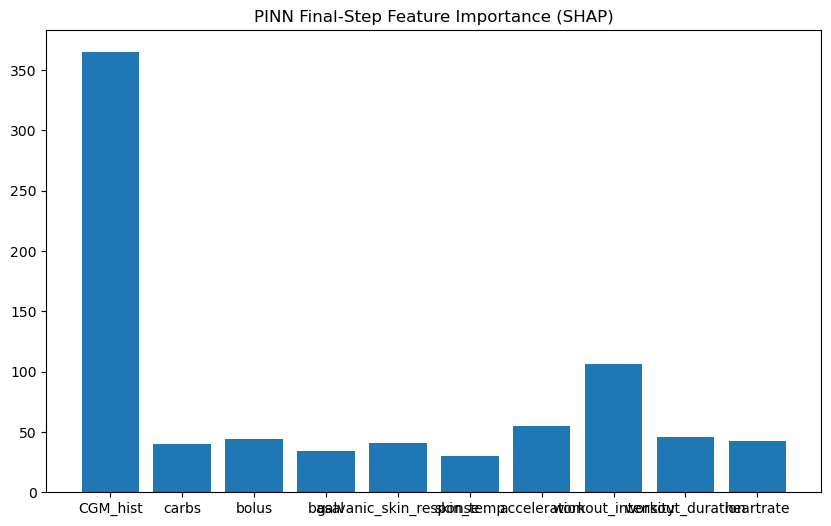

PINN model ready.


In [16]:

# Minimal PINN cell with improved physics enforcement, insulin-consistency,
# parameter positivity, warmup scheduling, better logging, and minor diagnostics.
# NOTE: Two-Phase Training (MSE -> Fine-Tuned Hybrid)

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import math
import random
import subprocess
import sys
import shap
import matplotlib.pyplot as plt

# ---------------------------
# Quick config
# ---------------------------
EPOCHS_BERGMAN = 15
EPOCHS_PINN_PHASE_1 = 15  # Standard MSE training
EPOCHS_PINN_PHASE_2 = 15  # Fine-tuning with Hybrid Loss
BATCH = 32
PINN_BATCH = 32
#LR_PHASE_1 = 0.0008877622404195946  # test with best lr found
LR_PHASE_1 = 0.000472531330206987  # test with best lr found PCA
#LR_PHASE_2 = 2.253626643937941e-05        # test with best lr found
LR_PHASE_2 = 1.3383505722003896e-05       # test with best lr found PCA
#LAMBDA_PHYS = 1.9555783277653451
LAMBDA_PHYS = 0.5957388801349519 # PCA
#LAMBDA_I_CONS = 0.0844046891793313
LAMBDA_I_CONS = 0.014673126336742282 # PCA
LEARN_BERGMAN_DURING_PINN = True
RANDOM_SEED = 42
LSTM_UNITS = 128
DENSE_UNITS = 96



np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ---------------------------
# Convenience / units
# ---------------------------
n_feats = 1 + len(feat_cols)
dt_minutes = 5.0
dt_scale = dt_minutes / dt_minutes

cg_min = float(cg_scaler.data_min_[0])
cg_max = float(cg_scaler.data_max_[0])
cg_range = cg_max - cg_min if cg_max > cg_min else 1.0

def inv_cgm_scaled_tf(x_scaled):
    """Convert scaled CGM [0,1] -> mg/dL (TensorFlow tensor)."""
    x = tf.cast(x_scaled, tf.float32)
    return x * tf.cast(cg_range, tf.float32) + tf.cast(cg_min, tf.float32)

def inv_cgm_scaled_np(x_scaled_np):
    return x_scaled_np * cg_range + cg_min

# ---------------------------
# Helper: stable invert softplus
# ---------------------------
def _raw_from_positive_init(init_val):
    v = float(max(init_val, 1e-8))
    return float(np.log(np.expm1(v)))

# ---------------------------
# Build windows for Bergman fit
# ---------------------------
G_inits = []; carb_fut = []; bolus_fut = []; y_true_mg_windows = []

#for sid, info in per_subject_train.items():
for sid, info in per_subject_train_pca.items():  # use PCA-transformed data for consistency
    subj = per_subject[sid]
    Xs = info['X']; ys = info['y']
    n_windows = Xs.shape[0]
    if n_windows == 0: continue

    y_scaled = ys.reshape(n_windows, N_OUT)
    y_mg = cg_scaler.inverse_transform(y_scaled.reshape(-1,1)).reshape(-1, N_OUT)
    G_init = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]

    bolus_mat = np.zeros((n_windows, N_OUT))
    carb_mat = np.zeros((n_windows, N_OUT))
    for w in range(n_windows):
        start = N_IN + w
        bolus_mat[w, :] = subj['bolus'].values[start:start+N_OUT]
        carb_mat[w, :] = subj['carbs'].values[start:start+N_OUT]

    G_inits.append(G_init)
    carb_fut.append(carb_mat)
    bolus_fut.append(bolus_mat)
    y_true_mg_windows.append(y_mg)

if len(G_inits) > 0:
    G_inits = np.concatenate(G_inits, axis=0)
    carb_fut = np.vstack(carb_fut)
    bolus_fut = np.vstack(bolus_fut)
    y_true_mg_windows = np.vstack(y_true_mg_windows)
else:
    G_inits = np.zeros((0,))
    carb_fut = np.zeros((0, N_OUT))
    bolus_fut = np.zeros((0, N_OUT))
    y_true_mg_windows = np.zeros((0, N_OUT))

print("Bergman fit windows:", G_inits.shape[0])

# ---------------------------
# Initialize Bergman parameters
# ---------------------------
init_p1 = 0.01; init_p2 = 0.01; init_p3 = 0.01; init_k_i = 0.1
init_Gb = float(np.median(G_inits) if G_inits.size>0 else 100.0)

p1_raw = tf.Variable(_raw_from_positive_init(init_p1), dtype=tf.float32, name='p1_raw')
p2_raw = tf.Variable(_raw_from_positive_init(init_p2), dtype=tf.float32, name='p2_raw')
p3_raw = tf.Variable(_raw_from_positive_init(init_p3), dtype=tf.float32, name='p3_raw')
k_i_raw = tf.Variable(_raw_from_positive_init(init_k_i), dtype=tf.float32, name='k_i_raw')
Gb_raw = tf.Variable(_raw_from_positive_init(max(init_Gb, 1e-3)), dtype=tf.float32, name='Gb_raw')

opt_b = tf.keras.optimizers.Adam(learning_rate=1e-2)

def _positive_params_from_raw(p1_r, p2_r, p3_r, k_r, Gb_r):
    p1v = tf.nn.softplus(p1_r) + 1e-9
    p2v = tf.nn.softplus(p2_r) + 1e-9
    p3v = tf.nn.softplus(p3_r) + 1e-9
    kv  = tf.nn.softplus(k_r) + 1e-9
    Gbv = tf.nn.softplus(Gb_r) + 1e-6
    return p1v, p2v, p3v, kv, Gbv

@tf.function
def bergman_simulate_tf(G0, bolus_mat_tf, carb_mat_tf, p1v, p2v, p3v, k_iv, Gbv):
    batch = tf.shape(G0)[0]
    G = tf.cast(G0, tf.float32)
    I = tf.zeros_like(G, dtype=tf.float32)
    out = tf.TensorArray(tf.float32, size=N_OUT)
    exp_k = tf.exp(-k_iv)
    for t in tf.range(N_OUT):
        bol = tf.cast(bolus_mat_tf[:, t], tf.float32)
        carb = tf.cast(carb_mat_tf[:, t], tf.float32)
        I = I * exp_k + bol
        dG = -p1v * (G - Gbv) - p2v * I + p3v * carb
        G = G + dG * dt_scale
        out = out.write(t, G)
    Gs = tf.transpose(out.stack(), perm=[1,0])
    return Gs

# ---------------------------
# Fit Bergman params (pre-fit)
# ---------------------------
if G_inits.shape[0] > 0:
    dataset = tf.data.Dataset.from_tensor_slices((
        G_inits.astype(np.float32), bolus_fut.astype(np.float32),
        carb_fut.astype(np.float32), y_true_mg_windows.astype(np.float32)
    )).shuffle(10000, seed=RANDOM_SEED).batch(BATCH).prefetch(1)

    for epoch in range(EPOCHS_BERGMAN):
        epoch_loss = 0.0; n = 0
        for G0_b, bol_b, carb_b, y_b in dataset:
            with tf.GradientTape() as tape:
                p1v, p2v, p3v, k_iv, Gbv = _positive_params_from_raw(p1_raw, p2_raw, p3_raw, k_i_raw, Gb_raw)
                pred = bergman_simulate_tf(G0_b, bol_b, carb_b, p1v, p2v, p3v, k_iv, Gbv)
                loss = tf.reduce_mean(tf.square(pred - y_b))
            grads = tape.gradient(loss, [p1_raw, p2_raw, p3_raw, k_i_raw, Gb_raw])
            opt_b.apply_gradients(zip(grads, [p1_raw, p2_raw, p3_raw, k_i_raw, Gb_raw]))
            epoch_loss += float(loss.numpy()); n += 1
        print(f"bergman epoch {epoch+1}/{EPOCHS_BERGMAN}, loss={epoch_loss/max(1,n):.4f}")
else:
    print("No training windows for Bergman fit.")

p1_fit, p2_fit, p3_fit, k_i_fit, Gb_fit = _positive_params_from_raw(p1_raw, p2_raw, p3_raw, k_i_raw, Gb_raw)
bergman_params = (float(p1_fit.numpy()), float(p2_fit.numpy()), float(p3_fit.numpy()), float(k_i_fit.numpy()), float(Gb_fit.numpy()))
print("Fitted bergman params:", bergman_params)

# ---------------------------
# PINN Model
# ---------------------------
class PINN_LSTM(tf.keras.Model):
    def __init__(self, n_in, n_feats, n_out, phys_weight=1.0, learn_bergman=False, init_params=None):
        super().__init__()
        self.n_out = n_out
        self.phys_weight = phys_weight
        self.encoder = layers.LSTM(LSTM_UNITS)
        self.hd1 = layers.Dense(DENSE_UNITS, activation='relu')
        self.out = layers.Dense(n_out * 2, activation='linear')
        self.learn_bergman = learn_bergman

        # USE PASSED PARAMETERS OR FALLBACK TO GLOBAL
        if init_params is not None:
            p1, p2, p3, ki, Gb = init_params
        else:
            # Fallback if running outside optuna
            p1, p2, p3, ki, Gb = bergman_params

        p1_init_raw = _raw_from_positive_init(bergman_params[0])
        p2_init_raw = _raw_from_positive_init(bergman_params[1])
        p3_init_raw = _raw_from_positive_init(bergman_params[2])
        k_i_init_raw = _raw_from_positive_init(bergman_params[3])
        Gb_init_raw = _raw_from_positive_init(max(bergman_params[4], 1e-3))

        self.p1_raw = tf.Variable(p1_init_raw, dtype=tf.float32, trainable=bool(learn_bergman), name='p1_pin_raw')
        self.p2_raw = tf.Variable(p2_init_raw, dtype=tf.float32, trainable=bool(learn_bergman), name='p2_pin_raw')
        self.p3_raw = tf.Variable(p3_init_raw, dtype=tf.float32, trainable=bool(learn_bergman), name='p3_pin_raw')
        self.k_i_raw = tf.Variable(k_i_init_raw, dtype=tf.float32, trainable=bool(learn_bergman), name='k_i_pin_raw')
        self.Gb_raw = tf.Variable(Gb_init_raw, dtype=tf.float32, trainable=bool(learn_bergman), name='Gb_pin_raw')

    def _bergman_params(self):
        return _positive_params_from_raw(self.p1_raw, self.p2_raw, self.p3_raw, self.k_i_raw, self.Gb_raw)

    def call(self, inputs, training=False):
        x = self.encoder(inputs)
        x = self.hd1(x)
        out = self.out(x)
        out = tf.reshape(out, (-1, self.n_out, 2))
        return out[:, :, 0], out[:, :, 1]

    @property
    def bergman_param_values(self):
        return self._bergman_params()
X_tr_all = X_tr_all_pca  # use PCA-transformed data
y_tr_all = y_tr_all_pca  # use PCA-transformed data
# ensure n_feats matches PCA-transformed data
if X_tr_all.ndim == 3:
    n_feats = X_tr_all.shape[2]
else:
    # if flattened, recover features
    n_feats = int(X_tr_all.shape[1] / N_IN)

pin_model = PINN_LSTM(N_IN, n_feats, N_OUT, phys_weight=LAMBDA_PHYS, learn_bergman=LEARN_BERGMAN_DURING_PINN)
optimizer_pinn = tf.keras.optimizers.Adam(learning_rate=LR_PHASE_1)
mse_loss_fn = tf.keras.losses.MeanSquaredError()
mae_loss_fn = tf.keras.losses.MeanAbsoluteError()
rmse_loss_fn = lambda y_true, y_pred: tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)
huber_loss_fn = tf.keras.losses.Huber(delta=1.0)

# ---------------------------
# Build PINN Dataset
# ---------------------------



#if X_tr_all.shape[0] > 0:
if X_tr_all_pca.shape[0] > 0:
    bolus_tr = []; carb_tr = []; G0_tr = []
    for sid in train_ids:
        #info = per_subject_train.get(sid, None)
        info = per_subject_train_pca.get(sid, None)  # PCA-transformed data
        if info is None or info['X'].shape[0] == 0: continue
        subj = per_subject[sid]
        for w in range(info['X'].shape[0]):
            start = N_IN + w
            bolus_tr.append(subj['bolus'].values[start:start+N_OUT])
            carb_tr.append(subj['carbs'].values[start:start+N_OUT])
            G0_tr.append(subj['CGM_smoothed'].values[N_IN-1 + w])

    ds_pinn = tf.data.Dataset.from_tensor_slices((
        X_tr_all.astype(np.float32), y_tr_all.reshape(y_tr_all.shape[0], N_OUT).astype(np.float32),
        np.array(G0_tr).astype(np.float32), np.vstack(bolus_tr).astype(np.float32), np.vstack(carb_tr).astype(np.float32)
    )).shuffle(10000, seed=RANDOM_SEED).batch(PINN_BATCH).prefetch(2)
else:
    ds_pinn = None

# ---------------------------
# Helper Functions
# ---------------------------
@tf.function
def insulin_effect_from_bolus(bolus_batch, k_iv):
    batch = tf.shape(bolus_batch)[0]
    I = tf.zeros((batch,), tf.float32)
    out = tf.TensorArray(tf.float32, size=N_OUT)
    exp_k = tf.exp(-k_iv)
    for t in tf.range(N_OUT):
        I = I * exp_k + tf.cast(bolus_batch[:, t], tf.float32)
        out = out.write(t, I)
    return tf.transpose(out.stack(), perm=[1,0])

# ---------------------------
# LOSS DEFINITIONS
# ---------------------------
# Globals for Hybrid Loss
a = 1.0; b = 1.0; eps = 1e-6
T_mgdl = 112.5; C = 1.0; w_left = 1.5; w_right = 1.0
min_v = cg_min; scale_range = cg_range; alpha_l1 = 0.6

def _to_mgdl(tensor_scaled):
    return tf.clip_by_value(tensor_scaled * scale_range + min_v, 1e-3, 1000.0)

def _zone_cost(bg_mgdl):
    bg = tf.cast(bg_mgdl, tf.float32)
    diff2 = tf.square(tf.math.log(bg + eps) - tf.math.log(tf.cast(T_mgdl, tf.float32) + eps))
    left_mask = tf.cast(bg < T_mgdl, dtype=bg.dtype)
    return C * (w_left * diff2 * left_mask + w_right * diff2 * (1.0 - left_mask))

def _slope_cost(delta_bg_mgdl):
    delta = tf.cast(delta_bg_mgdl, tf.float32) / 18.0
    neg_mask = tf.cast(delta < 0.0, dtype=delta.dtype)
    return (2.0 * b) * tf.square(delta) * neg_mask + a * tf.square(delta) * (1.0 - neg_mask)

def lstm_paper_loss_hybrid(y_true, y_pred):
    # Hybrid Data Loss
    y_true_mg = _to_mgdl(tf.cast(y_true, tf.float32))
    y_pred_mg = _to_mgdl(tf.cast(y_pred, tf.float32))
    delta_true = y_true_mg - tf.concat([y_true_mg[:, :1] * 0.0, y_true_mg[:, :-1]], axis=1)

    weights = _zone_cost(y_true_mg) + _slope_cost(delta_true) + 1.0
    weights_norm = weights / (tf.reduce_mean(weights) + 1e-6)

    mse_weighted = tf.reduce_mean(weights_norm * tf.square(y_pred_mg - y_true_mg))
    l1_mg = tf.reduce_mean(tf.abs(y_pred_mg - y_true_mg)) / (scale_range + 1e-6)
    loss = mse_weighted + alpha_l1 * l1_mg
    return tf.where(tf.math.is_finite(loss), loss, tf.constant(1e6, dtype=loss.dtype))


# ==========================================================
# Compound Glucose Metric – TF differentiable loss version
# ==========================================================
@tf.function
def compound_glucose_tf_loss(y_true_scaled, y_pred_scaled):
    """
    Differentiable surrogate for:
    - RMSE
    - Temporal Gain
    - G-Mean (converted to soft differentiable approximation)

    All ops are TF tensors so gradients flow.
    """

    # Convert to mg/dL
    y_true = _to_mgdl(y_true_scaled)
    y_pred = _to_mgdl(y_pred_scaled)

    # ---- RMSE (standard differentiable) ----
    rmse = tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)

    # ---- Temporal Gain surrogate ----
    # Original TG uses cross-correlation & argmax (non-differentiable).
    # Surrogate: penalize prediction *temporal misalignment* via slope mismatch.
    dt_true  = y_true[:, 1:] - y_true[:, :-1]
    dt_pred  = y_pred[:, 1:] - y_pred[:, :-1]
    temporal_penalty = tf.reduce_mean(tf.square(dt_pred - dt_true))

    # ---- G-Mean surrogate ----
    # Convert hypo/mid/hyper thresholds to smooth probabilistic labels
    hypo_thr  = tf.constant(70.2,  tf.float32)   # 3.9 mmol/L
    hyper_thr = tf.constant(180.0, tf.float32)   # 10 mmol/L

    # Soft class probabilities (sigmoid band)
    p_hypo_true = tf.sigmoid(-(y_true - hypo_thr)/10.0)
    p_hyper_true = tf.sigmoid((y_true - hyper_thr)/10.0)
    p_norm_true = 1.0 - p_hypo_true - p_hyper_true

    p_hypo_pred = tf.sigmoid(-(y_pred - hypo_thr)/10.0)
    p_hyper_pred = tf.sigmoid((y_pred - hyper_thr)/10.0)
    p_norm_pred = 1.0 - p_hypo_pred - p_hyper_pred

    # Class-wise recall surrogate
    recall_hypo  = tf.reduce_mean(p_hypo_pred  * p_hypo_true)
    recall_norm  = tf.reduce_mean(p_norm_pred  * p_norm_true)
    recall_hyper = tf.reduce_mean(p_hyper_pred * p_hyper_true)

    # Avoid log(0)
    eps = 1e-8
    g_mean = tf.exp(
        (tf.math.log(recall_hypo + eps) +
         tf.math.log(recall_norm + eps) +
         tf.math.log(recall_hyper + eps)) / 3.0
    )

    # Combine into compound metric (lower is better)
    compound_loss = (
        (rmse / 100.0) +
        (temporal_penalty) +
        (1.0 - g_mean)     # maximize g-mean → minimize (1 - gmean)
    )


    return compound_loss



# ---------------------------
# Combined Loss Component Calculator
# ---------------------------
# We pass `data_loss_fn` as an argument to switch between MSE and Hybrid
@tf.function
def pinn_loss_components(Xb, yb_scaled, G0b, bolb, carb_b, model, phys_weight, lambda_I, data_loss_fn):
    G_pred_scaled, I_pred = model(Xb, training=True)

    # Calculate Data Loss using the passed function (MSE or Hybrid)
    loss_data = data_loss_fn(yb_scaled, G_pred_scaled)

    p1v, p2v, p3v, kiv, Gb_v = model.bergman_param_values
    G_sim = bergman_simulate_tf(G0b, bolb, carb_b, p1v, p2v, p3v, kiv, Gb_v)
    #loss_phys = tf.reduce_mean(tf.square(inv_cgm_scaled_tf(G_pred_scaled) - G_sim))
    loss_phys = tf.reduce_mean(tf.square(inv_cgm_scaled_tf(G_pred_scaled) - G_sim)) / (scale_range**2 + 1e-9)
    loss_I_cons = tf.reduce_mean(tf.square(I_pred - insulin_effect_from_bolus(bolb, kiv)))

    total = loss_data + phys_weight * loss_phys + lambda_I * loss_I_cons
    return total, loss_data, loss_phys, loss_I_cons

# ---------------------------
# TRAINING LOOPS
# ---------------------------
if ds_pinn is not None:
    # --- PHASE 1: Standard MSE Training ---
    print(f"\n=== Phase 1: Training with RMSE Loss ({EPOCHS_PINN_PHASE_1} epochs) ===")
    #warmup_epochs = max(1, int(0.1 * EPOCHS_PINN_PHASE_1))
    warmup_epochs = max(1, int(0.3 * EPOCHS_PINN_PHASE_1))
    for epoch in range(EPOCHS_PINN_PHASE_1):
        phys_weight = float(LAMBDA_PHYS * min(1.0, (epoch + 1) / max(1, warmup_epochs)))
        total_loss = 0.0; n = 0
        for Xb, yb_scaled, G0b, bolb, carb_b in ds_pinn:
            with tf.GradientTape() as tape:
                # Pass standard MSE loss
                total, ld, lp, li = pinn_loss_components(
                    Xb, yb_scaled, G0b, bolb, carb_b, pin_model, phys_weight, LAMBDA_I_CONS, rmse_loss_fn)
            grads = tape.gradient(total, pin_model.trainable_variables)
            grads, _ = tf.clip_by_global_norm(grads, 5.0)
            optimizer_pinn.apply_gradients(zip(grads, pin_model.trainable_variables))
            total_loss += float(total.numpy()); n += 1
        print(f"Phase 1 Epoch {epoch+1}/{EPOCHS_PINN_PHASE_1}, loss={total_loss/n:.4f}")

    # --- PHASE 2: Fine-Tuning with Hybrid Loss ---
    print(f"\n=== Phase 2: Fine-Tuning with Hybrid Loss ({EPOCHS_PINN_PHASE_2} epochs) ===")
    # Update optimizer LR for fine-tuning
    optimizer_pinn.learning_rate.assign(LR_PHASE_2)

    for epoch in range(EPOCHS_PINN_PHASE_2):
        # phys_weight stays at max during fine-tuning
        phys_weight = LAMBDA_PHYS
        total_loss = 0.0; n = 0
        last_data = 0.0; last_phys = 0.0
        for Xb, yb_scaled, G0b, bolb, carb_b in ds_pinn:
            with tf.GradientTape() as tape:
                # Pass HYBRID loss
                total, ld, lp, li = pinn_loss_components(
                    Xb, yb_scaled, G0b, bolb, carb_b, pin_model, phys_weight, LAMBDA_I_CONS, compound_glucose_tf_loss)
            grads = tape.gradient(total, pin_model.trainable_variables)
            grads, _ = tf.clip_by_global_norm(grads, 5.0)
            optimizer_pinn.apply_gradients(zip(grads, pin_model.trainable_variables))
            total_loss += float(total.numpy()); n += 1
            last_data = float(ld.numpy()); last_phys = float(lp.numpy())

        if (epoch+1) % 5 == 0 or epoch == 0:
            try:
                p1v, p2v, p3v, kiv, Gbv = pin_model.bergman_param_values
                p1f, p2f, p3f, kf, Gbf = (float(p1v.numpy()), float(p2v.numpy()), float(p3v.numpy()), float(kiv.numpy()), float(Gbv.numpy()))
            except: p1f=p2f=p3f=kf=Gbf=None
            print(f"Phase 2 Epoch {epoch+1}/{EPOCHS_PINN_PHASE_2}, loss={total_loss/n:.4f} (data_hybrid {last_data:.4f} phys {last_phys:.4f}) params={(p1f, p2f, p3f, kf, Gbf)}")
else:
    print("No training windows available for PINN.")

# ---------------------------
# Predict Wrapper
# ---------------------------
def pinn_predict_on_subject(sid):
    #info = per_subject_test.get(sid, None)
    info = per_subject_test_pca.get(sid, None)  # test on PCA-transformed data
    if info is None or info['X'].shape[0] == 0: return np.zeros((0, N_OUT, 1))
    Xs = info['X'].astype(np.float32)
    G_scaled, I_pred = pin_model(Xs, training=False)
    G_scaled_np = G_scaled.numpy()
    return G_scaled_np.reshape(G_scaled_np.shape[0], N_OUT, 1)

if LEARN_BERGMAN_DURING_PINN:
    try:
        p1v, p2v, p3v, k_iv, Gb_v = pin_model.bergman_param_values
        bergman_params = (float(p1v.numpy()), float(p2v.numpy()), float(p3v.numpy()), float(k_iv.numpy()), float(Gb_v.numpy()))
        print("Final bergman_params:", bergman_params)
    except: pass

# ---------------------------
# SHAP Analysis
# ---------------------------
def flatten_windows(X): return X.reshape(X.shape[0], -1)
#if X_tr_all.shape[0] > 0:
if X_tr_all_pca.shape[0] > 0:
    #X_flat = flatten_windows(X_tr_all)
    X_flat = flatten_windows(X_tr_all_pca)
    bg_idx = np.random.choice(X_flat.shape[0], size=min(100, X_flat.shape[0]), replace=False)
    X_bg = X_flat[bg_idx]

    def pinn_finalstep_predict_flat(Xflat_batch):
        m = Xflat_batch.shape[0]
        G_scaled, _ = pin_model(Xflat_batch.reshape(m, N_IN, n_feats).astype(np.float32), training=False)
        return inv_cgm_scaled_np(G_scaled[:, -1].numpy())

    try:
        deepex = shap.DeepExplainer(lambda x: inv_cgm_scaled_tf(pin_model(x)[0][:, -1]).numpy(), X_bg.reshape(X_bg.shape[0], N_IN, n_feats).astype(np.float32))
        shap_arr = np.array(deepex.shap_values(X_flat[np.random.choice(X_flat.shape[0], size=min(30, X_flat.shape[0]), replace=False)].reshape(-1, N_IN, n_feats)))
        if isinstance(shap_arr, list): shap_arr = shap_arr[0]
    except:
        explainer = shap.KernelExplainer(pinn_finalstep_predict_flat, X_bg[:min(30, X_bg.shape[0])])
        shap_arr = np.array(explainer.shap_values(X_flat[np.random.choice(X_flat.shape[0], size=min(30, X_flat.shape[0]), replace=False)], nsamples=50))

    feature_time_sum = np.mean(np.abs(shap_arr), axis=0).reshape(N_IN, n_feats).sum(axis=0)
    shap_feature_scores = {(['CGM_hist'] + feat_cols)[i]: float(feature_time_sum[i]) for i in range(n_feats)}
    print("SHAP Importance:", shap_feature_scores)

    plt.figure(figsize=(10, 6))
    plt.bar(list(shap_feature_scores.keys()), list(shap_feature_scores.values()))
    plt.title('PINN Final-Step Feature Importance (SHAP)')
    plt.show()
else:
    print("No training data for SHAP.")
print("PINN model ready.")

## Hyperparameter tuning - Optuna - PINN:

In [18]:
# ------------------------------------------------------------------------------
# Hyperparameter Tuning for PINN using Optuna
# ------------------------------------------------------------------------------
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import math
import random
import subprocess
import sys

# Ensure Optuna is installed
try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"], stdout=subprocess.DEVNULL)
    import optuna

# Ensure Shap is installed (from original code)
try:
    import shap
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"], stdout=subprocess.DEVNULL)
    import shap

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---------------------------
# Global Config & Reproducibility
# ---------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

#PCA:
X_tr_all = X_tr_all_pca  # use PCA-transformed data
y_tr_all = y_tr_all_pca  # use PCA-transformed data
if X_tr_all.ndim == 3:
    n_feats = X_tr_all.shape[2]
else:
    n_feats = int(X_tr_all.shape[1] / N_IN) # recover features if flattened

per_subject_train = per_subject_train_pca  # use PCA-transformed data
per_subject_test = per_subject_test_pca    # use PCA-transformed data


# Fixed Physics Constants
dt_minutes = 5.0
dt_scale = dt_minutes / dt_minutes
cg_min = float(cg_scaler.data_min_[0])
cg_max = float(cg_scaler.data_max_[0])
cg_range = cg_max - cg_min if cg_max > cg_min else 1.0
n_feats = 1 + len(feat_cols)

# ---------------------------
# Helper Functions
# ---------------------------
def inv_cgm_scaled_tf(x_scaled):
    x = tf.cast(x_scaled, tf.float32)
    return x * tf.cast(cg_range, tf.float32) + tf.cast(cg_min, tf.float32)

def inv_cgm_scaled_np(x_scaled_np):
    return x_scaled_np * cg_range + cg_min

def _raw_from_positive_init(init_val):
    v = float(max(init_val, 1e-8))
    return float(np.log(np.expm1(v)))

def _positive_params_from_raw(p1_r, p2_r, p3_r, k_r, Gb_r):
    p1v = tf.nn.softplus(p1_r) + 1e-9
    p2v = tf.nn.softplus(p2_r) + 1e-9
    p3v = tf.nn.softplus(p3_r) + 1e-9
    kv  = tf.nn.softplus(k_r) + 1e-9
    Gbv = tf.nn.softplus(Gb_r) + 1e-6
    return p1v, p2v, p3v, kv, Gbv

@tf.function
def bergman_simulate_tf(G0, bolus_mat_tf, carb_mat_tf, p1v, p2v, p3v, k_iv, Gbv):
    # Standard Bergman simulation
    G = tf.cast(G0, tf.float32)
    I = tf.zeros_like(G, dtype=tf.float32)
    out = tf.TensorArray(tf.float32, size=N_OUT)
    exp_k = tf.exp(-k_iv)
    for t in tf.range(N_OUT):
        bol = tf.cast(bolus_mat_tf[:, t], tf.float32)
        carb = tf.cast(carb_mat_tf[:, t], tf.float32)
        I = I * exp_k + bol
        dG = -p1v * (G - Gbv) - p2v * I + p3v * carb
        G = G + dG * dt_scale
        out = out.write(t, G)
    return tf.transpose(out.stack(), perm=[1,0])

@tf.function
def insulin_effect_from_bolus(bolus_batch, k_iv):
    batch = tf.shape(bolus_batch)[0]
    I = tf.zeros((batch,), tf.float32)
    out = tf.TensorArray(tf.float32, size=N_OUT)
    exp_k = tf.exp(-k_iv)
    for t in tf.range(N_OUT):
        I = I * exp_k + tf.cast(bolus_batch[:, t], tf.float32)
        out = out.write(t, I)
    return tf.transpose(out.stack(), perm=[1,0])

# ---------------------------
# Loss Definitions (MSE & Hybrid)
# ---------------------------
a = 1.0; b = 1.0; eps = 1e-6
T_mgdl = 112.5; C = 1.0; w_left = 1.5; w_right = 1.0
min_v = cg_min; scale_range = cg_range; alpha_l1 = 0.6

mse_loss_fn = tf.keras.losses.MeanSquaredError()
rmse_loss_fn = lambda y_true, y_pred: tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)

def _to_mgdl(tensor_scaled):
    return tf.clip_by_value(tensor_scaled * scale_range + min_v, 1e-3, 1000.0)

def _zone_cost(bg_mgdl):
    bg = tf.cast(bg_mgdl, tf.float32)
    diff2 = tf.square(tf.math.log(bg + eps) - tf.math.log(tf.cast(T_mgdl, tf.float32) + eps))
    left_mask = tf.cast(bg < T_mgdl, dtype=bg.dtype)
    return C * (w_left * diff2 * left_mask + w_right * diff2 * (1.0 - left_mask))

def _slope_cost(delta_bg_mgdl):
    delta = tf.cast(delta_bg_mgdl, tf.float32) / 18.0
    neg_mask = tf.cast(delta < 0.0, dtype=delta.dtype)
    return (2.0 * b) * tf.square(delta) * neg_mask + a * tf.square(delta) * (1.0 - neg_mask)

def lstm_paper_loss_hybrid(y_true, y_pred):
    # Hybrid Data Loss
    y_true_mg = _to_mgdl(tf.cast(y_true, tf.float32))
    y_pred_mg = _to_mgdl(tf.cast(y_pred, tf.float32))
    delta_true = y_true_mg - tf.concat([y_true_mg[:, :1] * 0.0, y_true_mg[:, :-1]], axis=1)

    weights = _zone_cost(y_true_mg) + _slope_cost(delta_true) + 1.0
    weights_norm = weights / (tf.reduce_mean(weights) + 1e-6)

    mse_weighted = tf.reduce_mean(weights_norm * tf.square(y_pred_mg - y_true_mg))
    l1_mg = tf.reduce_mean(tf.abs(y_pred_mg - y_true_mg)) / (scale_range + 1e-6)
    loss = mse_weighted + alpha_l1 * l1_mg
    return tf.where(tf.math.is_finite(loss), loss, tf.constant(1e6, dtype=loss.dtype))

@tf.function
def compound_glucose_tf_loss(y_true_scaled, y_pred_scaled):
    # Differentiable Compound Loss
    y_true = _to_mgdl(y_true_scaled)
    y_pred = _to_mgdl(y_pred_scaled)
    
    # RMSE
    rmse = tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)) + 1e-8)
    
    # Temporal Gain Surrogate (Slope matching)
    dt_true  = y_true[:, 1:] - y_true[:, :-1]
    dt_pred  = y_pred[:, 1:] - y_pred[:, :-1]
    temporal_penalty = tf.reduce_mean(tf.square(dt_pred - dt_true))
    
    # G-Mean Surrogate
    hypo_thr  = tf.constant(70.2,  tf.float32)
    hyper_thr = tf.constant(180.0, tf.float32)
    p_hypo_true = tf.sigmoid(-(y_true - hypo_thr)/10.0)
    p_hyper_true = tf.sigmoid((y_true - hyper_thr)/10.0)
    p_norm_true = 1.0 - p_hypo_true - p_hyper_true
    p_hypo_pred = tf.sigmoid(-(y_pred - hypo_thr)/10.0)
    p_hyper_pred = tf.sigmoid((y_pred - hyper_thr)/10.0)
    p_norm_pred = 1.0 - p_hypo_pred - p_hyper_pred
    recall_hypo  = tf.reduce_mean(p_hypo_pred  * p_hypo_true)
    recall_norm  = tf.reduce_mean(p_norm_pred  * p_norm_true)
    recall_hyper = tf.reduce_mean(p_hyper_pred * p_hyper_true)
    g_mean = tf.exp((tf.math.log(recall_hypo + 1e-8) + tf.math.log(recall_norm + 1e-8) + tf.math.log(recall_hyper + 1e-8)) / 3.0)
    
    #return (rmse / 100.0) + temporal_penalty + (1.0 - g_mean)
    return (rmse / 100.0) + (1.0 - g_mean)
# ---------------------------
# 1. Pre-Processing: Prepare Data & Fit Initial Bergman Params
# ---------------------------
# We do this ONCE before tuning to save time.
print("Preparing Data and Initial Bergman Fit...")

# Construct full arrays from subject dicts
G_inits = []; carb_fut = []; bolus_fut = []; y_true_mg_windows = []
# Also need these aligned with X_tr_all for PINN training
G0_tr_all = []; bolus_tr_all = []; carb_tr_all = []

# Assuming X_tr_all order matches train_ids iteration roughly, 
# but safest to reconstruct based on known Train IDs
# Note: For strict alignment with X_tr_all, we assume X_tr_all was built iterating train_ids
for sid in train_ids:
    info = per_subject_train.get(sid, None)
    if info is None or info['X'].shape[0] == 0: continue
    subj = per_subject[sid]
    # For Bergman Fit
    y_scaled = info['y'].reshape(info['y'].shape[0], N_OUT)
    y_mg = cg_scaler.inverse_transform(y_scaled.reshape(-1,1)).reshape(-1, N_OUT)
    G_init = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + info['X'].shape[0]]
    
    bolus_mat = np.zeros((info['X'].shape[0], N_OUT))
    carb_mat = np.zeros((info['X'].shape[0], N_OUT))
    for w in range(info['X'].shape[0]):
        start = N_IN + w
        bolus_mat[w, :] = subj['bolus'].values[start:start+N_OUT]
        carb_mat[w, :] = subj['carbs'].values[start:start+N_OUT]
    
    G_inits.append(G_init)
    carb_fut.append(carb_mat)
    bolus_fut.append(bolus_mat)
    y_true_mg_windows.append(y_mg)
    
    # Store for PINN training
    G0_tr_all.append(G_init)
    bolus_tr_all.append(bolus_mat)
    carb_tr_all.append(carb_mat)

G_inits = np.concatenate(G_inits, axis=0) if G_inits else np.zeros((0,))
carb_fut = np.vstack(carb_fut) if len(carb_fut)>0 else np.zeros((0, N_OUT))
bolus_fut = np.vstack(bolus_fut) if len(bolus_fut)>0 else np.zeros((0, N_OUT))
y_true_mg_windows = np.vstack(y_true_mg_windows) if len(y_true_mg_windows)>0 else np.zeros((0, N_OUT))

G0_tr_all = np.concatenate(G0_tr_all, axis=0)
bolus_tr_all = np.vstack(bolus_tr_all)
carb_tr_all = np.vstack(carb_tr_all)

# --- Initial Bergman Fit ---
init_p1=0.01; init_p2=0.01; init_p3=0.01; init_k_i=0.1
init_Gb = float(np.median(G_inits) if G_inits.size>0 else 100.0)
p1_raw = tf.Variable(_raw_from_positive_init(init_p1), dtype=tf.float32)
p2_raw = tf.Variable(_raw_from_positive_init(init_p2), dtype=tf.float32)
p3_raw = tf.Variable(_raw_from_positive_init(init_p3), dtype=tf.float32)
k_i_raw = tf.Variable(_raw_from_positive_init(init_k_i), dtype=tf.float32)
Gb_raw = tf.Variable(_raw_from_positive_init(max(init_Gb, 1e-3)), dtype=tf.float32)
opt_b = tf.keras.optimizers.Adam(learning_rate=1e-2)

if G_inits.shape[0] > 0:
    ds_b = tf.data.Dataset.from_tensor_slices((
        G_inits.astype(np.float32), bolus_fut.astype(np.float32),
        carb_fut.astype(np.float32), y_true_mg_windows.astype(np.float32)
    )).shuffle(5000).batch(16)
    
    for epoch in range(1): # Keep pre-fit short
        for G0_b, bol_b, carb_b, y_b in ds_b:
            with tf.GradientTape() as tape:
                p1v, p2v, p3v, k_iv, Gbv = _positive_params_from_raw(p1_raw, p2_raw, p3_raw, k_i_raw, Gb_raw)
                pred = bergman_simulate_tf(G0_b, bol_b, carb_b, p1v, p2v, p3v, k_iv, Gbv)
                loss = tf.reduce_mean(tf.square(pred - y_b))
            grads = tape.gradient(loss, [p1_raw, p2_raw, p3_raw, k_i_raw, Gb_raw])
            opt_b.apply_gradients(zip(grads, [p1_raw, p2_raw, p3_raw, k_i_raw, Gb_raw]))

p1_fit, p2_fit, p3_fit, k_i_fit, Gb_fit = _positive_params_from_raw(p1_raw, p2_raw, p3_raw, k_i_raw, Gb_raw)
fitted_bergman_params = (float(p1_fit), float(p2_fit), float(p3_fit), float(k_i_fit), float(Gb_fit))
print("Initial Fitted Bergman Params:", fitted_bergman_params)

# ---------------------------
# 2. Optuna Objective Function
# ---------------------------

# Split Data for Training vs Validation during Tuning
# We split indices to keep X, y, and phys aux arrays aligned
indices = np.arange(X_tr_all.shape[0])
idx_train, idx_val = train_test_split(indices, test_size=0.2, random_state=42)

def create_pinn_model(trial, bergman_inits):
    """Factory to create PINN with tunable architecture."""
    # Hyperparams for Arch
    lstm_units = trial.suggest_int('lstm_units', 32, 128, step=32)
    dense_units = trial.suggest_int('dense_units', 32, 128, step=32)
    
    class PINN_Optuna(tf.keras.Model):
        def __init__(self, n_out):
            super().__init__()
            self.n_out = n_out
            self.encoder = layers.LSTM(lstm_units)
            self.hd1 = layers.Dense(dense_units, activation='relu')
            self.out = layers.Dense(n_out * 2, activation='linear')
            
            # Physics params (trainable)
            self.p1_raw = tf.Variable(_raw_from_positive_init(bergman_inits[0]), dtype=tf.float32, name='p1')
            self.p2_raw = tf.Variable(_raw_from_positive_init(bergman_inits[1]), dtype=tf.float32, name='p2')
            self.p3_raw = tf.Variable(_raw_from_positive_init(bergman_inits[2]), dtype=tf.float32, name='p3')
            self.k_i_raw = tf.Variable(_raw_from_positive_init(bergman_inits[3]), dtype=tf.float32, name='ki')
            self.Gb_raw = tf.Variable(_raw_from_positive_init(max(bergman_inits[4], 1e-3)), dtype=tf.float32, name='Gb')

        def _bergman_params(self):
            return _positive_params_from_raw(self.p1_raw, self.p2_raw, self.p3_raw, self.k_i_raw, self.Gb_raw)

        def call(self, inputs, training=False):
            x = self.encoder(inputs)
            x = self.hd1(x)
            out = self.out(x)
            out = tf.reshape(out, (-1, self.n_out, 2))
            return out[:, :, 0], out[:, :, 1]
            
        @property
        def bergman_param_values(self):
            return self._bergman_params()

    return PINN_Optuna(N_OUT)

def objective(trial):
    tf.keras.backend.clear_session()
    
    # --- Hyperparameters ---
    lr_phase_1 = trial.suggest_float('lr_phase_1', 1e-5, 1e-3, log=True)
    lr_phase_2 = trial.suggest_float('lr_phase_2', 1e-6, 1e-4, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    lambda_phys = trial.suggest_float('lambda_phys', 0.01, 2.0)
    lambda_i_cons = trial.suggest_float('lambda_i_cons', 0.01, 1.0)
    
    # --- Prepare Datasets (using pre-calculated splits) ---
    # Train
    ds_train = tf.data.Dataset.from_tensor_slices((
        X_tr_all[idx_train].astype(np.float32), 
        y_tr_all[idx_train].reshape(len(idx_train), N_OUT).astype(np.float32),
        G0_tr_all[idx_train].astype(np.float32),
        bolus_tr_all[idx_train].astype(np.float32),
        carb_tr_all[idx_train].astype(np.float32)
    )).shuffle(5000).batch(batch_size).prefetch(2)
    
    # Validation
    # For validation, we just need X and y to calc RMSE, but we pass phys data to keep loop structure consistent if needed
    X_val_t = tf.convert_to_tensor(X_tr_all[idx_val].astype(np.float32))
    y_val_t = tf.convert_to_tensor(y_tr_all[idx_val].reshape(len(idx_val), N_OUT).astype(np.float32))

    # --- Build Model ---
    model = create_pinn_model(trial, fitted_bergman_params)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_phase_1)
    #mse_fn = tf.keras.losses.MeanSquaredError()
    hybrid_loss_fn = lstm_paper_loss_hybrid
    huber_loss_fn = tf.keras.losses.Huber(delta=1.0)
    # --- Training Loop Helper ---
    @tf.function
    def train_step(Xb, yb, G0b, bolb, carb_b, phys_w, data_loss_func):
        with tf.GradientTape() as tape:
            G_pred, I_pred = model(Xb, training=True)
            loss_data = data_loss_func(yb, G_pred)
            
            p1, p2, p3, ki, Gb = model.bergman_param_values
            G_sim = bergman_simulate_tf(G0b, bolb, carb_b, p1, p2, p3, ki, Gb)
            loss_phys = tf.reduce_mean(tf.square(inv_cgm_scaled_tf(G_pred) - G_sim)) / (scale_range**2 + 1e-9)
            loss_icons = tf.reduce_mean(tf.square(I_pred - insulin_effect_from_bolus(bolb, ki)))
            
            total = loss_data + phys_w * loss_phys + lambda_i_cons * loss_icons
        
        grads = tape.gradient(total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return total

    # --- Phase 1: MSE Training ---
    # Shorten epochs for tuning speed, or use full if resources allow
    epochs_p1 = 10  # Reduced for demonstration/tuning speed. Original was 1? Increase for better tuning.
    for epoch in range(epochs_p1):
        # Warmup phys weight
        pw = float(lambda_phys * min(1.0, (epoch + 1) / 2))
        for Xb, yb, G0b, bolb, carbb in ds_train:
            train_step(Xb, yb, G0b, bolb, carbb, pw, rmse_loss_fn)

    # --- Phase 2: Hybrid Training ---
    optimizer.learning_rate.assign(lr_phase_2)
    epochs_p2 = 10 
    for epoch in range(epochs_p2):
        for Xb, yb, G0b, bolb, carbb in ds_train:
            train_step(Xb, yb, G0b, bolb, carbb, lambda_phys, compound_glucose_tf_loss)

    # --- Evaluation ---
    # Calculate Validation RMSE (standard metric)
    G_val_pred, _ = model(X_val_t, training=False)
    # Convert to mg/dL for interpretable error
    val_pred_mg = inv_cgm_scaled_tf(G_val_pred)
    val_true_mg = inv_cgm_scaled_tf(y_val_t)
    val_rmse = tf.sqrt(tf.reduce_mean(tf.square(val_pred_mg - val_true_mg)))
    
    return float(val_rmse.numpy())

# ---------------------------
# 3. Run Optimization
# ---------------------------
print("Starting Optuna Study...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30) # Adjust n_trials as needed

print("\nBest params:")
print(study.best_params)

print("\nRetraining best model on FULL training set...")
best = study.best_params



Preparing Data and Initial Bergman Fit...


[I 2025-12-05 15:18:56,521] A new study created in memory with name: no-name-a66b4cd2-7f2b-40f5-b11d-09399e16e370


Initial Fitted Bergman Params: (0.0048333811573684216, 3.274583650636487e-05, 0.004049508832395077, 2.5990235805511475, 154.48529052734375)
Starting Optuna Study...


[I 2025-12-05 15:26:57,979] Trial 0 finished with value: 13.62033462524414 and parameters: {'lr_phase_1': 0.00012213780214356178, 'lr_phase_2': 5.8740769444668155e-06, 'batch_size': 32, 'lambda_phys': 1.219438564214623, 'lambda_i_cons': 0.40213559511998703, 'lstm_units': 32, 'dense_units': 32}. Best is trial 0 with value: 13.62033462524414.
[I 2025-12-05 15:33:48,084] Trial 1 finished with value: 12.713886260986328 and parameters: {'lr_phase_1': 0.00014217632486040492, 'lr_phase_2': 3.0138699090542876e-05, 'batch_size': 128, 'lambda_phys': 0.9775550935434836, 'lambda_i_cons': 0.4279234198959387, 'lstm_units': 96, 'dense_units': 64}. Best is trial 1 with value: 12.713886260986328.
[I 2025-12-05 15:49:42,140] Trial 2 finished with value: 8.899768829345703 and parameters: {'lr_phase_1': 0.0007534855502568485, 'lr_phase_2': 5.7513731807137454e-05, 'batch_size': 32, 'lambda_phys': 0.4176676488872994, 'lambda_i_cons': 0.2316372389495833, 'lstm_units': 128, 'dense_units': 32}. Best is trial 2


Best params:
{'lr_phase_1': 0.0004725313302069878, 'lr_phase_2': 1.3383505722003896e-05, 'batch_size': 32, 'lambda_phys': 0.5957388801349519, 'lambda_i_cons': 0.014673126336742282, 'lstm_units': 128, 'dense_units': 96}

Retraining best model on FULL training set...


## Evaluation - Validering

248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
255/255 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step

=== Per-horizon RMSE / MAE for each model ===

Model: persistence
Horizon (min): [5, 10, 15, 20, 25, 30]
RMSE (mg/dL):  [4.79, 9.42, 13.75, 17.73, 21.35, 24.65]
MAE  (mg/dL):  [3.32, 6.53, 9.56, 12.37, 14.96, 17.34]

Model: bergman
Horizon (min): [5, 10, 15, 20, 25, 30]
RMSE (mg/dL):  [4.8, 9.39, 13.65, 17.53, 21.01, 24.15]
MAE  (mg/dL):  [3.37, 6.61, 9.63, 12.41, 14.94, 17.25]

Model: lstm
Horizon (min): [5, 10, 15, 20, 25, 30]
RMSE (mg/dL):  [0.7, 2.09, 4.61, 8.03, 11.85, 15.65]
MAE  (mg/dL):  [0.42, 1.39, 3.05, 5.38, 8.02, 10.66]

Model: ml_corrector
Horizon (min): [5, 10, 15, 20, 25, 30]
RMSE (mg/dL):  [4.8, 9.39, 13.65, 17.53, 21.01, 24.15]
MAE  (mg/dL):  [3.37, 6.61, 9.63, 12.41, 14.94, 17.25]

Model: pinn
Horizon (min): [5, 10, 15

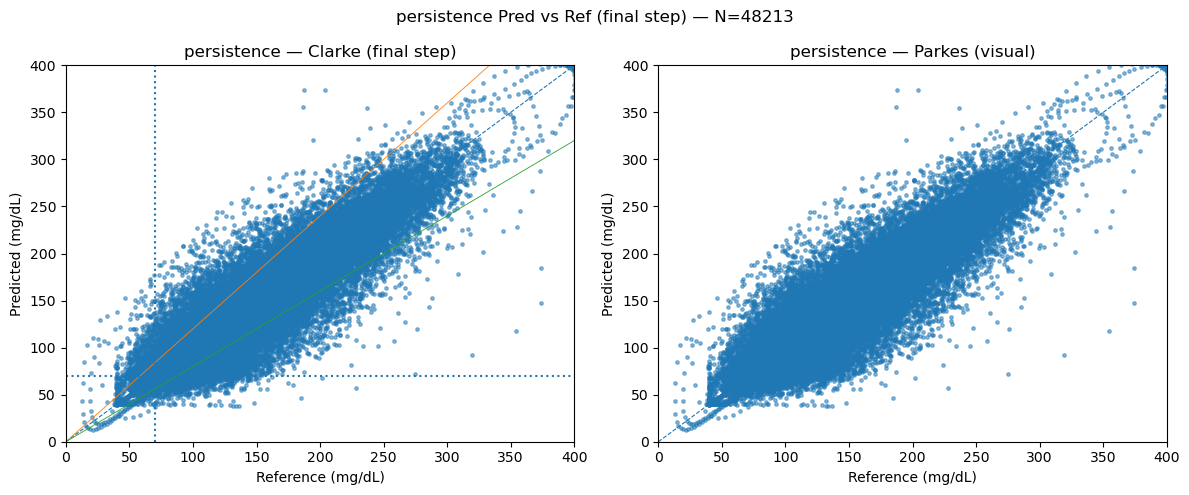


bergman Clarke zones:  {'A': (39029, 80.95), 'B': (9182, 19.04), 'D': (2, 0.0)}
bergman Parkes zones :  {'A': (38819, 80.52), 'B': (6235, 12.93), 'C': (2501, 5.19), 'E': (656, 1.36), 'D': (2, 0.0)}


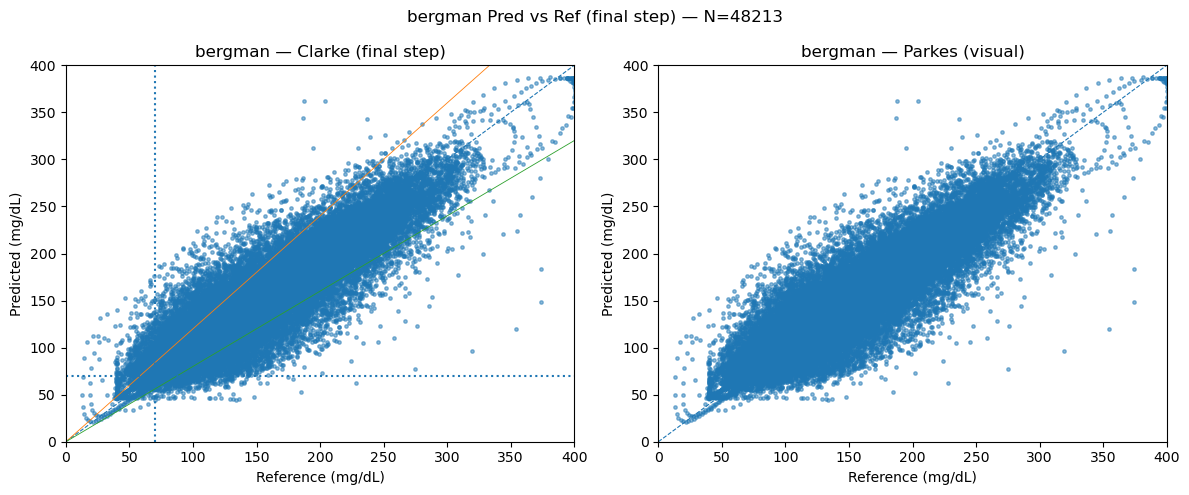


lstm Clarke zones:  {'A': (44182, 91.64), 'B': (4029, 8.36), 'D': (1, 0.0), 'C': (1, 0.0)}
lstm Parkes zones :  {'A': (44030, 91.32), 'C': (912, 1.89), 'E': (135, 0.28), 'D': (2, 0.0), 'B': (3134, 6.5)}


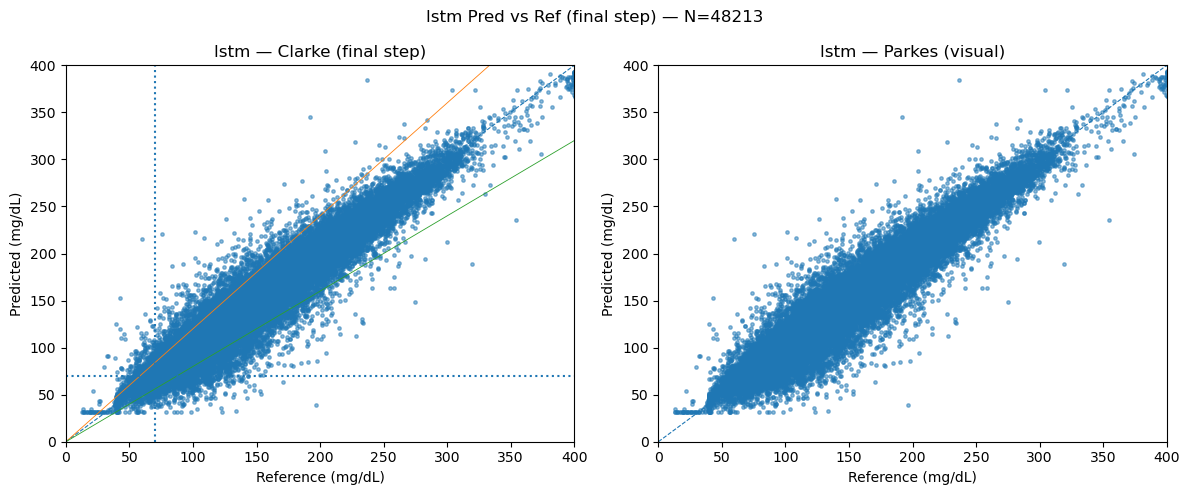


ml_corrector Clarke zones:  {'A': (39029, 80.95), 'B': (9182, 19.04), 'D': (2, 0.0)}
ml_corrector Parkes zones :  {'A': (38819, 80.52), 'B': (6235, 12.93), 'C': (2501, 5.19), 'E': (656, 1.36), 'D': (2, 0.0)}


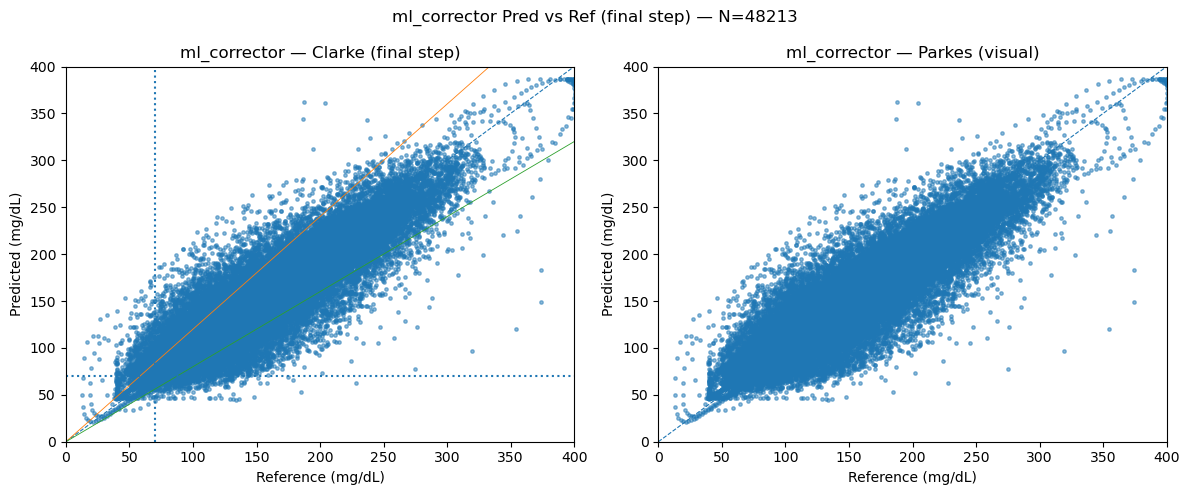


pinn Clarke zones:  {'A': (43222, 89.65), 'B': (4991, 10.35)}
pinn Parkes zones :  {'A': (42932, 89.05), 'B': (3709, 7.69), 'C': (1312, 2.72), 'E': (260, 0.54)}


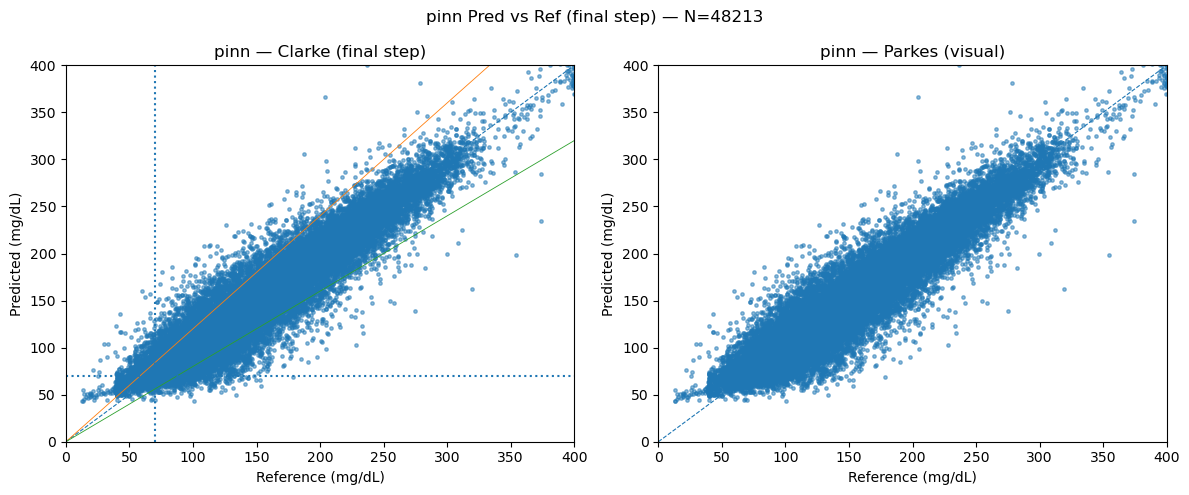


Glycemia detection — persistence (final step):


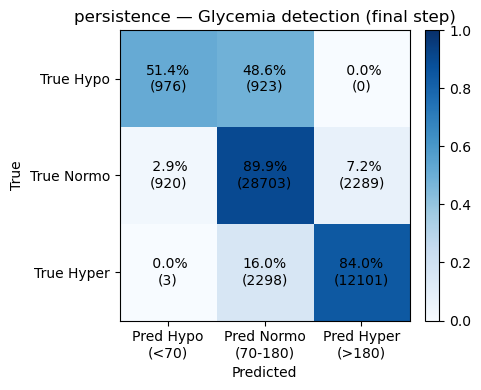


Glycemia detection — bergman (final step):


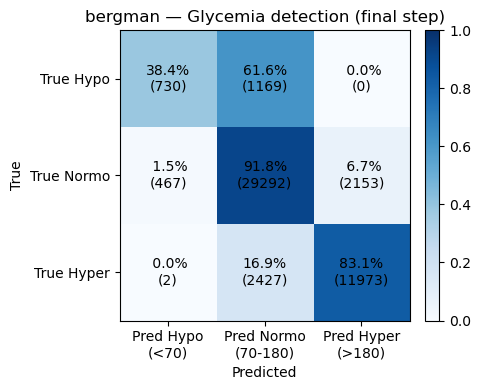


Glycemia detection — lstm (final step):


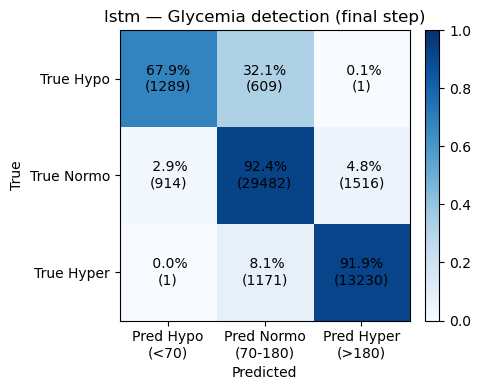


Glycemia detection — ml_corrector (final step):


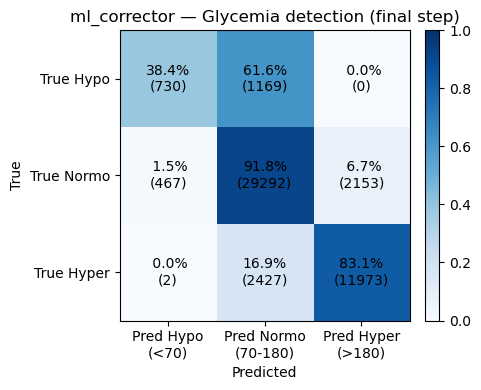


Glycemia detection — pinn (final step):


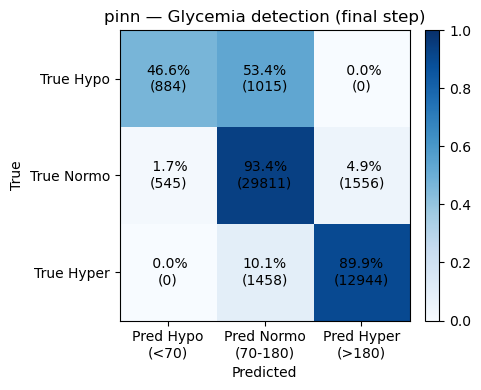

248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step


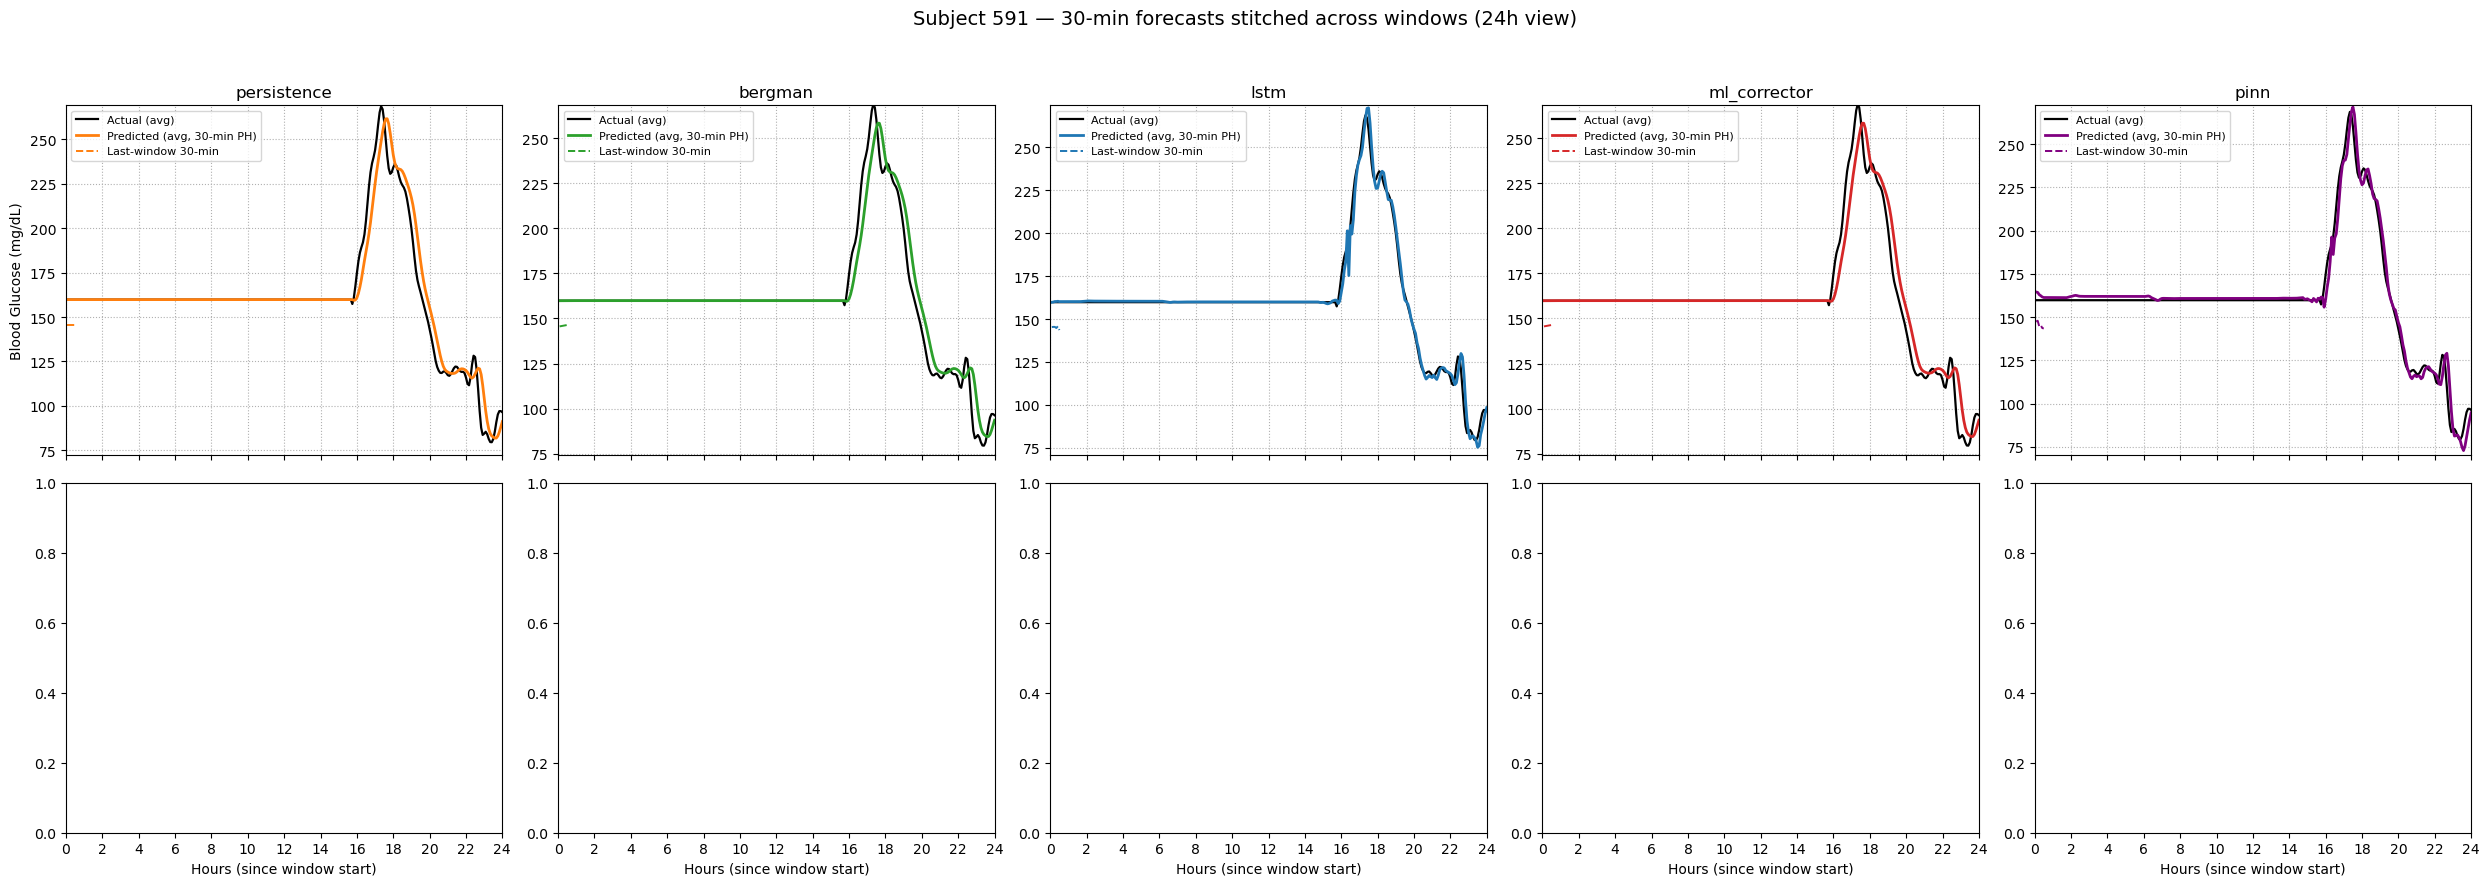

252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step


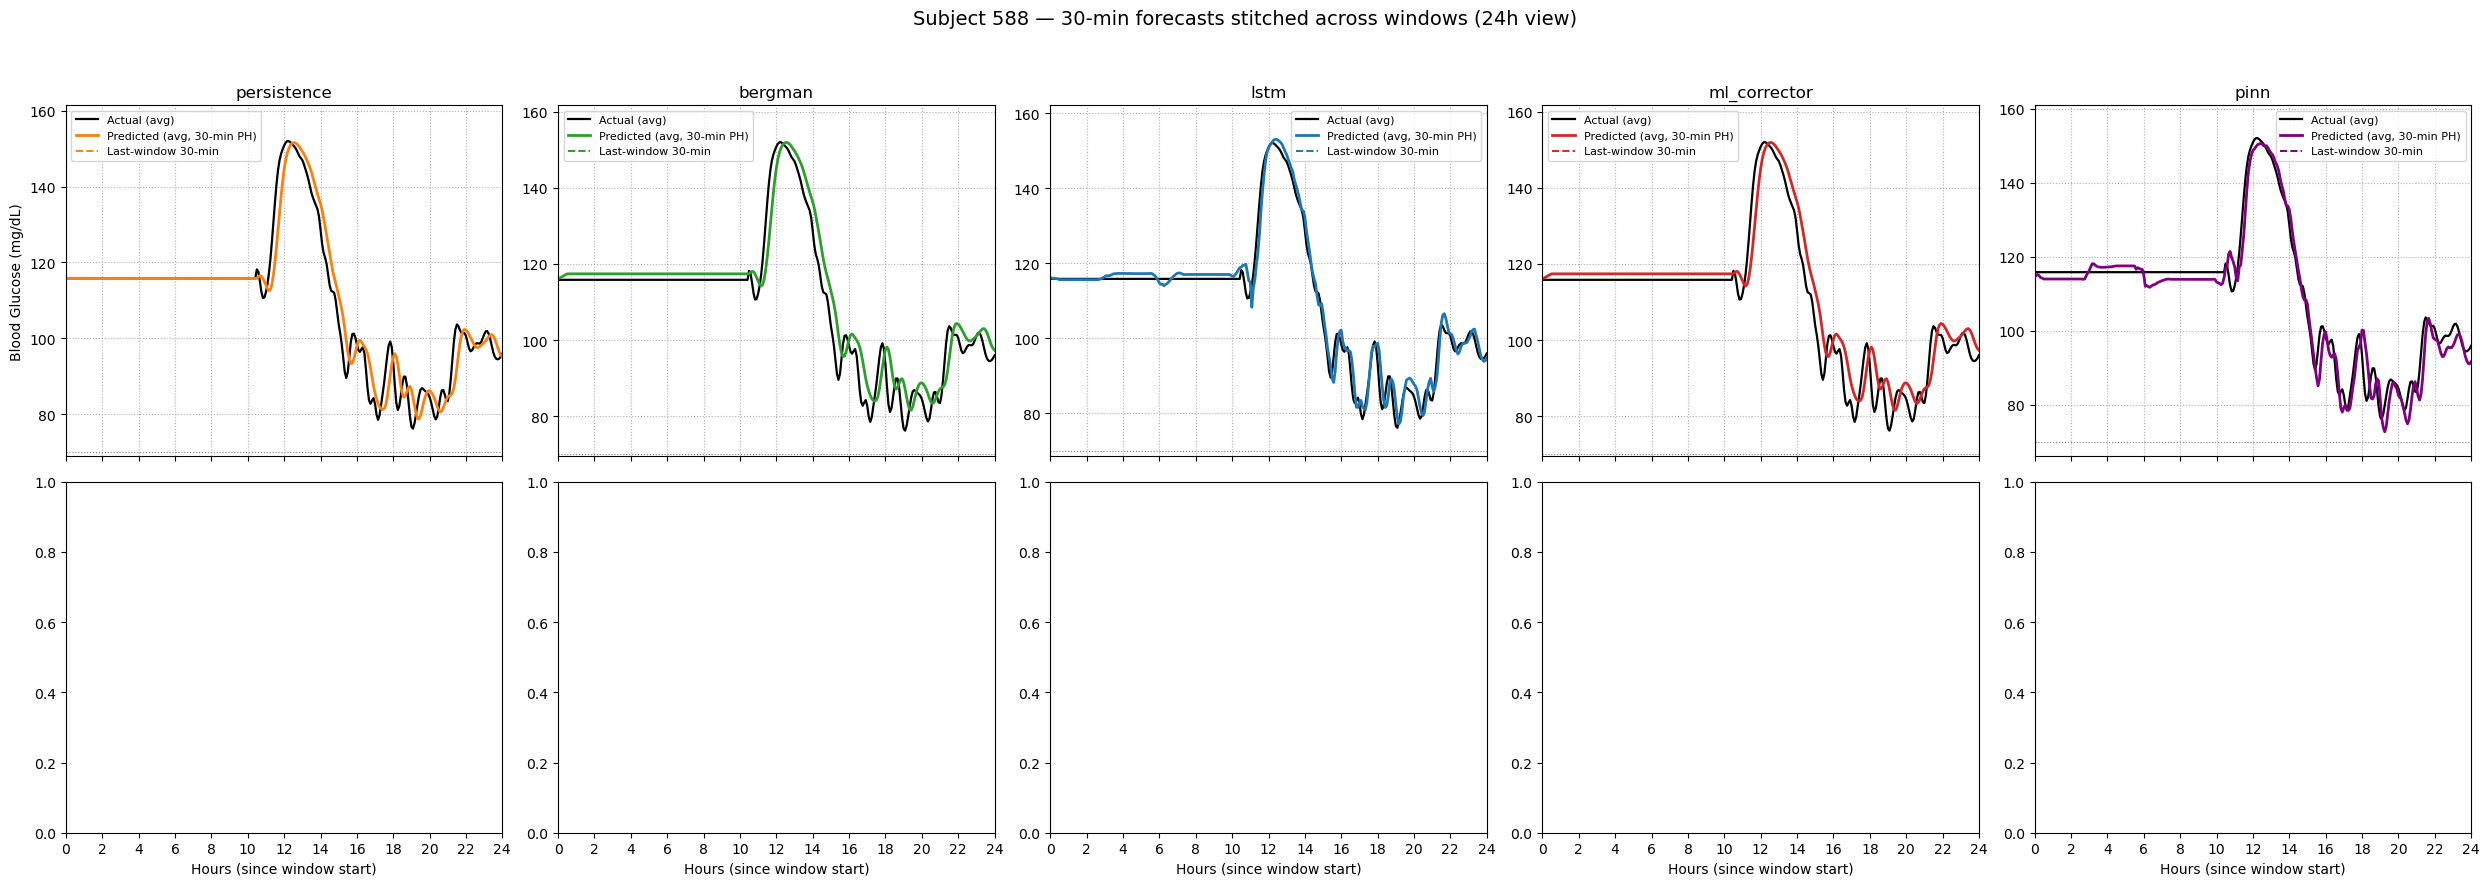

255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


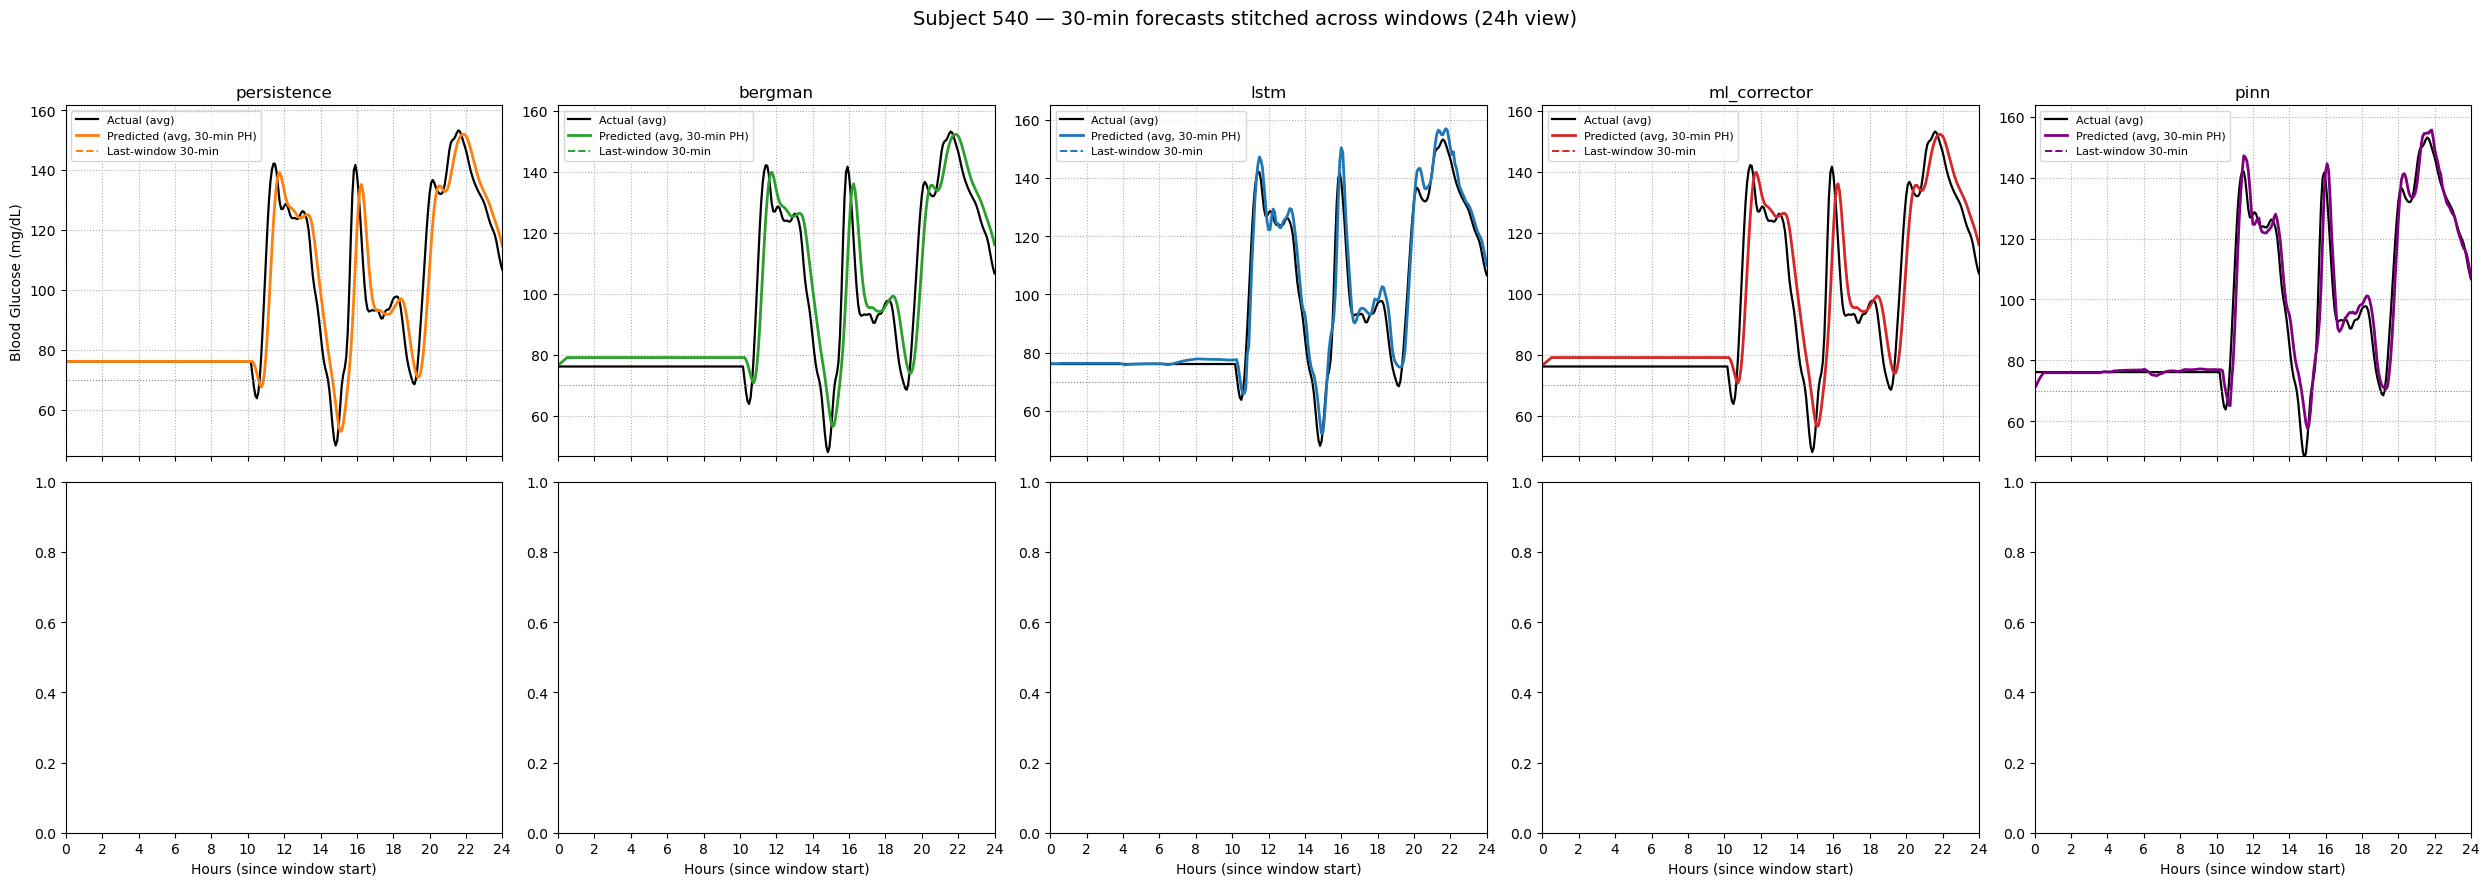

248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step
255/255 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step


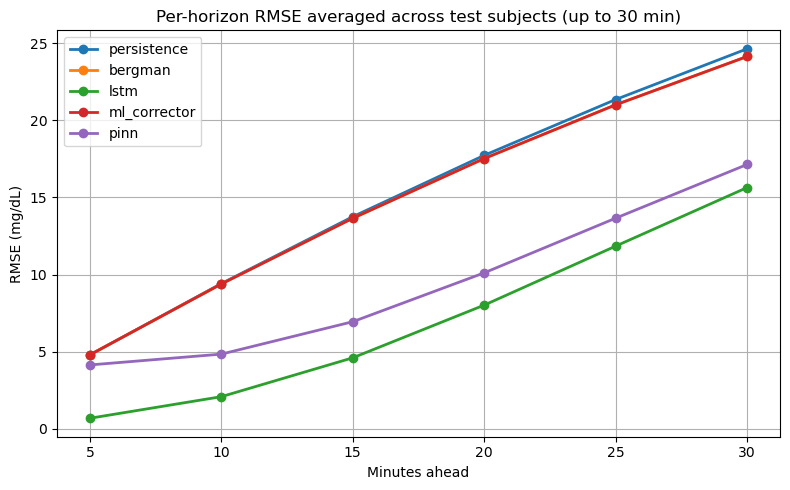


Done. Notes:
- Plots use a forced prediction horizon of 30 minutes (6 steps of 5 min).
- Continuous trajectories are formed by averaging predictions (and actuals) that map to each 5-min bin over a 24-hour span.
- Bottom panels show per-bin RMSE and sample counts so you can see where predictions are well/poorly supported.
- Temporal Gain (TG) and other metrics printed earlier are unchanged; TG is still computed on the model multi-step outputs (PH used there depends on original N_OUT unless you re-run upstream).


In [17]:
# Replacement Evaluation cell (full) with updated Temporal Gain metric per your description
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter
import math
from scipy.signal import correlate
import warnings


# --------------------------
# Helpers (scaler inversion, glycemia classes, metrics)
# --------------------------
def inv_cgm_with_cg_scaler(y_scaled):
    """y_scaled: array shape (..., N_OUT) or (..., N_OUT, 1) -> returns same shape in mg/dL"""
    if y_scaled is None or np.asarray(y_scaled).size == 0:
        return np.array([]).reshape(0, N_OUT)
    arr = np.asarray(y_scaled)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr.reshape(arr.shape[0], arr.shape[1])
    flat = arr.reshape(-1, 1)
    inv = cg_scaler.inverse_transform(flat).reshape(-1, N_OUT)
    return inv

HYPO = 70.0; HYPER = 180.0
def glycemia_class(x):
    x = np.asarray(x).reshape(-1)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < HYPO] = 0
    cls[(x >= HYPO) & (x <= HYPER)] = 1
    cls[x > HYPER] = 2
    return cls

# ---------- Updated Temporal Gain (TG) implementation ----------
def temporal_gain(y_true, y_pred, prediction_horizon):
    """
    Compute Temporal Gain (TG) following the description:
      - For each forecast window (length = horizon steps), compute cross-correlation between measured
        and predicted horizon-length vectors.
      - Restrict allowed delay tau to [0 .. max_lag_steps] where max_lag_steps = prediction_horizon / dt.
      - Find tau that maximizes abs(cross_corr). Convert tau to minutes: tau_minutes = tau * dt.
      - TG_window = prediction_horizon - tau_minutes.
      - Aggregate windows by median and return TG (minutes), clipped to [0, prediction_horizon].
    Inputs:
      y_true: array shape (n_windows, horizon) OR (n_windows*horizon,) that can be reshaped
      y_pred: same shape as y_true
      prediction_horizon: minutes (e.g., 30)
    Returns:
      median_TG_minutes (int)
    Notes:
      - If a window has very low variance (constant), it is considered uninformative and TG_window = 0.
      - This implementation follows the paper's definition TG = PH - delay * dt.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # infer horizon in steps and dt in minutes
    # prefer global N_OUT if available
    if 'N_OUT' in globals():
        horizon = int(N_OUT)
    else:
        # fallback: assume dt = 5 and compute horizon
        horizon = int(prediction_horizon // 5) or 1
    dt_minutes = float(prediction_horizon) / float(horizon)  # e.g., 30/6 = 5

    # reshape if flattened inputs were provided
    if y_true.ndim == 1 and y_pred.ndim == 1 and (y_true.size % horizon == 0) and (y_pred.size % horizon == 0):
        try:
            y_true = y_true.reshape(-1, horizon)
            y_pred = y_pred.reshape(-1, horizon)
        except Exception:
            return int(prediction_horizon)

    # check shapes
    if y_true.ndim != 2 or y_pred.ndim != 2 or y_true.shape[1] != y_pred.shape[1]:
        # cannot compute TG meaningfully
        return int(prediction_horizon)

    n_windows, L = y_true.shape
    max_lag_steps = int(prediction_horizon // dt_minutes)  # should equal horizon typically
    # ensure integer bounds
    max_lag_steps = min(max_lag_steps, L - 1)

    tg_windows = []
    for i in range(n_windows):
        t = y_true[i].astype(float)
        p = y_pred[i].astype(float)

        # Skip windows with NaNs entirely
        if np.all(np.isnan(t)) or np.all(np.isnan(p)):
            tg_windows.append(0)
            continue

        # If true or predicted horizon is (nearly) constant: uninformative for cross-correlation
        if np.nanstd(t) < 1e-8 or np.nanstd(p) < 1e-8:
            # treat as no timing information -> TG = 0 (as per your preference; persistence thus gets 0)
            tg_windows.append(0)
            continue

        # center signals
        t0 = t - np.nanmean(t)
        p0 = p - np.nanmean(p)

        # full cross-correlation and lags: -(L-1) .. (L-1)
        cc = correlate(t0, p0, mode='full')
        full_lags = np.arange(-L + 1, L)

        # allow only non-negative delays up to max_lag_steps
        valid_mask = (full_lags >= 0) & (full_lags <= max_lag_steps)
        valid_lags = full_lags[valid_mask]
        valid_cc   = cc[valid_mask]

        if valid_cc.size == 0:
            # no valid cross-correlation region -> worst-case
            tg_windows.append(0)
            continue

        # find delay (in steps) that maximizes abs(cross-corr)
        idx = np.argmax(np.abs(valid_cc))
        delay_steps = int(valid_lags[idx])
        delay_minutes = delay_steps * dt_minutes
        tg_val = prediction_horizon - delay_minutes
        # clip to [0, prediction_horizon]
        tg_val = max(0.0, min(float(prediction_horizon), float(tg_val)))
        tg_windows.append(tg_val)

    if len(tg_windows) == 0:
        return int(prediction_horizon)
    # aggregate by median for robustness
    tg_median = float(np.median(tg_windows))
    return int(round(tg_median))

#def temporal_gain(y_true, y_pred, prediction_horizon):
    """
    Temporal Gain implementation adapted to behave like Code 1:
      - Flatten inputs and compute a single full cross-correlation.
      - Use fixed dt = 5 minutes (as in Code 1).
      - Consider lags in steps from -prediction_horizon//5 .. 0 (inclusive).
      - Return TG in minutes computed as: TG = prediction_horizon + lag_steps*5
        (since lag_steps are non-positive here).
    Inputs:
      y_true: array-like (1D or 2D)
      y_pred: array-like (1D or 2D)
      prediction_horizon: minutes (e.g., 60)
    Returns:
      TG_minutes (int)
    Notes:
      - This purposely does NOT demean signals or compute per-window TGs to match Code 1.
      - Minimal sanity checks added to avoid runtime errors on empty inputs or empty valid lag range.
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    # basic guards
    if y_true.size == 0 or y_pred.size == 0:
        return int(prediction_horizon)

    # full cross-correlation (no demeaning, same as Code 1)
    cc = correlate(y_true, y_pred, mode='full')

    # lag bounds matching Code 1 (dt fixed to 5 minutes)
    lag_min = - (prediction_horizon // 5)
    lag_max = 0

    # full lag indices for correlate output: -(N_true-1) .. (N_pred-1)
    full_lags = np.arange(-len(y_true) + 1, len(y_pred))

    # mask valid lags and pick best (abs(cc))
    valid_mask = (full_lags >= lag_min) & (full_lags <= lag_max)
    if not np.any(valid_mask):
        # fallback if no valid lags (mirror Code 1's lack of handling by returning PH)
        return int(prediction_horizon)

    valid_lags = full_lags[valid_mask]
    valid_cc   = cc[valid_mask]

    # index of maximum absolute cross-correlation
    max_idx = int(np.argmax(np.abs(valid_cc)))
    best_lag_steps = int(valid_lags[max_idx])

    # convert to minutes using dt=5 and compute TG as in Code 1
    tg_minutes = prediction_horizon + best_lag_steps * 5

    # return integer minutes (round to nearest)
    return int(round(tg_minutes))

# --- other metrics unchanged ---
def g_mean(y_true, y_pred):
    from sklearn.metrics import recall_score
    t = glycemia_class(y_true); p = glycemia_class(y_pred)
    recalls = recall_score(t, p, average=None, zero_division=0)
    recalls = np.where(recalls == 0, 1e-10, recalls)
    return float(np.exp(np.mean(np.log(recalls))))

#def glucose_weighted_rmse(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return math.sqrt(np.sum(w * (y_true - y_pred)**2))

#def glucose_weighted_mae(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return np.sum(w * np.abs(y_true - y_pred))

# -------------------
# Fixed low-level smooth step (C2) functions and pen_function (broadcast-safe)
# -------------------
def _sigma_ge(x, a, eps):
    """
    _{x≥a, eps}(x) with broadcasting support for 'a' being scalar or array.
    """
    x = np.asarray(x, dtype=float)
    a = np.asarray(a, dtype=float)
    out = np.zeros_like(x, dtype=float)

    if np.asarray(eps).size == 1 and eps <= 0:
        # If eps <= 0, step function: 1 where x > a, else 0.
        # Use elementwise comparison with broadcasting.
        out = (x > a).astype(float)
        return out

    # left / right / mid masks (works if a is array or scalar thanks to numpy broadcasting)
    left = x <= a
    right = x >= (a + eps)
    mid = (~left) & (~right)

    out[right] = 1.0

    if np.any(mid):
        mid_vals = x[mid]
        # a may be scalar or array: get matching a values for the mid positions
        a_arr = np.asarray(a)
        if a_arr.shape == ():  # scalar
            a_mid = a_arr
        else:
            # a_arr must be broadcastable to x shape; extract the positions corresponding to mid
            # We can broadcast a to x shape and then index
            a_b = np.broadcast_to(a_arr, x.shape)
            a_mid = a_b[mid]

        xi = 2.0 * (mid_vals - a_mid) / eps - 1.0  # maps to (-1,1)
        # split xi into two halves
        first_half = xi <= 0
        second_half = ~first_half

        val = np.empty_like(xi)
        if np.any(first_half):
            xi_f = xi[first_half]
            val[first_half] = (-0.5 * xi_f**4) - (xi_f**3) + xi_f + 0.5
        if np.any(second_half):
            xi_s = xi[second_half]
            val[second_half] = (0.5 * xi_s**4) - (xi_s**3) + xi_s + 0.5

        out[mid] = val

    return out


def _sigma_le_bar(x, a, eps):
    """
    _{x≤a, eps}(x) (mirror of _sigma_ge) with broadcasting support for 'a'.
    """
    x = np.asarray(x, dtype=float)
    a = np.asarray(a, dtype=float)
    out = np.zeros_like(x, dtype=float)

    if np.asarray(eps).size == 1 and eps <= 0:
        out = (x <= a).astype(float)
        return out

    left = x <= (a - eps)
    right = x >= a
    mid = (~left) & (~right)

    out[left] = 1.0

    if np.any(mid):
        mid_vals = x[mid]
        a_arr = np.asarray(a)
        if a_arr.shape == ():  # scalar
            a_mid = a_arr
        else:
            a_b = np.broadcast_to(a_arr, x.shape)
            a_mid = a_b[mid]

        xi = 2.0 * (mid_vals - a_mid) / eps + 1.0  # maps [a-eps, a] -> [-1,1]
        first_half = xi <= 0
        second_half = ~first_half

        val = np.empty_like(xi)
        if np.any(first_half):
            xi_f = xi[first_half]
            val[first_half] = (0.5 * xi_f**4) - (xi_f**3) + xi_f + 0.5
        if np.any(second_half):
            xi_s = xi[second_half]
            val[second_half] = (-0.5 * xi_s**4) - (xi_s**3) + xi_s + 0.5

        out[mid] = val

    return out


def pen_function(g, ghat,
                 alphaL=1.5, alphaH=1.0,
                 TL=85.0, TH=155.0,
                 betaL=30.0, betaH=30.0,
                 gammaL=40.0, gammaH=40.0):
    """
    Vectorized Pen(g, ghat) with robust broadcasting handling.

    Ensures g and ghat end up with the same shape (supports scalars and arrays).
    """
    g = np.asarray(g, dtype=float)
    ghat = np.asarray(ghat, dtype=float)

    # If either is scalar, broadcast to the shape of the other
    if g.shape == () and ghat.shape != ():
        g = np.full_like(ghat, float(g))
    elif ghat.shape == () and g.shape != ():
        ghat = np.full_like(g, float(ghat))
    else:
        # Try to broadcast both to a common shape
        try:
            bshape = np.broadcast_shapes(g.shape, ghat.shape)
            g = np.broadcast_to(g, bshape).astype(float)
            ghat = np.broadcast_to(ghat, bshape).astype(float)
        except Exception:
            # As a final fallback flatten both and require equal length
            g = g.ravel()
            ghat = ghat.ravel()
            if g.size != ghat.size:
                raise ValueError("g and ghat must be broadcastable to the same shape")

    partL = _sigma_le_bar(g, TL, betaL) * _sigma_ge(ghat, g, gammaL)
    partH = _sigma_ge(g, TH, betaH) * _sigma_le_bar(ghat, g, gammaH)
    Pen = 1.0 + alphaL * partL + alphaH * partH
    return Pen


# -------------------
# gMSE / gRMSE and gMAE implementations
# -------------------
def glucose_weighted_rmse(y_true, y_pred,
           alphaL=1.5, alphaH=1.0, TL=85.0, TH=155.0,
           betaL=30.0, betaH=30.0, gammaL=40.0, gammaH=40.0):
    """
    Glucose-weighted RMSE (paper's g-RMSE): sqrt( mean( (g - ghat)^2 * Pen(g,ghat) ) )
    Returns np.nan if input arrays are empty.
    """
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")

    Pen = pen_function(y_true, y_pred,
                       alphaL=alphaL, alphaH=alphaH,
                       TL=TL, TH=TH,
                       betaL=betaL, betaH=betaH,
                       gammaL=gammaL, gammaH=gammaH)
    gse = (y_true - y_pred)**2 * Pen
    return math.sqrt(np.mean(gse))

def glucose_weighted_mae(y_true, y_pred,
          alphaL=1.5, alphaH=1.0, TL=85.0, TH=155.0,
          betaL=30.0, betaH=30.0, gammaL=40.0, gammaH=40.0):
    """
    Glucose-weighted MAE (paper's g-MAD / gMAE): mean( |g - ghat| * Pen(g, ghat) )
    """
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")

    Pen = pen_function(y_true, y_pred,
                       alphaL=alphaL, alphaH=alphaH,
                       TL=TL, TH=TH,
                       betaL=betaL, betaH=betaH,
                       gammaL=gammaL, gammaH=gammaH)
    gabs = np.abs(y_true - y_pred) * Pen
    return float(np.mean(gabs))


# Clarke/Parkes fallback (fast)
def clarke_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20): return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330): return 'E'
    if ref < 70 and pred >= 180: return 'C'
    if ref >= 180 and pred < 70: return 'D'
    return 'B'
def parkes_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    err = pred - ref; rel_err = abs(err) / max(ref,1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2): return 'A'
    if rel_err <= 0.35: return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70): return 'D'
    if rel_err > 0.6: return 'E'
    return 'C'


# If PCA-transformed test data is available, use it for evaluation
if 'per_subject_test_pca' in globals():
    per_subject_test = per_subject_test_pca

# --------------------------
# Prepare batched predictions for each model across all test subjects
# (unchanged from previously working code, updated to include 'pinn')
# --------------------------
models = {
    'persistence': persistence_model['predict'],
    'bergman': bergman_model['predict'],
    'lstm': lambda s: lstm_predict_on_subject(s),
    'ml_corrector': ml_corrector_model['predict'],
    'pinn': pinn_predict_on_subject
}

def ml_corrector_predict_fast(sid):
    #info = per_subject_test.get(sid, None)
    info = per_subject_test_pca.get(sid, None) # use PCA test data if available
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    Xs = info['X']
    resid_scaled = model_corr.predict(Xs, batch_size=128)
    subj = per_subject[sid]
    n_windows = Xs.shape[0]
    G_inits = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    bolus_mat = np.zeros((n_windows, N_OUT))
    carbs_mat  = np.zeros((n_windows, N_OUT))
    for w in range(n_windows):
        start = N_IN + w
        bolus_mat[w, :] = subj['bolus'].values[start:start+N_OUT]
        carbs_mat[w, :] = subj['carbs'].values[start:start+N_OUT]
    p1, p2, p3, k_i, Gb = bergman_model['params']
    dt_scale = (5.0 / 5.0)
    berg_preds = np.zeros((n_windows, N_OUT))
    G = G_inits.copy().astype(float)
    I = np.zeros(n_windows)
    for t in range(N_OUT):
        I = I * math.exp(-k_i) + bolus_mat[:, t]
        meal_effect = p3 * carbs_mat[:, t]
        dG = -p1 * (G - Gb) - p2 * I + meal_effect
        G = G + dG * dt_scale
        berg_preds[:, t] = G
    berg_preds_scaled = cg_scaler.transform(berg_preds.reshape(-1,1)).reshape(-1, N_OUT)
    corrected_scaled = berg_preds_scaled + resid_scaled
    return corrected_scaled.reshape(n_windows, N_OUT, 1)

models['ml_corrector'] = ml_corrector_predict_fast

# --------------------------
# Build arrays across ALL test windows for each model (batched per subject)
# --------------------------
all_results = {}
for mname, mpredict in models.items():
    Ys = []
    for sid, info in per_subject_test.items():
        X_test = info['X']
        if X_test.shape[0] == 0:
            continue
        yhat_scaled = mpredict(sid)
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)
        Ys.append(yhat_mg)
    all_results[mname] = np.vstack(Ys) if len(Ys) else np.zeros((0, N_OUT))

# Build ground-truth (all windows)
y_true_all_windows = []
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))
    y_true_all_windows.append(y_true_mg)
if len(y_true_all_windows) == 0:
    raise RuntimeError("No test windows found.")
y_true_all = np.vstack(y_true_all_windows)

# --------------------------
# Metrics (per-horizon and final-step)
# --------------------------
horiz_steps = np.arange(1, N_OUT+1) * 5
print("\n=== Per-horizon RMSE / MAE for each model ===")
per_horizon = {}
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        print(f"Model {mname}: no predictions")
        continue
    rmse_h = []
    mae_h = []
    for h in range(N_OUT):
        y_t = y_true_all[:, h]
        y_p = ypred_all[:, h]
        rmse_h.append(np.sqrt(mean_squared_error(y_t, y_p)))
        mae_h.append(mean_absolute_error(y_t, y_p))
    per_horizon[mname] = {'rmse': rmse_h, 'mae': mae_h}
    print(f"\nModel: {mname}")
    print("Horizon (min):", list(horiz_steps))
    print("RMSE (mg/dL): ", [round(v,2) for v in rmse_h])
    print("MAE  (mg/dL): ", [round(v,2) for v in mae_h])

print("\n=== Final-step aggregated metrics (30 min) ===")
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    rmse_val = np.sqrt(mean_squared_error(ref, pred))
    mae_val  = mean_absolute_error(ref, pred)
    gw_rmse = glucose_weighted_rmse(ref, pred)
    gw_mae  = glucose_weighted_mae(ref, pred)
    # compute TG using multi-step arrays and the paper definition TG = PH - delay*dt (median across windows)
    tg = temporal_gain(y_true_all, ypred_all, prediction_horizon=5*N_OUT)
    gm = g_mean(ref, pred)
    print(f"\nModel: {mname}")
    print(f"  windows: {len(ref)}")
    print(f"  RMSE: {rmse_val:.3f}  MAE: {mae_val:.3f}")
    print(f"  Glucose-weighted RMSE: {gw_rmse:.3f}  Glucose-weighted MAE: {gw_mae:.3f}")
    print(f"  Temporal gain (min): {tg}   G-Mean: {gm:.4f}")

# --------------------------
# Clarke & Parkes (fallback) + scatter plots per model (final step)
# --------------------------
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    cz = [clarke_zone_for_point(r,p) for r,p in zip(ref, pred)]
    pz = [parkes_zone_for_point(r,p) for r,p in zip(ref, pred)]
    c_counts = dict(Counter(cz)); p_counts = dict(Counter(pz)); total = len(ref)
    print(f"\n{mname} Clarke zones: ", {k:(c_counts[k], round(100*c_counts[k]/total,2)) for k in c_counts})
    print(f"{mname} Parkes zones : ", {k:(p_counts[k], round(100*p_counts[k]/total,2)) for k in p_counts})

    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax0 = ax[0]
    ax0.scatter(ref, pred, s=6, alpha=0.5)
    ax0.plot([0,400],[0,400],'--', linewidth=0.8)
    xs = np.linspace(0,400,100); ax0.plot(xs, 1.2*xs, linewidth=0.6); ax0.plot(xs, 0.8*xs, linewidth=0.6)
    ax0.axvline(70, linestyle=':'); ax0.axhline(70, linestyle=':')
    ax0.set_xlim(0,400); ax0.set_ylim(0,400)
    ax0.set_xlabel('Reference (mg/dL)'); ax0.set_ylabel('Predicted (mg/dL)')
    ax0.set_title(f"{mname} — Clarke (final step)")

    ax1 = ax[1]
    ax1.scatter(ref, pred, s=6, alpha=0.5)
    ax1.plot([0,400],[0,400],'--', linewidth=0.8)
    ax1.set_xlim(0,400); ax1.set_ylim(0,400)
    ax1.set_xlabel('Reference (mg/dL)'); ax1.set_ylabel('Predicted (mg/dL)')
    ax1.set_title(f"{mname} — Parkes (visual)")
    plt.suptitle(f"{mname} Pred vs Ref (final step) — N={total}")
    plt.tight_layout()
    plt.show()

# --------------------------
# Glycemia detection confusion matrices for each model (final step)
# --------------------------
def compute_glycemia_confusion(y_true, y_pred):
    y_t = np.asarray(y_true).reshape(-1); y_p = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_t) & np.isfinite(y_p)
    y_t = y_t[mask]; y_p = y_p[mask]
    counts = np.zeros((3,3), dtype=int)
    if y_t.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    tcls = glycemia_class(y_t); pcls = glycemia_class(y_p)
    for t,p in zip(tcls, pcls):
        if 0<=t<=2 and 0<=p<=2:
            counts[t,p] += 1
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        s = counts[i].sum()
        if s>0:
            pct[i,:] = counts[i,:] / float(s)
    return counts, pct

def plot_confusion_heatmaps(counts, pct, title=""):
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap='Blues', interpolation='nearest')
    ax.set_xticks(np.arange(3)); ax.set_yticks(np.arange(3))
    labels = ['Pred Hypo\n(<70)','Pred Normo\n(70-180)','Pred Hyper\n(>180)']
    ax.set_xticklabels(labels); ax.set_yticklabels(['True Hypo','True Normo','True Hyper'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            c = counts[i,j]; p = pct[i,j]
            if np.isnan(p):
                txt = "n/a\n(0)"
            else:
                txt = f"{p*100:4.1f}%\n({c})"
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0: continue
    counts, pct = compute_glycemia_confusion(y_true_all[:, -1], ypred_all[:, -1])
    print(f"\nGlycemia detection — {mname} (final step):")
    plot_confusion_heatmaps(counts, pct, title=f"{mname} — Glycemia detection (final step)")

# --------------------------
# --------------------------
# UPDATED PLOTTING SECTION (continuous multi-step trajectories over 24 hours)
# Now: force prediction horizon = 30 minutes (dt=5 -> 6 steps), but show model performance
# across 24 hours by stitching averaged predictions into 5-min bins.
# Also add per-bin RMSE and sample counts to give more insight.
# Only plotting code changed from prior version: 24h view + simpler plotting aesthetics.
# --------------------------
model_order = ['persistence','bergman','lstm','ml_corrector','pinn']
dt = 5  # minutes between successive windows/steps
prediction_horizon_min = 30
ph_steps = int(prediction_horizon_min // dt)   # 6 for 30 min with dt=5
total_minutes = 24 * 60  # 24 hours view (changed from 12h)
time_bins = np.arange(dt, total_minutes + dt, dt)  # 5,10,...,1440
nbins = len(time_bins)

# sanity checks for required objects
if 'per_subject_test' not in globals():
    raise RuntimeError("per_subject_test not found in the environment.")
if 'models' not in globals():
    raise RuntimeError("models dict not found in the environment.")
if 'inv_cgm_with_cg_scaler' not in globals():
    raise RuntimeError("inv_cgm_with_cg_scaler function not found in the environment.")
# HYPO may be defined in your env; fallback to None
HYPO = globals().get('HYPO', None)

selected_sids = list(per_subject_test.keys())[:3]  # first 3 test subjects (adjust as needed)
n_models = len(model_order)

# color mapping (keeps consistent across runs)
color_map = {
    'persistence': 'tab:orange',
    'bergman': 'tab:green',
    'lstm': 'tab:blue',
    'ml_corrector': 'tab:red',
    'pinn': 'purple'
}

if len(selected_sids) == 0:
    print("No test subjects available for plotting.")
else:
    for sid in selected_sids:
        info = per_subject_test[sid]
        X_test = info.get('X')        # shape (n_windows, N_IN, feats) - not used here except for n_windows sanity
        y_test = info.get('y')        # shape (n_windows, N_OUT, 1) or (n_windows, N_OUT)

        if X_test is None or y_test is None:
            warnings.warn(f"Subject {sid} missing X or y — skipping.")
            continue
        if getattr(X_test, 'shape', (0,))[0] == 0:
            warnings.warn(f"Subject {sid} has zero test windows — skipping.")
            continue

        # convert y_test to (n_windows, N_OUT) and restrict to ph_steps
        y_test_arr = np.asarray(y_test)
        if y_test_arr.ndim == 3 and y_test_arr.shape[-1] == 1:
            y_test_flat = y_test_arr.reshape(y_test_arr.shape[0], y_test_arr.shape[1])
        else:
            y_test_flat = y_test_arr.copy()

        if y_test_flat.shape[1] < ph_steps:
            raise RuntimeError(f"y_test for subject {sid} has fewer than {ph_steps} horizon steps ({y_test_flat.shape[1]}).")

        # convert to mg/dL if your scaler function does this
        y_test_mg = inv_cgm_with_cg_scaler(y_test_flat[:, :ph_steps])  # shape (n_windows, ph_steps)

        # create figure: 2 rows x n_models columns
        fig, axs = plt.subplots(2, n_models, figsize=(5*n_models, 9), sharex=True)
        if n_models == 1:
            axs = axs.reshape(2,1)
        fig.suptitle(f"Subject {sid} — 30-min forecasts stitched across windows (24h view)", fontsize=14)

        for i_m, mname in enumerate(model_order):
            ax_top = axs[0, i_m]
            ax_bot = axs[1, i_m]

            # get model predictions for this subject (batched) and restrict to ph_steps
            if mname not in models:
                ax_top.text(0.5, 0.5, f"model '{mname}' not found", ha='center', va='center')
                ax_top.set_title(mname)
                ax_bot.set_visible(False)
                continue

            yhat_scaled_all = models[mname](sid)   # expected shape (n_windows, N_OUT) or (n_windows, N_OUT, 1)
            yhat_scaled_all = np.asarray(yhat_scaled_all)
            if yhat_scaled_all.size == 0:
                ax_top.text(0.5, 0.5, "no preds", ha='center', va='center')
                ax_top.set_title(mname)
                ax_bot.set_visible(False)
                continue

            if yhat_scaled_all.ndim == 3 and yhat_scaled_all.shape[-1] == 1:
                yhat_scaled_all = yhat_scaled_all.reshape(yhat_scaled_all.shape[0], yhat_scaled_all.shape[1])

            if yhat_scaled_all.shape[1] < ph_steps:
                raise RuntimeError(f"Model {mname} returned fewer than {ph_steps} horizon steps ({yhat_scaled_all.shape[1]}).")

            yhat_mg_all = inv_cgm_with_cg_scaler(yhat_scaled_all[:, :ph_steps])  # (n_windows, ph_steps)
            n_windows = yhat_mg_all.shape[0]

            # compute predicted times (minutes) for each window's ph_steps:
            # window w predictions occupy times: (w*dt + dt), (w*dt + 2*dt), ..., (w*dt + ph_steps*dt)
            win_idx = np.arange(n_windows).reshape(-1,1)
            step_idx = np.arange(1, ph_steps+1).reshape(1,-1)
            pred_times = (win_idx * dt) + (step_idx * dt)  # shape (n_windows, ph_steps) in minutes

            pred_times_flat = pred_times.ravel().astype(int)
            preds_flat = yhat_mg_all.ravel()
            actuals_flat = y_test_mg.ravel()
            # mask predictions that fall outside 24h window
            valid_mask = (pred_times_flat >= dt) & (pred_times_flat <= total_minutes)

            # Map each flat time to a bin index (dt maps to bin 0)
            bin_idx = (pred_times_flat // dt) - 1
            agg_pred = np.full(nbins, np.nan)
            agg_actual = np.full(nbins, np.nan)
            agg_rmse = np.full(nbins, np.nan)
            agg_counts = np.zeros(nbins, dtype=int)

            for b in range(nbins):
                idxs = np.where((bin_idx == b) & valid_mask)[0]
                c = idxs.size
                agg_counts[b] = c
                if c > 0:
                    vals_pred = preds_flat[idxs].astype(float)
                    vals_act  = actuals_flat[idxs].astype(float)
                    agg_pred[b] = np.nanmean(vals_pred)
                    agg_actual[b] = np.nanmean(vals_act)
                    agg_rmse[b] = np.sqrt(np.nanmean((vals_pred - vals_act)**2))

            # helper: linear-interpolate internal NaN gaps between first and last valid bin
            def interp_nan(arr):
                arr = arr.astype(float)
                mask = ~np.isnan(arr)
                if mask.sum() == 0:
                    return arr
                first, last = np.where(mask)[0][0], np.where(mask)[0][-1]
                x = np.arange(first, last+1)
                y = arr[first:last+1]
                valid = ~np.isnan(y)
                if valid.sum() <= 1:
                    # nothing useful to interpolate
                    return arr
                xi = np.arange(first, last+1)
                arr[first:last+1] = np.interp(xi, x[valid], y[valid])
                return arr

            agg_pred_f = interp_nan(agg_pred)
            agg_actual_f = interp_nan(agg_actual)
            agg_rmse_f = interp_nan(agg_rmse)

            t_minutes = time_bins
            t_hours = t_minutes / 60.0

            color = color_map.get(mname, 'gray')

            # TOP: averaged continuous trajectories (Actual vs Predicted average)
            if np.all(np.isnan(agg_actual_f)) and np.all(np.isnan(agg_pred_f)):
                ax_top.text(0.5, 0.5, "no data in 24h window", ha='center', va='center')
            else:
                ax_top.plot(t_hours, agg_actual_f, '-', color='black', linewidth=1.6, label='Actual (avg)')
                ax_top.plot(t_hours, agg_pred_f, '-', color=color, linewidth=2.0, label='Predicted (avg, 30-min PH)')
                # overlay the short-term forecast for the last window (anchored near time 0 — visual cue)
                last_pred = yhat_mg_all[-1, :ph_steps]
                last_times = (np.arange(1, ph_steps+1) * dt) / 60.0
                # place dashed short forecast near beginning to show short-term shape (kept simple)
                ax_top.plot(last_times, last_pred, '--', color=color, linewidth=1.4, label='Last-window 30-min')
                ax_top.set_title(mname)

            # aesthetics
            if i_m == 0:
                ax_top.set_ylabel('Blood Glucose (mg/dL)')
            ax_top.set_xlim(0, total_minutes/60.0)
            # make x ticks every 2 hours for readability
            xticks = np.arange(0, (total_minutes/60.0) + 0.1, 2)
            ax_top.set_xticks(xticks)
            if HYPO is not None:
                ax_top.axhline(HYPO, color='gray', linestyle=':', linewidth=0.8)
            # set reasonable y-limits based on data (but keep a safe range)
            all_vals = np.concatenate([agg_actual_f[~np.isnan(agg_actual_f)] if agg_actual_f is not None else np.array([]),
                                       agg_pred_f[~np.isnan(agg_pred_f)] if agg_pred_f is not None else np.array([])])
            if all_vals.size > 0:
                lo, hi = np.nanpercentile(all_vals, [1, 99])
                pad = max(10, 0.05 * (hi - lo))
                ax_top.set_ylim(max(30, lo - pad), min(400, hi + pad))
            else:
                ax_top.set_ylim(40, 300)
            ax_top.grid(True, linestyle=':')
            ax_top.legend(fontsize=8)

            # BOTTOM: per-bin RMSE (line) and counts (bar on secondary axis) - simplified
#            if np.all(np.isnan(agg_rmse_f)):
#                ax_bot.text(0.5, 0.5, "no RMSE data", ha='center', va='center')
#            else:
#                ax_bot.plot(t_hours, agg_rmse_f, '-', linewidth=1.6, label='RMSE (per 5-min bin)')
            ax_bot.set_xlabel('Hours (since window start)')
#            ax_bot.set_xlim(0, total_minutes/60.0)
#            ax_bot.set_ylabel('RMSE (mg/dL)')
#            ax_bot.grid(True, linestyle=':')
#            # secondary axis for counts
#            axc = ax_bot.twinx()
#            axc.bar(t_hours, agg_counts, width=(dt/60.0)*0.9, alpha=0.25)
#            axc.set_ylabel('N samples')
#            # x ticks every 2 hours
#           ax_bot.set_xticks(xticks)
#            # combine legends simply
#            lines, labs = ax_bot.get_legend_handles_labels()
#            if lines:
#                ax_bot.legend(lines, labs, fontsize=8, loc='upper right')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# Combined summary plot: per-horizon RMSE averaged across subjects but only up to the 30-min horizon
model_names = list(all_results.keys())
per_subject_rmse = {m: [] for m in model_names}
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg_full = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))
    # ensure y_true_mg_full has enough steps
    if y_true_mg_full.shape[1] < ph_steps:
        raise RuntimeError(f"Subject {sid} y_true has fewer than {ph_steps} horizon steps.")
    y_true_mg = y_true_mg_full[:, :ph_steps]
    for m in model_names:
        yhat_scaled = models[m](sid)
        if np.asarray(yhat_scaled).size == 0:
            continue
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        if yhat_scaled.shape[1] < ph_steps:
            continue
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)[:, :ph_steps]
        rmse_per_h = [np.sqrt(mean_squared_error(y_true_mg[:,h], yhat_mg[:,h])) for h in range(ph_steps)]
        per_subject_rmse[m].append(rmse_per_h)

plt.figure(figsize=(8,5))
for m in model_names:
    subj_rmses = np.array(per_subject_rmse[m]) if len(per_subject_rmse[m])>0 else np.zeros((0, ph_steps))
    if subj_rmses.size == 0:
        continue
    mean_rmse = np.nanmean(subj_rmses, axis=0)
    plt.plot(np.arange(1, ph_steps+1)*5, mean_rmse, '-o', label=m, linewidth=2)
plt.xticks(np.arange(1, ph_steps+1)*5)
plt.xlabel('Minutes ahead'); plt.ylabel('RMSE (mg/dL)')
plt.title('Per-horizon RMSE averaged across test subjects (up to 30 min)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("\nDone. Notes:")
print(f"- Plots use a forced prediction horizon of {prediction_horizon_min} minutes ({ph_steps} steps of {dt} min).")
print("- Continuous trajectories are formed by averaging predictions (and actuals) that map to each 5-min bin over a 24-hour span.")
print("- Bottom panels show per-bin RMSE and sample counts so you can see where predictions are well/poorly supported.")
print("- Temporal Gain (TG) and other metrics printed earlier are unchanged; TG is still computed on the model multi-step outputs (PH used there depends on original N_OUT unless you re-run upstream).")


248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

=== Per-horizon RMSE / MAE for each model ===

Model: persistence
Horizon (min): [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30)]
RMSE (mg/dL):  [np.float64(4.79), np.float64(9.42), np.float64(13.75), np.float64(17.73), np.float64(21.35), np.float64(24.64)]
MAE  (mg/dL):  [3.32, 6.53, 9.56, 12.37, 14.95, 17.34]

Model: bergman
Horizon (min): [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30)]
RMSE (mg/dL):  [np.float64(4.8), np.float64(9.39), np.float64(13.65), np.float64(17.52), np.float64(21.01), np.float64(24.15)]
MAE  (mg/dL):  [3.37, 6.61, 9.63, 12.41, 14.94, 17.24]

Model: lstm
Horizon (min): [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(3

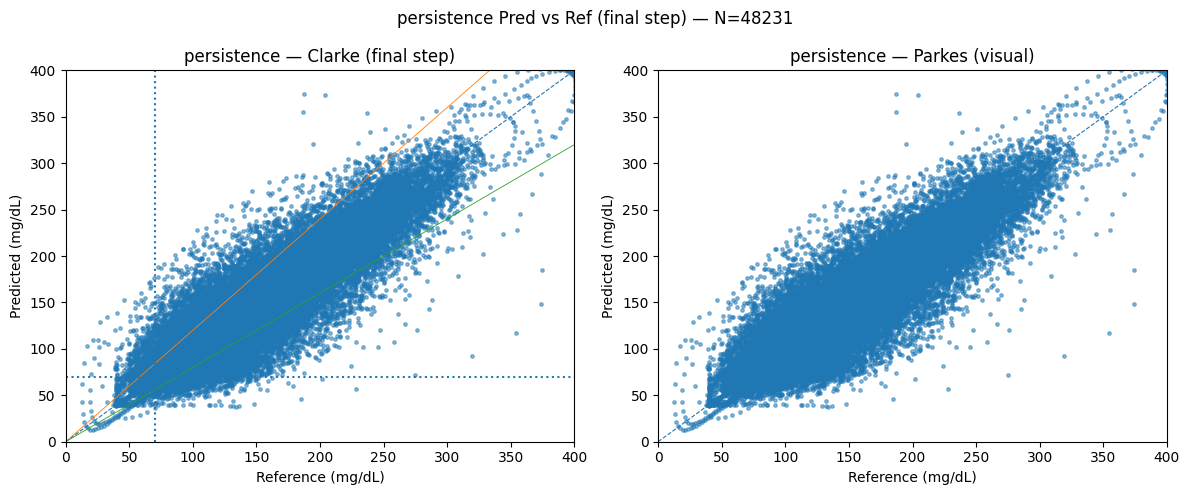


bergman Clarke zones:  {'A': (39048, 80.96), 'B': (9181, 19.04), 'D': (2, 0.0)}
bergman Parkes zones :  {'A': (38838, 80.52), 'B': (6234, 12.93), 'C': (2501, 5.19), 'E': (656, 1.36), 'D': (2, 0.0)}


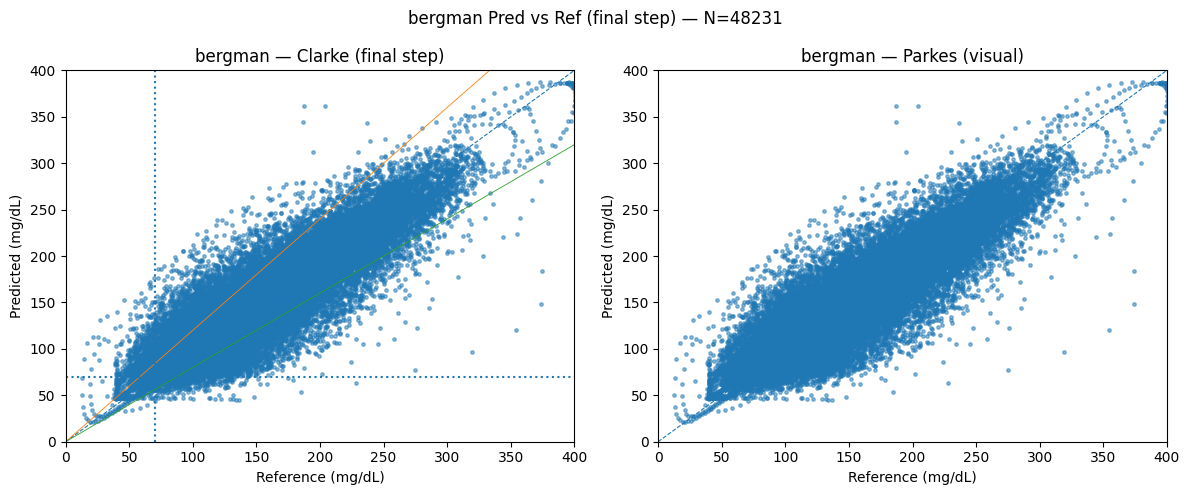


lstm Clarke zones:  {'A': (44441, 92.14), 'B': (3789, 7.86), 'D': (1, 0.0)}
lstm Parkes zones :  {'A': (44304, 91.86), 'C': (912, 1.89), 'E': (135, 0.28), 'D': (1, 0.0), 'B': (2879, 5.97)}


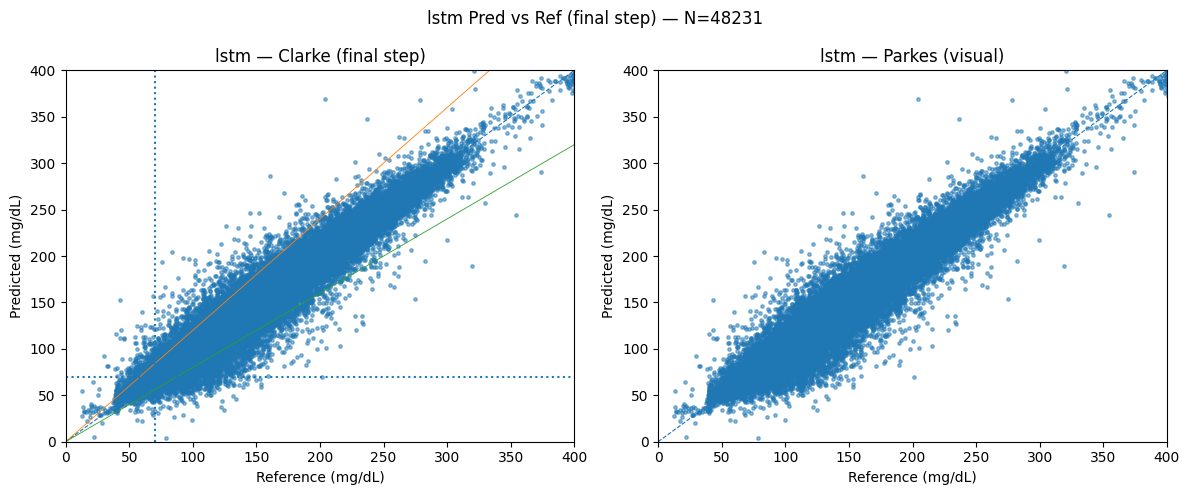


ml_corrector Clarke zones:  {'A': (43870, 90.96), 'B': (4360, 9.04), 'D': (1, 0.0)}
ml_corrector Parkes zones :  {'A': (43737, 90.68), 'B': (3530, 7.32), 'C': (856, 1.77), 'E': (107, 0.22), 'D': (1, 0.0)}


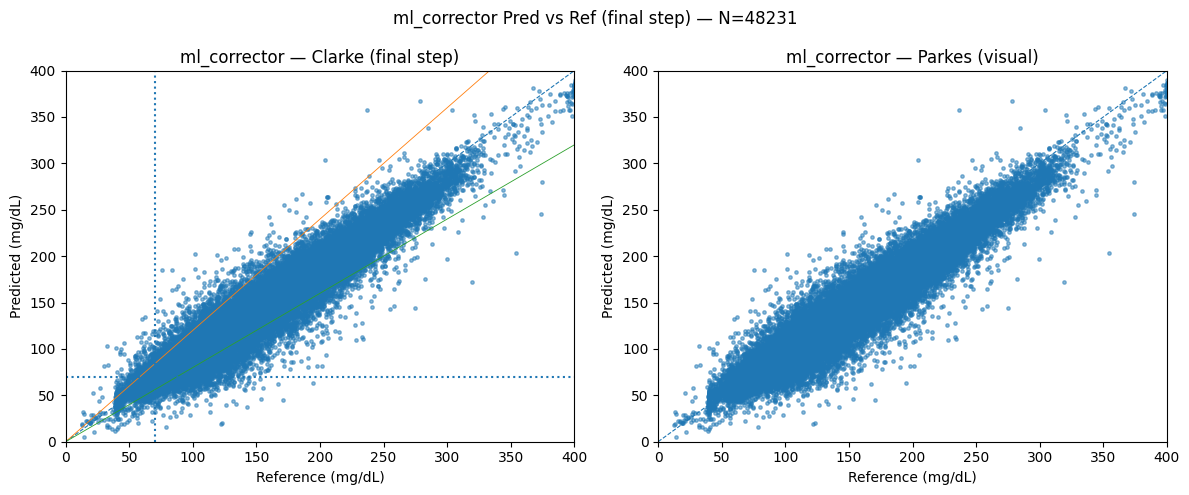


pinn Clarke zones:  {'A': (42476, 88.07), 'B': (5754, 11.93), 'C': (1, 0.0)}
pinn Parkes zones :  {'A': (42262, 87.62), 'B': (4243, 8.8), 'C': (1429, 2.96), 'E': (296, 0.61), 'D': (1, 0.0)}


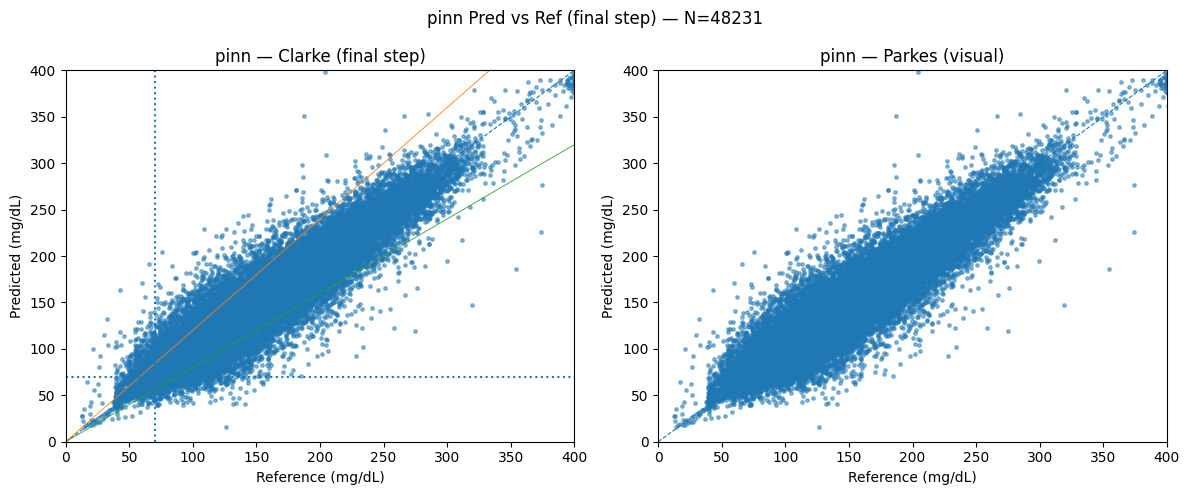


Glycemia detection — persistence (final step):


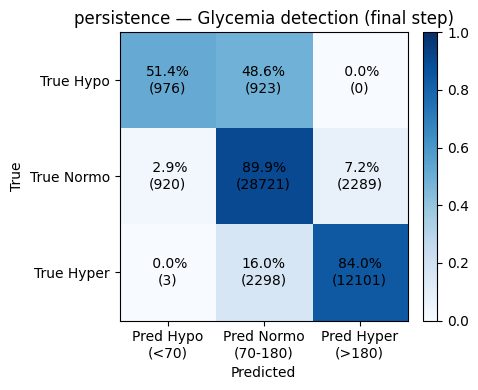


Glycemia detection — bergman (final step):


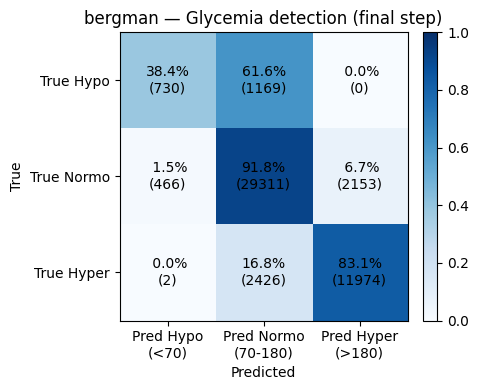


Glycemia detection — lstm (final step):


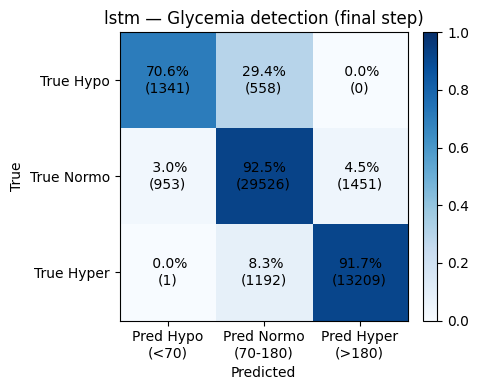


Glycemia detection — ml_corrector (final step):


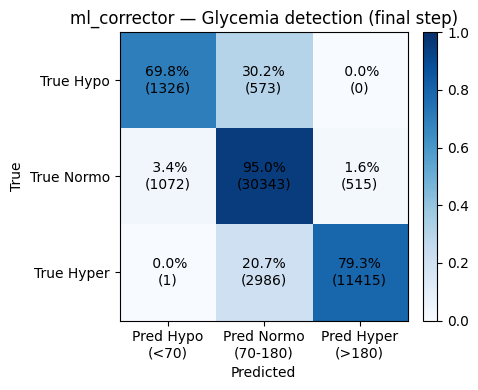


Glycemia detection — pinn (final step):


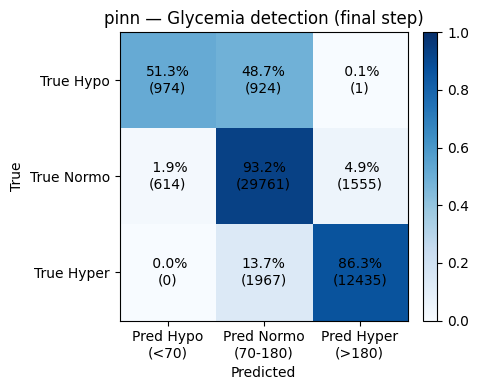

248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


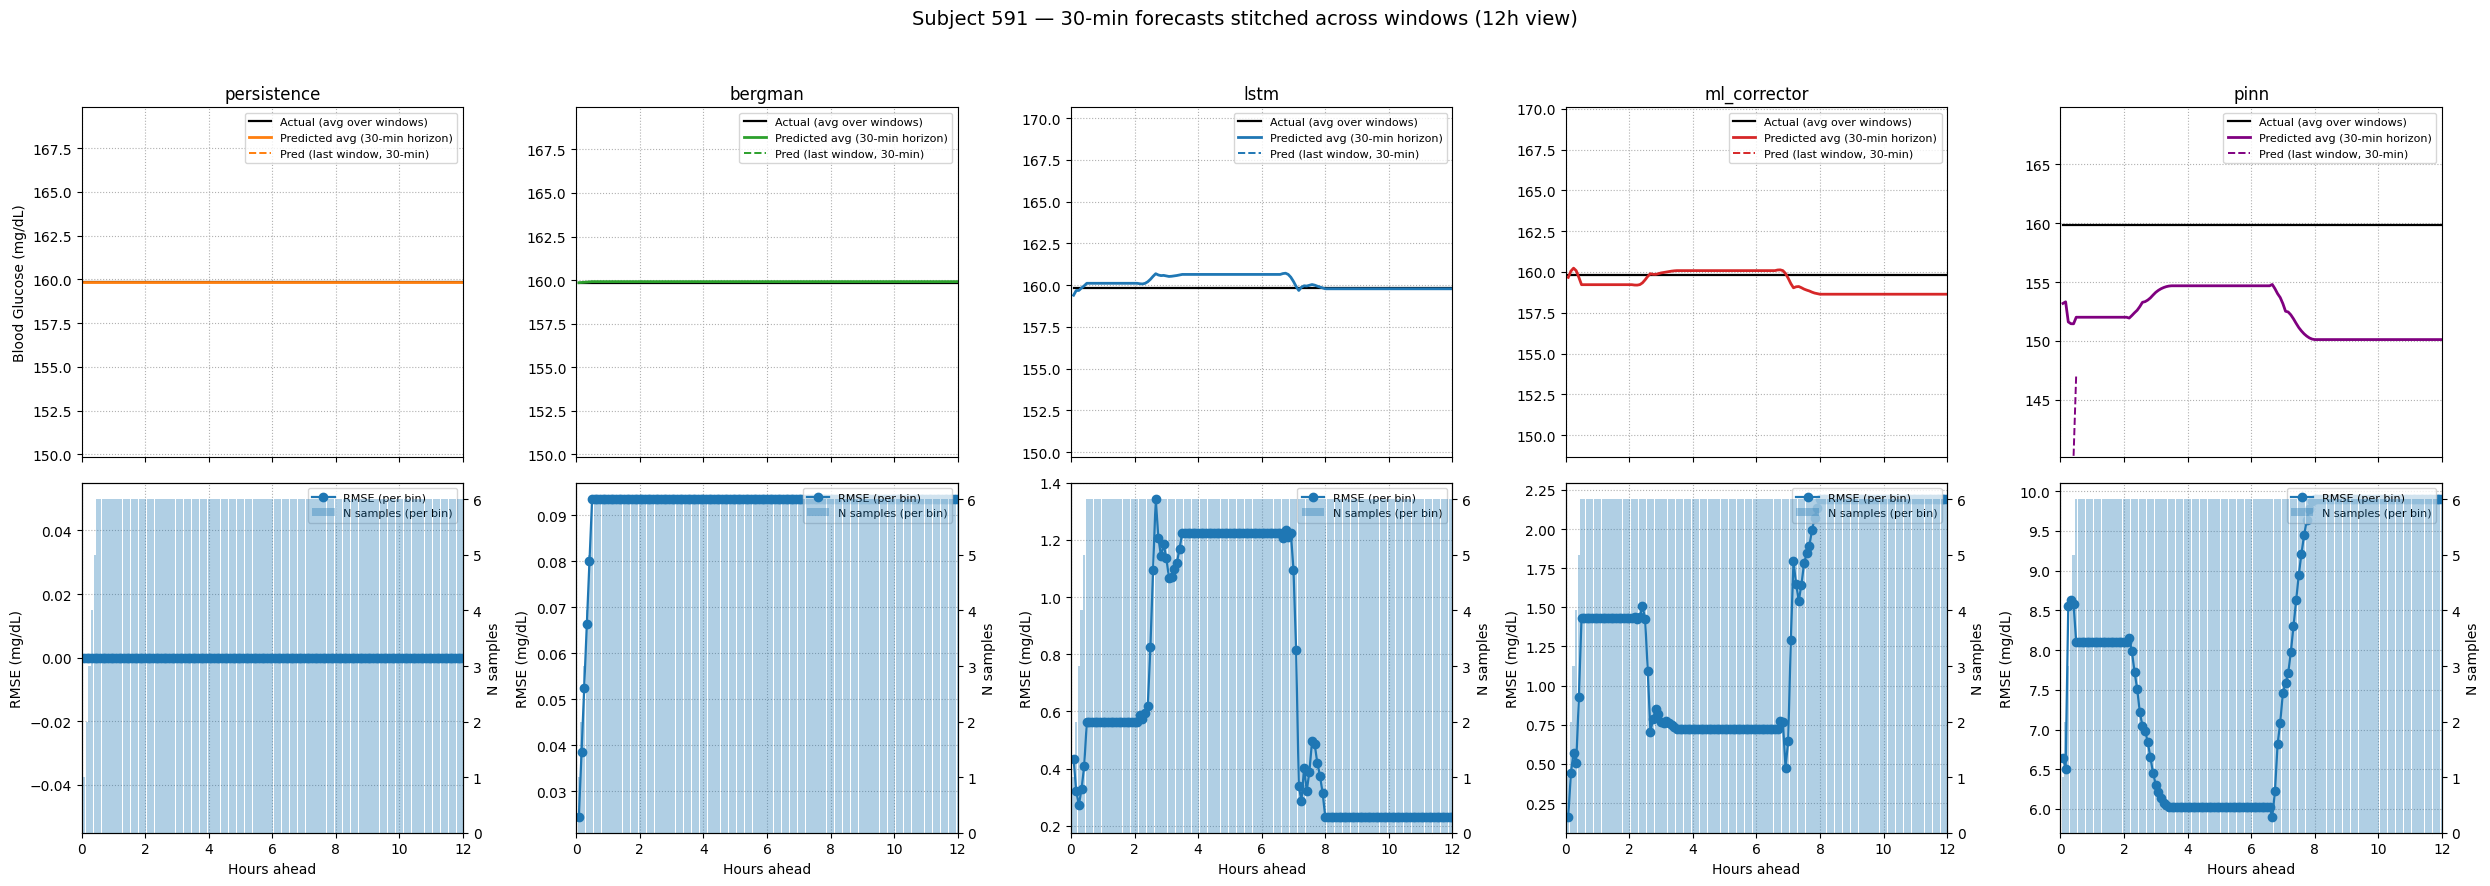

252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


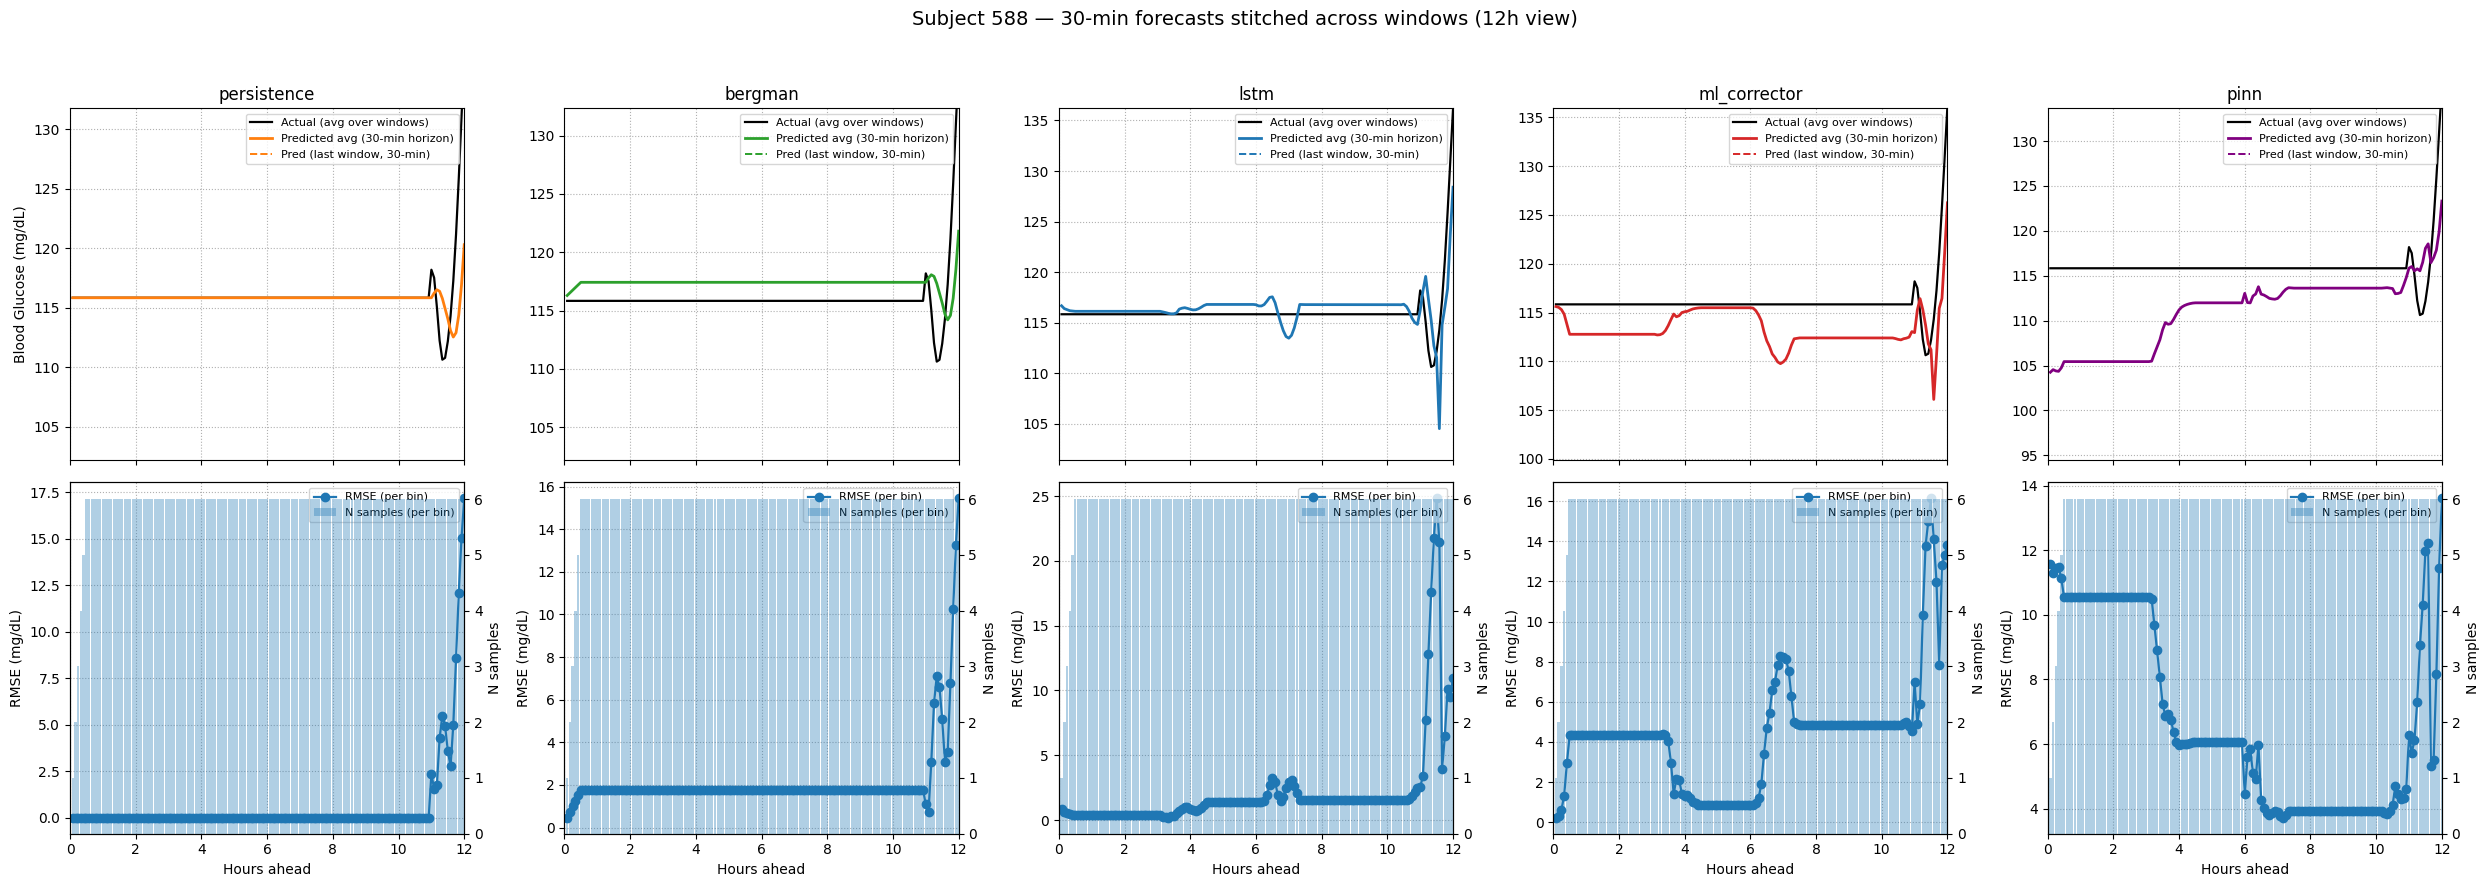

255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


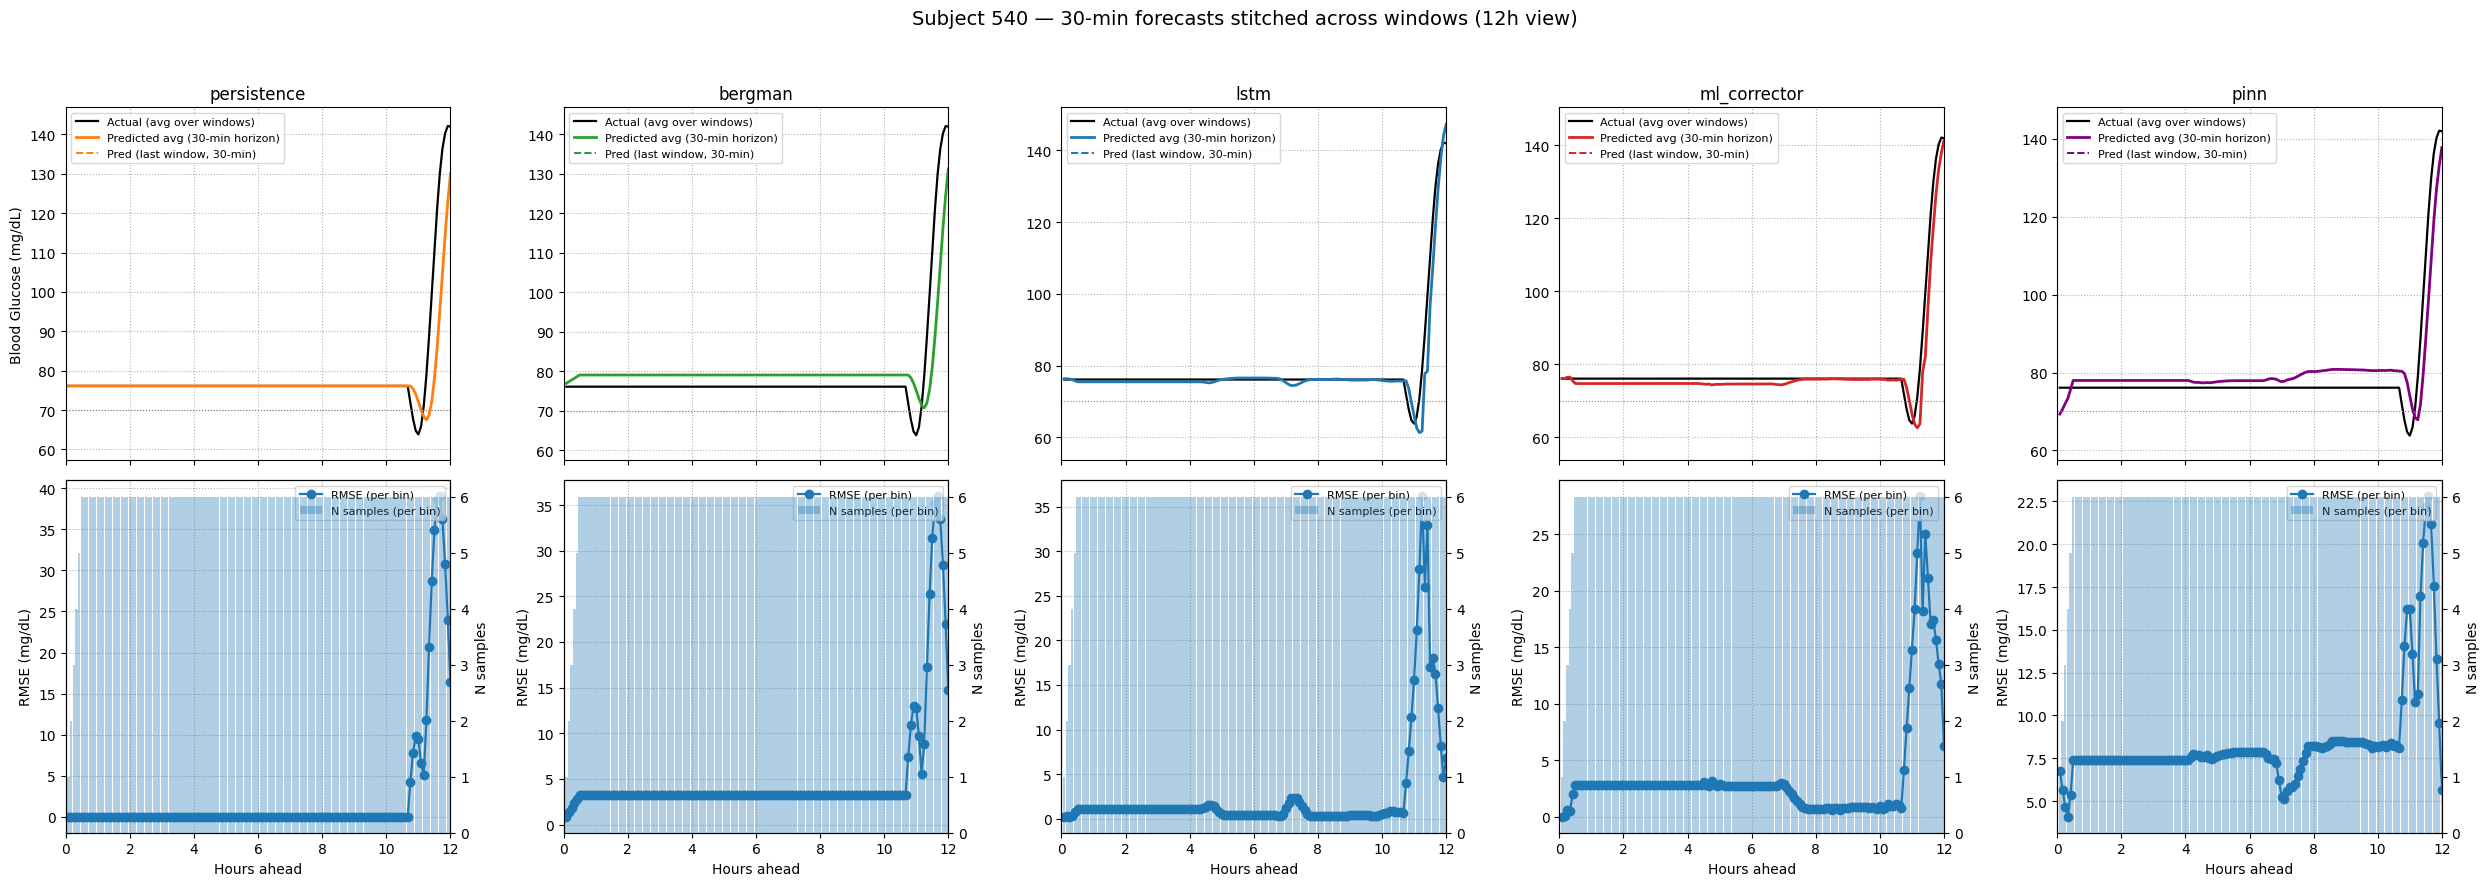

248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


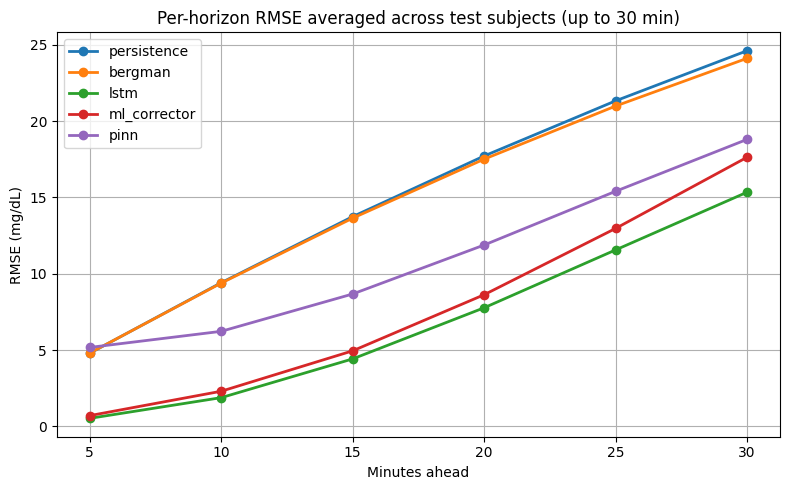


Done. Notes:
- Plots use a forced prediction horizon of 30 minutes (6 steps of 5 min).
- Continuous trajectories are formed by averaging predictions (and actuals) that map to each 5-min bin over a 12-hour span.
- Bottom panels show per-bin RMSE and sample counts so you can see where predictions are well/poorly supported.
- Temporal Gain (TG) and other metrics printed earlier are unchanged; TG is still computed on the model multi-step outputs (PH used there depends on original N_OUT unless you re-run upstream).


In [ ]:
# Replacement Evaluation cell (full) with updated Temporal Gain metric per your description
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from collections import Counter
import math
from scipy.signal import correlate
import warnings


# --------------------------
# Helpers (scaler inversion, glycemia classes, metrics)
# --------------------------
def inv_cgm_with_cg_scaler(y_scaled):
    """y_scaled: array shape (..., N_OUT) or (..., N_OUT, 1) -> returns same shape in mg/dL"""
    if y_scaled is None or np.asarray(y_scaled).size == 0:
        return np.array([]).reshape(0, N_OUT)
    arr = np.asarray(y_scaled)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr.reshape(arr.shape[0], arr.shape[1])
    flat = arr.reshape(-1, 1)
    inv = cg_scaler.inverse_transform(flat).reshape(-1, N_OUT)
    return inv

HYPO = 70.0; HYPER = 180.0
def glycemia_class(x):
    x = np.asarray(x).reshape(-1)
    cls = np.full(x.shape, -1, dtype=int)
    cls[x < HYPO] = 0
    cls[(x >= HYPO) & (x <= HYPER)] = 1
    cls[x > HYPER] = 2
    return cls

# ---------- Updated Temporal Gain (TG) implementation ----------
def temporal_gain(y_true, y_pred, prediction_horizon):
    """
    Compute Temporal Gain (TG) following the description:
      - For each forecast window (length = horizon steps), compute cross-correlation between measured
        and predicted horizon-length vectors.
      - Restrict allowed delay tau to [0 .. max_lag_steps] where max_lag_steps = prediction_horizon / dt.
      - Find tau that maximizes abs(cross_corr). Convert tau to minutes: tau_minutes = tau * dt.
      - TG_window = prediction_horizon - tau_minutes.
      - Aggregate windows by median and return TG (minutes), clipped to [0, prediction_horizon].
    Inputs:
      y_true: array shape (n_windows, horizon) OR (n_windows*horizon,) that can be reshaped
      y_pred: same shape as y_true
      prediction_horizon: minutes (e.g., 30)
    Returns:
      median_TG_minutes (int)
    Notes:
      - If a window has very low variance (constant), it is considered uninformative and TG_window = 0.
      - This implementation follows the paper's definition TG = PH - delay * dt.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # infer horizon in steps and dt in minutes
    # prefer global N_OUT if available
    if 'N_OUT' in globals():
        horizon = int(N_OUT)
    else:
        # fallback: assume dt = 5 and compute horizon
        horizon = int(prediction_horizon // 5) or 1
    dt_minutes = float(prediction_horizon) / float(horizon)  # e.g., 30/6 = 5

    # reshape if flattened inputs were provided
    if y_true.ndim == 1 and y_pred.ndim == 1 and (y_true.size % horizon == 0) and (y_pred.size % horizon == 0):
        try:
            y_true = y_true.reshape(-1, horizon)
            y_pred = y_pred.reshape(-1, horizon)
        except Exception:
            return int(prediction_horizon)

    # check shapes
    if y_true.ndim != 2 or y_pred.ndim != 2 or y_true.shape[1] != y_pred.shape[1]:
        # cannot compute TG meaningfully
        return int(prediction_horizon)

    n_windows, L = y_true.shape
    max_lag_steps = int(prediction_horizon // dt_minutes)  # should equal horizon typically
    # ensure integer bounds
    max_lag_steps = min(max_lag_steps, L - 1)

    tg_windows = []
    for i in range(n_windows):
        t = y_true[i].astype(float)
        p = y_pred[i].astype(float)

        # Skip windows with NaNs entirely
        if np.all(np.isnan(t)) or np.all(np.isnan(p)):
            tg_windows.append(0)
            continue

        # If true or predicted horizon is (nearly) constant: uninformative for cross-correlation
        if np.nanstd(t) < 1e-8 or np.nanstd(p) < 1e-8:
            # treat as no timing information -> TG = 0 (as per your preference; persistence thus gets 0)
            tg_windows.append(0)
            continue

        # center signals
        t0 = t - np.nanmean(t)
        p0 = p - np.nanmean(p)

        # full cross-correlation and lags: -(L-1) .. (L-1)
        cc = correlate(t0, p0, mode='full')
        full_lags = np.arange(-L + 1, L)

        # allow only non-negative delays up to max_lag_steps
        valid_mask = (full_lags >= 0) & (full_lags <= max_lag_steps)
        valid_lags = full_lags[valid_mask]
        valid_cc   = cc[valid_mask]

        if valid_cc.size == 0:
            # no valid cross-correlation region -> worst-case
            tg_windows.append(0)
            continue

        # find delay (in steps) that maximizes abs(cross-corr)
        idx = np.argmax(np.abs(valid_cc))
        delay_steps = int(valid_lags[idx])
        delay_minutes = delay_steps * dt_minutes
        tg_val = prediction_horizon - delay_minutes
        # clip to [0, prediction_horizon]
        tg_val = max(0.0, min(float(prediction_horizon), float(tg_val)))
        tg_windows.append(tg_val)

    if len(tg_windows) == 0:
        return int(prediction_horizon)
    # aggregate by median for robustness
    tg_median = float(np.median(tg_windows))
    return int(round(tg_median))

#def temporal_gain(y_true, y_pred, prediction_horizon):
    """
    Temporal Gain implementation adapted to behave like Code 1:
      - Flatten inputs and compute a single full cross-correlation.
      - Use fixed dt = 5 minutes (as in Code 1).
      - Consider lags in steps from -prediction_horizon//5 .. 0 (inclusive).
      - Return TG in minutes computed as: TG = prediction_horizon + lag_steps*5
        (since lag_steps are non-positive here).
    Inputs:
      y_true: array-like (1D or 2D)
      y_pred: array-like (1D or 2D)
      prediction_horizon: minutes (e.g., 60)
    Returns:
      TG_minutes (int)
    Notes:
      - This purposely does NOT demean signals or compute per-window TGs to match Code 1.
      - Minimal sanity checks added to avoid runtime errors on empty inputs or empty valid lag range.
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    # basic guards
    if y_true.size == 0 or y_pred.size == 0:
        return int(prediction_horizon)

    # full cross-correlation (no demeaning, same as Code 1)
    cc = correlate(y_true, y_pred, mode='full')

    # lag bounds matching Code 1 (dt fixed to 5 minutes)
    lag_min = - (prediction_horizon // 5)
    lag_max = 0

    # full lag indices for correlate output: -(N_true-1) .. (N_pred-1)
    full_lags = np.arange(-len(y_true) + 1, len(y_pred))

    # mask valid lags and pick best (abs(cc))
    valid_mask = (full_lags >= lag_min) & (full_lags <= lag_max)
    if not np.any(valid_mask):
        # fallback if no valid lags (mirror Code 1's lack of handling by returning PH)
        return int(prediction_horizon)

    valid_lags = full_lags[valid_mask]
    valid_cc   = cc[valid_mask]

    # index of maximum absolute cross-correlation
    max_idx = int(np.argmax(np.abs(valid_cc)))
    best_lag_steps = int(valid_lags[max_idx])

    # convert to minutes using dt=5 and compute TG as in Code 1
    tg_minutes = prediction_horizon + best_lag_steps * 5

    # return integer minutes (round to nearest)
    return int(round(tg_minutes))

# --- other metrics unchanged ---
def g_mean(y_true, y_pred):
    from sklearn.metrics import recall_score
    t = glycemia_class(y_true); p = glycemia_class(y_pred)
    recalls = recall_score(t, p, average=None, zero_division=0)
    recalls = np.where(recalls == 0, 1e-10, recalls)
    return float(np.exp(np.mean(np.log(recalls))))

#def glucose_weighted_rmse(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return math.sqrt(np.sum(w * (y_true - y_pred)**2))

#def glucose_weighted_mae(y_true, y_pred):
    y_true = np.asarray(y_true).flatten(); y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    w = np.maximum(y_true, 0.0)
    if w.sum() == 0:
        w = np.ones_like(w)
    w = w / w.sum()
    return np.sum(w * np.abs(y_true - y_pred))

# -------------------
# low-level smooth step (C2) functions from Appendix A (vectorized)
# -------------------
def _sigma_ge(x, a, eps):
    """
    σ_{x≥a, eps}(x) from Appendix A:
      0                        if x <= a
      piecewise polynomial     if a < x < a + eps
      1                        if x >= a + eps
    The polynomial pieces are implemented using xi = 2*(x - a)/eps - 1
    so that xi maps interval [a, a+eps] -> [-1, 1].
    """
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    if eps <= 0:
        out[x > a] = 1.0
        return out

    a0 = a
    left = x <= a0
    right = x >= (a0 + eps)
    mid = (~left) & (~right)

    # handle left/right
    out[right] = 1.0
    # mid needs splitting into two halves
    mid_vals = x[mid]
    xi = 2.0 * (mid_vals - a0) / eps - 1.0  # in (-1, 1)
    # where xi in [-1, 0] (first half) use: -1/2*xi^4 - xi^3 + xi + 1/2
    # where xi in [0,  1] (second half) use:  1/2*xi^4 - xi^3 + xi + 1/2
    first_half = xi <= 0
    second_half = ~first_half

    val = np.empty_like(xi)
    if first_half.any():
        xi_f = xi[first_half]
        val[first_half] = (-0.5 * xi_f**4) - (xi_f**3) + xi_f + 0.5
    if second_half.any():
        xi_s = xi[second_half]
        val[second_half] = (0.5 * xi_s**4) - (xi_s**3) + xi_s + 0.5

    out[mid] = val
    return out

def _sigma_le_bar(x, a, eps):
    """
    σ̄_{x≤a, eps}(x) from Appendix A (mirror of _sigma_ge).
      1                        if x <= a - eps
      polynomial               if a-eps < x < a
      0                        if x >= a
    We map [a - eps, a] to [-1, 1] using xi_bar = 2*(x - a)/eps + 1
    """
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    if eps <= 0:
        out[x <= a] = 1.0
        return out

    a0 = a
    left = x <= (a0 - eps)
    right = x >= a0
    mid = (~left) & (~right)

    out[left] = 1.0
    mid_vals = x[mid]
    xi = 2.0 * (mid_vals - a0) / eps + 1.0  # maps [a-eps, a] -> [-1, 1]
    first_half = xi <= 0
    second_half = ~first_half

    val = np.empty_like(xi)
    # note the same polynomial signs but assigned to correct subintervals
    if first_half.any():
        xi_f = xi[first_half]
        # for xi in [-1, 0] here (a-eps .. a-eps/2)
        val[first_half] = (0.5 * xi_f**4) - (xi_f**3) + xi_f + 0.5
    if second_half.any():
        xi_s = xi[second_half]
        # for xi in [0, 1] here (a-eps/2 .. a)
        val[second_half] = (-0.5 * xi_s**4) - (xi_s**3) + xi_s + 0.5

    out[mid] = val
    return out

# -------------------
# Penalty function Pen(g, ghat)
# Pen(g,ĝ) = 1 + αL * σ̄_{g ≤ TL, βL}(g) * σ_{ĝ ≥ g, γL}(ĝ)
#                    + αH * σ_{g ≥ TH, βH}(g) * σ̄_{ĝ ≤ g, γH}(ĝ)
# -------------------
def pen_function(g, ghat,
                 alphaL=1.5, alphaH=1.0,
                 TL=85.0, TH=155.0,
                 betaL=30.0, betaH=30.0,
                 gammaL=40.0, gammaH=40.0):
    """
    Vectorized Pen(g, ghat). All inputs can be scalars or arrays (broadcastable).
    Default params chosen per the paper (alphaL=1.5, alphaH=1, TL=85, TH=155,
    betaL=30 is explicitly mentioned in the text). Replace defaults to match
    Table I in the provided PDF if you want exact table values.
    """
    g = np.asarray(g, dtype=float)
    ghat = np.asarray(ghat, dtype=float)
    # broadcast
    g, ghat = np.broadcast_arrays(g, ghat)
    partL = _sigma_le_bar(g, TL, betaL) * _sigma_ge(ghat, g, gammaL)
    partH = _sigma_ge(g, TH, betaH) * _sigma_le_bar(ghat, g, gammaH)
    Pen = 1.0 + alphaL * partL + alphaH * partH
    return Pen

# -------------------
# gMSE / gRMSE and gMAE implementations
# -------------------
def glucose_weighted_rmse(y_true, y_pred,
           alphaL=1.5, alphaH=1.0, TL=85.0, TH=155.0,
           betaL=30.0, betaH=30.0, gammaL=40.0, gammaH=40.0):
    """
    Glucose-weighted RMSE (paper's g-RMSE): sqrt( mean( (g - ghat)^2 * Pen(g,ghat) ) )
    Returns np.nan if input arrays are empty.
    """
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")

    Pen = pen_function(y_true, y_pred,
                       alphaL=alphaL, alphaH=alphaH,
                       TL=TL, TH=TH,
                       betaL=betaL, betaH=betaH,
                       gammaL=gammaL, gammaH=gammaH)
    gse = (y_true - y_pred)**2 * Pen
    return math.sqrt(np.mean(gse))

def glucose_weighted_mae(y_true, y_pred,
          alphaL=1.5, alphaH=1.0, TL=85.0, TH=155.0,
          betaL=30.0, betaH=30.0, gammaL=40.0, gammaH=40.0):
    """
    Glucose-weighted MAE (paper's g-MAD / gMAE): mean( |g - ghat| * Pen(g, ghat) )
    """
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    if y_true.size == 0:
        return np.nan
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")

    Pen = pen_function(y_true, y_pred,
                       alphaL=alphaL, alphaH=alphaH,
                       TL=TL, TH=TH,
                       betaL=betaL, betaH=betaH,
                       gammaL=gammaL, gammaH=gammaH)
    gabs = np.abs(y_true - y_pred) * Pen
    return float(np.mean(gabs))


# Clarke/Parkes fallback (fast)
def clarke_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    if (ref >= 70 and abs(pred - ref) <= 0.2 * ref) or (ref < 70 and abs(pred - ref) <= 20): return 'A'
    if (pred >= 330 and ref <= 50) or (pred <= 50 and ref >= 330): return 'E'
    if ref < 70 and pred >= 180: return 'C'
    if ref >= 180 and pred < 70: return 'D'
    return 'B'
def parkes_zone_for_point(ref, pred):
    if np.isnan(ref) or np.isnan(pred): return None
    err = pred - ref; rel_err = abs(err) / max(ref,1.0)
    if (ref < 70 and abs(err) <= 15) or (ref >= 70 and rel_err <= 0.2): return 'A'
    if rel_err <= 0.35: return 'B'
    if (ref < 70 and pred > 180) or (ref > 180 and pred < 70): return 'D'
    if rel_err > 0.6: return 'E'
    return 'C'

# --------------------------
# Prepare batched predictions for each model across all test subjects
# (unchanged from previously working code, updated to include 'pinn')
# --------------------------
models = {
    'persistence': persistence_model['predict'],
    'bergman': bergman_model['predict'],
    'lstm': lambda s: lstm_predict_on_subject(s),
    'ml_corrector': ml_corrector_model['predict'],
    'pinn': pinn_predict_on_subject
}

def ml_corrector_predict_fast(sid):
    info = per_subject_test.get(sid, None)
    if info is None or info['X'].shape[0] == 0:
        return np.zeros((0, N_OUT, 1))
    Xs = info['X']
    resid_scaled = model_corr.predict(Xs, batch_size=128)
    subj = per_subject[sid]
    n_windows = Xs.shape[0]
    G_inits = subj['CGM_smoothed'].values[N_IN-1 : N_IN-1 + n_windows]
    bolus_mat = np.zeros((n_windows, N_OUT))
    carbs_mat  = np.zeros((n_windows, N_OUT))
    for w in range(n_windows):
        start = N_IN + w
        bolus_mat[w, :] = subj['bolus'].values[start:start+N_OUT]
        carbs_mat[w, :] = subj['carbs'].values[start:start+N_OUT]
    p1, p2, p3, k_i, Gb = bergman_model['params']
    dt_scale = (5.0 / 5.0)
    berg_preds = np.zeros((n_windows, N_OUT))
    G = G_inits.copy().astype(float)
    I = np.zeros(n_windows)
    for t in range(N_OUT):
        I = I * math.exp(-k_i) + bolus_mat[:, t]
        meal_effect = p3 * carbs_mat[:, t]
        dG = -p1 * (G - Gb) - p2 * I + meal_effect
        G = G + dG * dt_scale
        berg_preds[:, t] = G
    berg_preds_scaled = cg_scaler.transform(berg_preds.reshape(-1,1)).reshape(-1, N_OUT)
    corrected_scaled = berg_preds_scaled + resid_scaled
    return corrected_scaled.reshape(n_windows, N_OUT, 1)

models['ml_corrector'] = ml_corrector_predict_fast

# --------------------------
# Build arrays across ALL test windows for each model (batched per subject)
# --------------------------
all_results = {}
for mname, mpredict in models.items():
    Ys = []
    for sid, info in per_subject_test.items():
        X_test = info['X']
        if X_test.shape[0] == 0:
            continue
        yhat_scaled = mpredict(sid)
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)
        Ys.append(yhat_mg)
    all_results[mname] = np.vstack(Ys) if len(Ys) else np.zeros((0, N_OUT))

# Build ground-truth (all windows)
y_true_all_windows = []
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))
    y_true_all_windows.append(y_true_mg)
if len(y_true_all_windows) == 0:
    raise RuntimeError("No test windows found.")
y_true_all = np.vstack(y_true_all_windows)

# --------------------------
# Metrics (per-horizon and final-step)
# --------------------------
horiz_steps = np.arange(1, N_OUT+1) * 5
print("\n=== Per-horizon RMSE / MAE for each model ===")
per_horizon = {}
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        print(f"Model {mname}: no predictions")
        continue
    rmse_h = []
    mae_h = []
    for h in range(N_OUT):
        y_t = y_true_all[:, h]
        y_p = ypred_all[:, h]
        rmse_h.append(np.sqrt(mean_squared_error(y_t, y_p)))
        mae_h.append(mean_absolute_error(y_t, y_p))
    per_horizon[mname] = {'rmse': rmse_h, 'mae': mae_h}
    print(f"\nModel: {mname}")
    print("Horizon (min):", list(horiz_steps))
    print("RMSE (mg/dL): ", [round(v,2) for v in rmse_h])
    print("MAE  (mg/dL): ", [round(v,2) for v in mae_h])

print("\n=== Final-step aggregated metrics (30 min) ===")
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    rmse_val = np.sqrt(mean_squared_error(ref, pred))
    mae_val  = mean_absolute_error(ref, pred)
    gw_rmse = glucose_weighted_rmse(ref, pred)
    gw_mae  = glucose_weighted_mae(ref, pred)
    # compute TG using multi-step arrays and the paper definition TG = PH - delay*dt (median across windows)
    tg = temporal_gain(y_true_all, ypred_all, prediction_horizon=5*N_OUT)
    gm = g_mean(ref, pred)
    print(f"\nModel: {mname}")
    print(f"  windows: {len(ref)}")
    print(f"  RMSE: {rmse_val:.3f}  MAE: {mae_val:.3f}")
    print(f"  Glucose-weighted RMSE: {gw_rmse:.3f}  Glucose-weighted MAE: {gw_mae:.3f}")
    print(f"  Temporal gain (min): {tg}   G-Mean: {gm:.4f}")

# --------------------------
# Clarke & Parkes (fallback) + scatter plots per model (final step)
# --------------------------
for mname, ypred_all in all_results.items():
    if ypred_all.size == 0:
        continue
    ref = y_true_all[:, -1]; pred = ypred_all[:, -1]
    cz = [clarke_zone_for_point(r,p) for r,p in zip(ref, pred)]
    pz = [parkes_zone_for_point(r,p) for r,p in zip(ref, pred)]
    c_counts = dict(Counter(cz)); p_counts = dict(Counter(pz)); total = len(ref)
    print(f"\n{mname} Clarke zones: ", {k:(c_counts[k], round(100*c_counts[k]/total,2)) for k in c_counts})
    print(f"{mname} Parkes zones : ", {k:(p_counts[k], round(100*p_counts[k]/total,2)) for k in p_counts})

    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax0 = ax[0]
    ax0.scatter(ref, pred, s=6, alpha=0.5)
    ax0.plot([0,400],[0,400],'--', linewidth=0.8)
    xs = np.linspace(0,400,100); ax0.plot(xs, 1.2*xs, linewidth=0.6); ax0.plot(xs, 0.8*xs, linewidth=0.6)
    ax0.axvline(70, linestyle=':'); ax0.axhline(70, linestyle=':')
    ax0.set_xlim(0,400); ax0.set_ylim(0,400)
    ax0.set_xlabel('Reference (mg/dL)'); ax0.set_ylabel('Predicted (mg/dL)')
    ax0.set_title(f"{mname} — Clarke (final step)")

    ax1 = ax[1]
    ax1.scatter(ref, pred, s=6, alpha=0.5)
    ax1.plot([0,400],[0,400],'--', linewidth=0.8)
    ax1.set_xlim(0,400); ax1.set_ylim(0,400)
    ax1.set_xlabel('Reference (mg/dL)'); ax1.set_ylabel('Predicted (mg/dL)')
    ax1.set_title(f"{mname} — Parkes (visual)")
    plt.suptitle(f"{mname} Pred vs Ref (final step) — N={total}")
    plt.tight_layout()
    plt.show()

# --------------------------
# Glycemia detection confusion matrices for each model (final step)
# --------------------------
def compute_glycemia_confusion(y_true, y_pred):
    y_t = np.asarray(y_true).reshape(-1); y_p = np.asarray(y_pred).reshape(-1)
    mask = np.isfinite(y_t) & np.isfinite(y_p)
    y_t = y_t[mask]; y_p = y_p[mask]
    counts = np.zeros((3,3), dtype=int)
    if y_t.size == 0:
        return counts, np.full_like(counts, np.nan, dtype=float)
    tcls = glycemia_class(y_t); pcls = glycemia_class(y_p)
    for t,p in zip(tcls, pcls):
        if 0<=t<=2 and 0<=p<=2:
            counts[t,p] += 1
    pct = np.full_like(counts, np.nan, dtype=float)
    for i in range(3):
        s = counts[i].sum()
        if s>0:
            pct[i,:] = counts[i,:] / float(s)
    return counts, pct

def plot_confusion_heatmaps(counts, pct, title=""):
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    im = ax.imshow(pct, vmin=0.0, vmax=1.0, cmap='Blues', interpolation='nearest')
    ax.set_xticks(np.arange(3)); ax.set_yticks(np.arange(3))
    labels = ['Pred Hypo\n(<70)','Pred Normo\n(70-180)','Pred Hyper\n(>180)']
    ax.set_xticklabels(labels); ax.set_yticklabels(['True Hypo','True Normo','True Hyper'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            c = counts[i,j]; p = pct[i,j]
            if np.isnan(p):
                txt = "n/a\n(0)"
            else:
                txt = f"{p*100:4.1f}%\n({c})"
            ax.text(j, i, txt, ha='center', va='center', color='black', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

for mname, ypred_all in all_results.items():
    if ypred_all.size == 0: continue
    counts, pct = compute_glycemia_confusion(y_true_all[:, -1], ypred_all[:, -1])
    print(f"\nGlycemia detection — {mname} (final step):")
    plot_confusion_heatmaps(counts, pct, title=f"{mname} — Glycemia detection (final step)")

# --------------------------
# --------------------------
# UPDATED PLOTTING SECTION (continuous multi-step trajectories over 12 hours)
# Now: force prediction horizon = 30 minutes (dt=5 -> 6 steps), but show model performance
# across 12 hours by stitching averaged predictions into 5-min bins.
# Also add per-bin RMSE and sample counts to give more insight.
# --------------------------
model_order = ['persistence','bergman','lstm','ml_corrector','pinn']
dt = 5  # minutes between successive windows/steps
prediction_horizon_min = 30
ph_steps = int(prediction_horizon_min // dt)   # 6 for 30 min with dt=5
total_minutes = 12 * 60  # 12 hours view
time_bins = np.arange(dt, total_minutes + dt, dt)  # 5,10,...,720
nbins = len(time_bins)

# sanity checks for required objects
if 'per_subject_test' not in globals():
    raise RuntimeError("per_subject_test not found in the environment.")
if 'models' not in globals():
    raise RuntimeError("models dict not found in the environment.")
if 'inv_cgm_with_cg_scaler' not in globals():
    raise RuntimeError("inv_cgm_with_cg_scaler function not found in the environment.")
# HYPO may be defined in your env; fallback to None
HYPO = globals().get('HYPO', None)

selected_sids = list(per_subject_test.keys())[:3]  # first 3 test subjects (adjust as needed)
n_models = len(model_order)

# color mapping (keeps consistent across runs)
color_map = {
    'persistence': 'tab:orange',
    'bergman': 'tab:green',
    'lstm': 'tab:blue',
    'ml_corrector': 'tab:red',
    'pinn': 'purple'
}

if len(selected_sids) == 0:
    print("No test subjects available for plotting.")
else:
    for sid in selected_sids:
        info = per_subject_test[sid]
        X_test = info.get('X')        # shape (n_windows, N_IN, feats) - not used here except for n_windows sanity
        y_test = info.get('y')        # shape (n_windows, N_OUT, 1) or (n_windows, N_OUT)

        if X_test is None or y_test is None:
            warnings.warn(f"Subject {sid} missing X or y — skipping.")
            continue
        if getattr(X_test, 'shape', (0,))[0] == 0:
            warnings.warn(f"Subject {sid} has zero test windows — skipping.")
            continue

        # convert y_test to (n_windows, N_OUT) and restrict to ph_steps
        y_test_arr = np.asarray(y_test)
        if y_test_arr.ndim == 3 and y_test_arr.shape[-1] == 1:
            y_test_flat = y_test_arr.reshape(y_test_arr.shape[0], y_test_arr.shape[1])
        else:
            y_test_flat = y_test_arr.copy()

        if y_test_flat.shape[1] < ph_steps:
            raise RuntimeError(f"y_test for subject {sid} has fewer than {ph_steps} horizon steps ({y_test_flat.shape[1]}).")

        # convert to mg/dL if your scaler function does this
        y_test_mg = inv_cgm_with_cg_scaler(y_test_flat[:, :ph_steps])  # shape (n_windows, ph_steps)

        # create figure: 2 rows x n_models columns
        fig, axs = plt.subplots(1, n_models, figsize=(5*n_models, 9), sharex=True)
        if n_models == 1:
            axs = axs.reshape(2,1)
        fig.suptitle(f"Subject {sid} — 30-min forecasts stitched across windows (12h view)", fontsize=14)

        for i_m, mname in enumerate(model_order):
            ax_top = axs[0, i_m]
            ax_bot = axs[1, i_m]

            # get model predictions for this subject (batched) and restrict to ph_steps
            if mname not in models:
                ax_top.text(0.5, 0.5, f"model '{mname}' not found", ha='center', va='center')
                ax_top.set_title(mname)
                ax_bot.set_visible(False)
                continue

            yhat_scaled_all = models[mname](sid)   # expected shape (n_windows, N_OUT) or (n_windows, N_OUT, 1)
            yhat_scaled_all = np.asarray(yhat_scaled_all)
            if yhat_scaled_all.size == 0:
                ax_top.text(0.5, 0.5, "no preds", ha='center', va='center')
                ax_top.set_title(mname)
                ax_bot.set_visible(False)
                continue

            if yhat_scaled_all.ndim == 3 and yhat_scaled_all.shape[-1] == 1:
                yhat_scaled_all = yhat_scaled_all.reshape(yhat_scaled_all.shape[0], yhat_scaled_all.shape[1])

            if yhat_scaled_all.shape[1] < ph_steps:
                raise RuntimeError(f"Model {mname} returned fewer than {ph_steps} horizon steps ({yhat_scaled_all.shape[1]}).")

            yhat_mg_all = inv_cgm_with_cg_scaler(yhat_scaled_all[:, :ph_steps])  # (n_windows, ph_steps)
            n_windows = yhat_mg_all.shape[0]

            # compute predicted times (minutes) for each window's ph_steps:
            # window w predictions occupy times: (w*dt + dt), (w*dt + 2*dt), ..., (w*dt + ph_steps*dt)
            win_idx = np.arange(n_windows).reshape(-1,1)
            step_idx = np.arange(1, ph_steps+1).reshape(1,-1)
            pred_times = (win_idx * dt) + (step_idx * dt)  # shape (n_windows, ph_steps) in minutes

            pred_times_flat = pred_times.ravel().astype(int)
            preds_flat = yhat_mg_all.ravel()
            actuals_flat = y_test_mg.ravel()
            # mask predictions that fall outside 12h window
            valid_mask = (pred_times_flat >= dt) & (pred_times_flat <= total_minutes)

            # Map each flat time to a bin index (dt maps to bin 0)
            bin_idx = (pred_times_flat // dt) - 1
            agg_pred = np.full(nbins, np.nan)
            agg_actual = np.full(nbins, np.nan)
            agg_rmse = np.full(nbins, np.nan)
            agg_counts = np.zeros(nbins, dtype=int)

            for b in range(nbins):
                idxs = np.where((bin_idx == b) & valid_mask)[0]
                c = idxs.size
                agg_counts[b] = c
                if c > 0:
                    vals_pred = preds_flat[idxs].astype(float)
                    vals_act  = actuals_flat[idxs].astype(float)
                    agg_pred[b] = np.nanmean(vals_pred)
                    agg_actual[b] = np.nanmean(vals_act)
                    agg_rmse[b] = np.sqrt(np.nanmean((vals_pred - vals_act)**2))

            # helper: linear-interpolate internal NaN gaps between first and last valid bin
            def interp_nan(arr):
                arr = arr.astype(float)
                mask = ~np.isnan(arr)
                if mask.sum() == 0:
                    return arr
                first, last = np.where(mask)[0][0], np.where(mask)[0][-1]
                x = np.arange(first, last+1)
                y = arr[first:last+1]
                valid = ~np.isnan(y)
                if valid.sum() <= 1:
                    # nothing useful to interpolate
                    return arr
                xi = np.arange(first, last+1)
                arr[first:last+1] = np.interp(xi, x[valid], y[valid])
                return arr

            agg_pred_f = interp_nan(agg_pred)
            agg_actual_f = interp_nan(agg_actual)
            agg_rmse_f = interp_nan(agg_rmse)

            t_minutes = time_bins
            t_hours = t_minutes / 60.0

            color = color_map.get(mname, 'gray')

            # TOP: averaged continuous trajectories
            if np.all(np.isnan(agg_actual_f)) and np.all(np.isnan(agg_pred_f)):
                ax_top.text(0.5, 0.5, "no data in 12h window", ha='center', va='center')
            else:
                ax_top.plot(t_hours, agg_actual_f, '-', color='black', linewidth=1.6, label='Actual (avg over windows)')
                ax_top.plot(t_hours, agg_pred_f, '-', color=color, linewidth=2.0, label='Predicted avg (30-min horizon)')
                # overlay the last-window prediction (dashed short-term forecast)
                last_pred = yhat_mg_all[-1, :ph_steps]
                last_times = (np.arange(1, ph_steps+1) * dt) / 60.0
                ax_top.plot(last_times, last_pred, '--', color=color, linewidth=1.4, label='Pred (last window, 30-min)')
                ax_top.set_title(mname)

            # aesthetics
            if i_m == 0:
                ax_top.set_ylabel('Blood Glucose (mg/dL)')
            ax_top.set_xlim(0, total_minutes/60.0)
            if HYPO is not None:
                ax_top.axhline(HYPO, color='gray', linestyle=':', linewidth=0.8)
            # set reasonable y-limits based on data (but keep a safe range)
            all_vals = np.concatenate([agg_actual_f[~np.isnan(agg_actual_f)] if agg_actual_f is not None else np.array([]),
                                       agg_pred_f[~np.isnan(agg_pred_f)] if agg_pred_f is not None else np.array([])])
            if all_vals.size > 0:
                lo, hi = np.nanpercentile(all_vals, [1, 99])
                pad = max(10, 0.05 * (hi - lo))
                ax_top.set_ylim(max(30, lo - pad), min(400, hi + pad))
            else:
                ax_top.set_ylim(40, 300)
            ax_top.grid(True, linestyle=':')
            ax_top.legend(fontsize=8)

            # BOTTOM: per-bin RMSE (line) and counts (bar on secondary axis)
            #if np.all(np.isnan(agg_rmse_f)):
            #    ax_bot.text(0.5, 0.5, "no RMSE data", ha='center', va='center')
            #else:
            #    ax_bot.plot(t_hours, agg_rmse_f, '-o', linewidth=1.6, label='RMSE (per bin)')
            ax_bot.set_xlabel('Hours ahead')
            #ax_bot.set_xlim(0, total_minutes/60.0)
            ax_bot.set_ylabel('RMSE (mg/dL)')
            #ax_bot.grid(True, linestyle=':')
            #axc = ax_bot.twinx()
            #axc.bar(t_hours, agg_counts, width=(dt/60.0)*0.9, alpha=0.35, label='N samples (per bin)')
            #axc.set_ylabel('N samples')
            ## combine legends
            #lines, labs = ax_bot.get_legend_handles_labels()
            #lines2, labs2 = axc.get_legend_handles_labels()
            #if lines or lines2:
            #    ax_bot.legend(lines + lines2, labs + labs2, fontsize=8, loc='upper right')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# Combined summary plot: per-horizon RMSE averaged across subjects but only up to the 30-min horizon
model_names = list(all_results.keys())
per_subject_rmse = {m: [] for m in model_names}
for sid, info in per_subject_test.items():
    y_test = info['y']
    if y_test.shape[0] == 0:
        continue
    y_true_mg_full = inv_cgm_with_cg_scaler(y_test.reshape(-1, N_OUT))
    # ensure y_true_mg_full has enough steps
    if y_true_mg_full.shape[1] < ph_steps:
        raise RuntimeError(f"Subject {sid} y_true has fewer than {ph_steps} horizon steps.")
    y_true_mg = y_true_mg_full[:, :ph_steps]
    for m in model_names:
        yhat_scaled = models[m](sid)
        if np.asarray(yhat_scaled).size == 0:
            continue
        yhat_scaled = np.asarray(yhat_scaled)
        if yhat_scaled.ndim == 3 and yhat_scaled.shape[-1] == 1:
            yhat_scaled = yhat_scaled.reshape(yhat_scaled.shape[0], yhat_scaled.shape[1])
        if yhat_scaled.shape[1] < ph_steps:
            continue
        yhat_mg = inv_cgm_with_cg_scaler(yhat_scaled)[:, :ph_steps]
        rmse_per_h = [np.sqrt(mean_squared_error(y_true_mg[:,h], yhat_mg[:,h])) for h in range(ph_steps)]
        per_subject_rmse[m].append(rmse_per_h)

plt.figure(figsize=(8,5))
for m in model_names:
    subj_rmses = np.array(per_subject_rmse[m]) if len(per_subject_rmse[m])>0 else np.zeros((0, ph_steps))
    if subj_rmses.size == 0:
        continue
    mean_rmse = np.nanmean(subj_rmses, axis=0)
    plt.plot(np.arange(1, ph_steps+1)*5, mean_rmse, '-o', label=m, linewidth=2)
plt.xticks(np.arange(1, ph_steps+1)*5)
plt.xlabel('Minutes ahead'); plt.ylabel('RMSE (mg/dL)')
plt.title('Per-horizon RMSE averaged across test subjects (up to 30 min)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("\nDone. Notes:")
print(f"- Plots use a forced prediction horizon of {prediction_horizon_min} minutes ({ph_steps} steps of {dt} min).")
print("- Continuous trajectories are formed by averaging predictions (and actuals) that map to each 5-min bin over a 12-hour span.")
print("- Bottom panels show per-bin RMSE and sample counts so you can see where predictions are well/poorly supported.")
print("- Temporal Gain (TG) and other metrics printed earlier are unchanged; TG is still computed on the model multi-step outputs (PH used there depends on original N_OUT unless you re-run upstream).")


In [ ]:
# Cell: Adapted metrics + compound score (fits your evaluation cell variables)
import numpy as np
from scipy.signal import correlate
from sklearn.metrics import recall_score
import math

# --- RMSE (as provided) ---
def rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.sqrt(np.nanmean(np.square(y_true - y_pred)))

# --- Temporal gain (adapted):
# Compute per-window cross-correlation across the horizon (0..N_OUT-1 lags allowed)
# Returns median lag (minutes) across windows (robust). If no windows -> returns prediction_horizon.
def temporal_gain(y_true, y_pred, prediction_horizon):
    """
    y_true, y_pred: expected shape (n_windows, horizon)
    prediction_horizon: minutes (e.g. 30)
    returns: lag in minutes (int)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # if 1D and divisible by horizon try to reshape (legacy compatibility)
    horizon = N_OUT if 'N_OUT' in globals() else int(prediction_horizon // 5)
    if y_true.ndim == 1 and y_true.size % horizon == 0 and y_pred.ndim == 1 and y_pred.size % horizon == 0:
        try:
            y_true = y_true.reshape(-1, horizon)
            y_pred = y_pred.reshape(-1, horizon)
        except Exception:
            return int(prediction_horizon)

    if y_true.ndim != 2 or y_pred.ndim != 2 or y_true.shape[1] != y_pred.shape[1]:
        # cannot compute per-window TG; fallback
        return int(prediction_horizon)

    n_windows, L = y_true.shape
    lag_max_steps = max(0, int(prediction_horizon // 5))
    lags_minutes = []
    for i in range(n_windows):
        t = y_true[i].astype(float)
        p = y_pred[i].astype(float)
        # skip empty or constant windows
        if np.all(np.isnan(t)) or np.all(np.isnan(p)):
            continue
        if np.nanstd(t) < 1e-8 or np.nanstd(p) < 1e-8:
            # no useful correlation; treat as maximal lag
            lags_minutes.append(prediction_horizon)
            continue
        t0 = t - np.nanmean(t)
        p0 = p - np.nanmean(p)
        cc = correlate(t0, p0, mode='full')
        full_lags = np.arange(-L + 1, L)
        valid_mask = (full_lags >= 0) & (full_lags <= lag_max_steps)
        valid_lags = full_lags[valid_mask]
        valid_cc = cc[valid_mask]
        if valid_cc.size == 0:
            lags_minutes.append(prediction_horizon)
            continue
        idx = np.argmax(np.abs(valid_cc))
        lag_steps = valid_lags[idx]
        lags_minutes.append(int(lag_steps * 5))
    if len(lags_minutes) == 0:
        return int(prediction_horizon)
    # robust aggregate (median)
    return int(np.median(lags_minutes))

# --- g_mean (adapted thresholds to mg/dL) ---
def g_mean(y_true, y_pred):
    """
    geometric mean of per-class recalls across hypo/normo/hyper classes.
    thresholds converted from mmol/L (3.9,10.0) to mg/dL -> (~70, ~180).
    """
    hypo_threshold = 70.0
    hyper_threshold = 180.0

    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    # Map to labels 0(hypo),1(normo),2(hyper)
    def to_labels(arr):
        arr = np.asarray(arr)
        labels = np.full(arr.shape, 1, dtype=int)
        labels[arr < hypo_threshold] = 0
        labels[arr > hyper_threshold] = 2
        return labels
    true_labels = to_labels(y_true)
    predicted_labels = to_labels(y_pred)
    # compute recall per class; zero_division=0 to avoid exceptions
    recalls = recall_score(true_labels, predicted_labels, average=None, zero_division=0)
    # replace zeros with small epsilon to avoid log(0)
    epsilon = 1e-10
    recalls = np.where(recalls == 0, epsilon, recalls)
    g_mean_value = float(np.exp(np.mean(np.log(recalls))))
    return g_mean_value

# --- scale_error (as provided) ---
def scale_error(metric_results, use_mg_dl=False):
    metric_results = np.asarray(metric_results)
    lower_bound = 1
    if use_mg_dl:
        lower_bound = 18
    max_abs = max(np.max(np.abs(metric_results)), lower_bound)
    return np.array([np.abs(val) / max_abs for val in metric_results])

# --- compound metric (adapted & fixed minus sign) ---
def compound_glucose_prediction_metric(rmse_list, tg_list, g_mean_list, me_list=None,
                                       prediction_horizon=30, use_mg_dl=False):
    """
    Combine scaled rmse + scaled temporal gain penalty + scaled gmean penalty.
    Following your original recipe:
      scaled_rmse = scale_error(rmse_list)
      scaled_tg   = (prediction_horizon - tg) / prediction_horizon
      scaled_g_mean = 1 - g_mean
    Returns array of composite scores (one per input model)
    """
    rmse_list = np.asarray(rmse_list)
    tg_list = np.asarray(tg_list)
    g_mean_list = np.asarray(g_mean_list)
    scaled_rmse = scale_error(rmse_list, use_mg_dl=use_mg_dl)
    scaled_tg = np.array([(prediction_horizon - val) / float(prediction_horizon) for val in tg_list])
    scaled_g_mean = np.array([1.0 - float(val) for val in g_mean_list])
    # simple aggregate
    compound = scaled_rmse + scaled_tg + scaled_g_mean
    return compound

# ---------------------------
# Now compute these metrics for each model using your existing arrays:
# all_results: dict model -> (n_windows, N_OUT) predictions (mg/dL)
# y_true_all: (n_windows, N_OUT) target (mg/dL)
# ---------------------------
models = list(all_results.keys())
rmse_list = []
tg_list = []
gmean_list = []
me_list = []  # mean error (optional) - kept for API compatibility

for m in models:
    ypred = np.asarray(all_results[m])  # (n_windows, N_OUT)
    if ypred.size == 0:
        # append placeholders
        rmse_list.append(np.nan)
        tg_list.append(5 * N_OUT)    # worst-case
        gmean_list.append(0.0)
        me_list.append(np.nan)
        continue
    # final-step rmse (as in your earlier evaluation)
    final_rmse = rmse(y_true_all[:, -1], ypred[:, -1])
    rmse_list.append(final_rmse)
    # temporal gain measured across multi-step windows
    tg_val = temporal_gain(y_true_all, ypred, prediction_horizon=5 * N_OUT)
    tg_list.append(tg_val)
    # g_mean computed on final step (as typical)
    gm = g_mean(y_true_all[:, -1], ypred[:, -1])
    gmean_list.append(gm)
    # mean error (bias) final-step
    me = np.nanmean(ypred[:, -1] - y_true_all[:, -1])
    me_list.append(me)

# Compute compound scores
compound_scores = compound_glucose_prediction_metric(rmse_list, tg_list, gmean_list, me_list, prediction_horizon=5*N_OUT, use_mg_dl=False)

# Print summary
print("\nModel summary (final-step metrics + compound score):")
for i, m in enumerate(models):
    print(f"\nModel: {m}")
    print(f"  Final-step RMSE: {rmse_list[i]:.3f} mg/dL")
    print(f"  Temporal gain:   {tg_list[i]} minutes")
    print(f"  G-Mean:          {gmean_list[i]:.4f}")
    print(f"  Mean error (ME): {me_list[i]:.3f} mg/dL")
    print(f"  Compound score:  {compound_scores[i]:.4f}")

# Optionally: print models ranked by compound score (lower is better)
rank_idx = np.argsort(compound_scores)
print("\nModels ranked by compound score (lower is better):")
for idx in rank_idx:
    print(f"  {models[idx]} : {compound_scores[idx]:.4f}")



Model summary (final-step metrics + compound score):

Model: persistence
  Final-step RMSE: 24.644 mg/dL
  Temporal gain:   30 minutes
  G-Mean:          0.7296
  Mean error (ME): -0.043 mg/dL
  Compound score:  1.2704

Model: bergman
  Final-step RMSE: 24.146 mg/dL
  Temporal gain:   0 minutes
  G-Mean:          0.6645
  Mean error (ME): 0.478 mg/dL
  Compound score:  2.3153

Model: lstm
  Final-step RMSE: 23.230 mg/dL
  Temporal gain:   0 minutes
  G-Mean:          0.7262
  Mean error (ME): 3.749 mg/dL
  Compound score:  2.2165

Model: ml_corrector
  Final-step RMSE: 22.119 mg/dL
  Temporal gain:   0 minutes
  G-Mean:          0.6394
  Mean error (ME): 3.230 mg/dL
  Compound score:  2.2582

Model: pinn
  Final-step RMSE: 20.178 mg/dL
  Temporal gain:   0 minutes
  G-Mean:          0.7559
  Mean error (ME): -2.630 mg/dL
  Compound score:  2.0629

Models ranked by compound score (lower is better):
  persistence : 1.2704
  pinn : 2.0629
  lstm : 2.2165
  ml_corrector : 2.2582
  bergman

TypeError: list indices must be integers or slices, not str

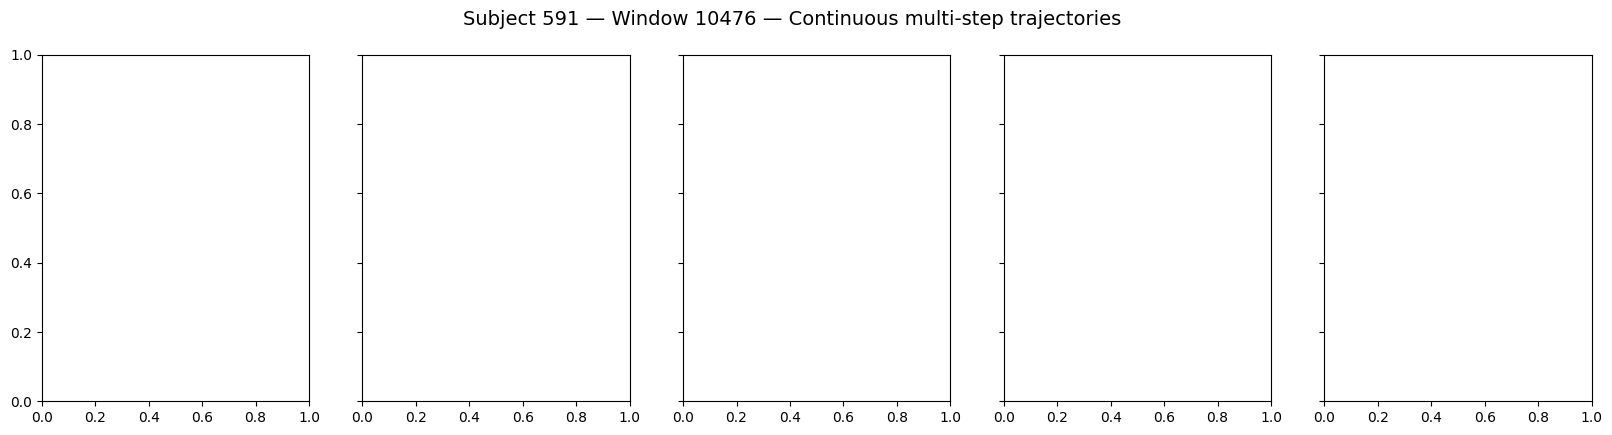

In [ ]:
# --------------------------
# UPDATED PLOTTING SECTION (continuous multi-step trajectories, separate figure per sampled window)
# Only this plotting section changed — everything else unchanged.
# For each selected subject, each randomly sampled window gets its own figure.
# Each subplot shows the actual multi-step trajectory (black '-o-') and predicted trajectory (colored dashed),
# producing continuous-looking trajectories per model without stacking.
# --------------------------
import random

model_order = ['persistence','bergman','lstm','ml_corrector', 'pinn']
n_models = len(model_order)
selected_sids = list(per_subject_test.keys())[:3]  # first 3 test subjects
t_h = np.arange(1, N_OUT+1) * 5  # [5,10,...,30] minutes ahead
n_samples = 3  # number of random windows per subject to plot

if len(selected_sids) == 0:
    print("No test subjects available for plotting.")
else:
    random.seed(42)  # reproducibility
    for sid in selected_sids:
        info = per_subject_test[sid]
        X_test = info['X']        # shape (n_windows, N_IN, feats)
        y_test = info['y']        # shape (n_windows, N_OUT, 1) or (n_windows, N_OUT)
        if X_test.shape[0] == 0:
            continue

        n_windows = X_test.shape[0]
        sample_indices = random.sample(range(n_windows), min(n_samples, n_windows))

        # prepare actual multi-step targets (mg/dL)
        y_test_arr = np.asarray(y_test)
        if y_test_arr.ndim == 3 and y_test_arr.shape[-1] == 1:
            y_test_flat_scaled = y_test_arr.reshape(y_test_arr.shape[0], y_test_arr.shape[1])
        else:
            y_test_flat_scaled = y_test_arr
        y_test_mg = inv_cgm_with_cg_scaler(y_test_flat_scaled)  # (n_windows, N_OUT)

        # for each randomly sampled window, create a separate figure
        for idx in sample_indices:
            actual_traj = y_test_mg[idx]

            fig, axs = plt.subplots(1, n_models, figsize=(20, 4.5), sharey=True)
            fig.suptitle(f"Subject {sid} — Window {idx} — Continuous multi-step trajectories", fontsize=14)

            for i_m, mname in enumerate(model_order):
                ax = axs[i_m]

                # get model prediction for this subject
                yhat_scaled_all = models[mname](sid)
                yhat_scaled_all = np.asarray(yhat_scaled_all)
                if yhat_scaled_all.size == 0:
                    ax.text(0.5, 0.5, "no preds", ha='center', va='center')
                    ax.set_title(mname)
                    continue
                if yhat_scaled_all.ndim == 3 and yhat_scaled_all.shape[-1] == 1:
                    yhat_scaled_all = yhat_scaled_all.reshape(yhat_scaled_all.shape[0], yhat_scaled_all.shape[1])
                yhat_mg_all = inv_cgm_with_cg_scaler(yhat_scaled_all)  # (n_windows, N_OUT)

                pred_traj = yhat_mg_all[idx]

                # plot actual multi-step trajectory (black '-o-')
                ax.plot(t_h, actual_traj, '-o', color='black', markersize=6, linewidth=1.4)
                # plot predicted trajectory (colored dashed)
                color = 'tab:orange' if mname=='persistence' else ('tab:green' if mname=='bergman' else ('tab:blue' if mname=='lstm' else 'tab:red') if mname=='ml_corrector' else 'purple' if mname=='pinn' else 'gray')
                ax.plot(t_h, pred_traj, '--', color=color, linewidth=2.0)

                ax.set_title(mname)
                ax.set_xlabel('Minutes ahead')
                if i_m == 0:
                    ax.set_ylabel('Glucose (mg/dL)')
                ax.set_xticks(t_h)
                ax.set_xlim(0.5, t_h[-1] + 1)
                ax.axhline(HYPO, color='gray', linestyle=':', linewidth=0.8)
                ax.set_ylim(40, 300)
                ax.grid(True, linestyle=':')

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()


## Feature Importance - SHAP - LSTM + ML Corrector

Running SHAP KernelExplainer for LSTM (this may take a while depending on nsamples)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


  0%|          | 0/15 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


  7%|▋         | 1/15 [00:00<00:09,  1.45it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


...

 87%|████████▋ | 13/15 [00:08<00:01,  1.58it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


 93%|█████████▎| 14/15 [00:09<00:00,  1.57it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


100%|██████████| 15/15 [00:09<00:00,  1.54it/s]



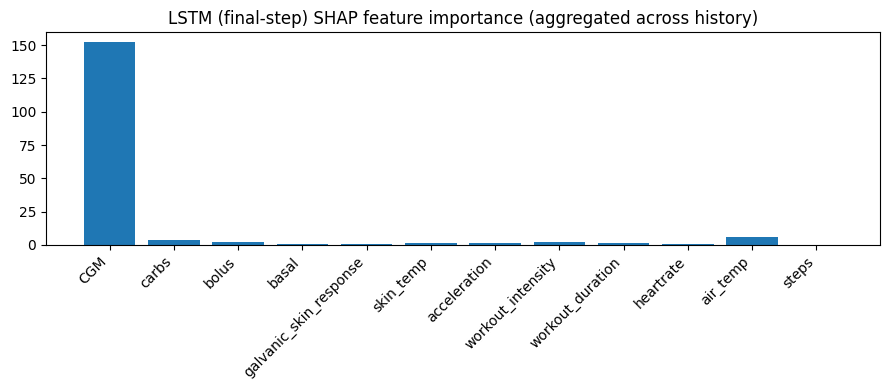

Running SHAP KernelExplainer for ML-corrector (this may take a while)...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


  0%|          | 0/15 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


  7%|▋         | 1/15 [00:00<00:08,  1.59it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


...

 87%|████████▋ | 13/15 [00:08<00:01,  1.58it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


 93%|█████████▎| 14/15 [00:08<00:00,  1.58it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


100%|██████████| 15/15 [00:09<00:00,  1.57it/s]



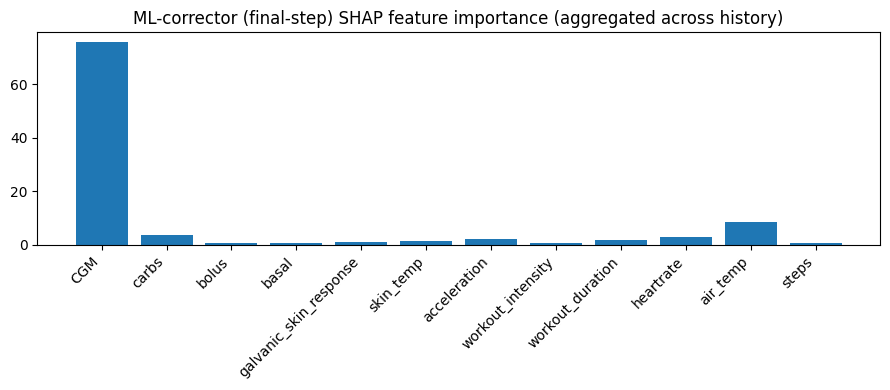

SHAP (or fallback) feature importance completed.


In [ ]:
# Cell 8 (REPLACED): SHAP feature importance for vanilla-LSTM and ML-corrector (final-step)
# Fixes "Cannot take the length of shape with unknown rank."
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# --- Helpers ------------------------------------------------------
def reshape_for_shap(X):
    """Flatten time x features into 2D for KernelExplainer."""
    X = np.asarray(X)
    return X.reshape(X.shape[0], -1)

def unflatten_from_shap(flat, n_in=N_IN, n_feats=None):
    flat = np.asarray(flat)
    if n_feats is None:
        raise ValueError("n_feats must be provided")
    return flat.reshape(flat.shape[0], n_in, n_feats)

# background sample (small)
if 'X_tr_all' in globals() and X_tr_all.shape[0] > 0:
    bg_n = min(50, X_tr_all.shape[0])
    bg_sample = X_tr_all[np.random.choice(X_tr_all.shape[0], size=bg_n, replace=False)]
else:
    # fallback: collect some windows from per_subject_train if available
    bg_list = []
    for sid,info in per_subject_train.items():
        if info['X'].shape[0] > 0:
            bg_list.append(info['X'][0])
        if len(bg_list) >= 10:
            break
    if len(bg_list) == 0:
        raise RuntimeError("No training windows found for background SHAP sample.")
    bg_sample = np.stack(bg_list)

bg_flat = reshape_for_shap(bg_sample)  # (bg_n, N_IN * n_feats)

# small set of test windows to explain
test_list = []
for sid,info in per_subject_test.items():
    if info['X'].shape[0] > 0:
        # take up to 5 windows per subject (keeps explainer small)
        take = min(5, info['X'].shape[0])
        for i in range(take):
            test_list.append(info['X'][i])
    if len(test_list) >= 20:
        break
if len(test_list) == 0:
    # fallback to bg
    test_windows = bg_sample[:5]
else:
    test_windows = np.stack(test_list[:20])

test_flat = reshape_for_shap(test_windows)

# sanity: n_feats detection
if 'n_feats' not in globals():
    # Try to deduce from X_tr_all shape or from test_windows
    if 'X_tr_all' in globals() and X_tr_all.size:
        n_feats = X_tr_all.shape[2]
    else:
        n_feats = test_windows.shape[2]

# --- Wrapper functions that accept 2D flattened arrays (explainer interface) -------
def lstm_predict_final_mgdl_flat(X_flat_2d):
    """
    Input: X_flat_2d shape (m, N_IN * n_feats)
    Output: 1D array (m,) of predicted final-step glucose in mg/dL
    """
    X = np.asarray(X_flat_2d)
    # reshape back to (m, N_IN, n_feats) and call model
    X3 = unflatten_from_shap(X, n_in=N_IN, n_feats=n_feats)
    # model expects scaled inputs with shape (m, N_IN, n_feats)
    yhat = lstm_model.predict(X3, batch_size=64)
    # yhat shape (m, n_out) (we trained to output n_out)
    yhat_arr = np.asarray(yhat).reshape(-1, n_out)
    final_scaled = yhat_arr[:, -1].reshape(-1,1)
    final_mgdl = cg_scaler.inverse_transform(final_scaled).reshape(-1)
    return final_mgdl

def corr_predict_final_mgdl_flat(X_flat_2d):
    """
    ML-corrector wrapper: returns corrected final-step mg/dL.
    We approximate bergman baseline using last CGM in input sequence.
    Input: flattened X -> reshape -> predict residual with model_corr -> add to last_cgm (inverse scaled)
    """
    X = np.asarray(X_flat_2d)
    X3 = unflatten_from_shap(X, n_in=N_IN, n_feats=n_feats)
    resid = model_corr.predict(X3)  # shape (m, n_out)
    resid = np.asarray(resid).reshape(-1, n_out)
    resid_final = resid[:, -1].reshape(-1,1)
    last_cgm_scaled = X3[:, -1, 0].reshape(-1,1)  # first channel is CGM scaled
    last_cgm_mg = cg_scaler.inverse_transform(last_cgm_scaled).reshape(-1,1)
    resid_mg = cg_scaler.inverse_transform(resid_final).reshape(-1,1)
    corrected_final = (last_cgm_mg + resid_mg).reshape(-1)
    return corrected_final

# --- Run KernelExplainer (with fallback) ------------------------------------------
print("Running SHAP KernelExplainer for LSTM (this may take a while depending on nsamples)...")
try:
    explainer = shap.KernelExplainer(lstm_predict_final_mgdl_flat, bg_flat)
    shap_vals = explainer.shap_values(test_flat, nsamples=200)  # shape (n_samples, n_features_flat)
    shap_arr = np.asarray(shap_vals)
    mean_abs = np.mean(np.abs(shap_arr), axis=0)  # mean abs across explained samples
    mean_abs_ts = mean_abs.reshape(N_IN, n_feats)  # (time, feat)
    per_feature_importance_lstm = mean_abs_ts.sum(axis=0)  # sum across time
    # plot
    feat_names = ['CGM'] + ['carbs','bolus','basal','galvanic_skin_response','skin_temp',
                            'acceleration','workout_intensity','workout_duration','heartrate','air_temp','steps']
    plt.figure(figsize=(9,4))
    plt.bar(np.arange(len(feat_names)), per_feature_importance_lstm)
    plt.xticks(np.arange(len(feat_names)), feat_names, rotation=45, ha='right')
    plt.title('LSTM (final-step) SHAP feature importance (aggregated across history)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("KernelExplainer for LSTM failed with error:", str(e))
    print("Falling back to simple correlation-based feature importance (fast).")
    # fallback: compute corr between each flattened feature and model final predictions
    preds_final = lstm_predict_final_mgdl_flat(bg_flat)  # use bg_flat predictions as proxy
    flat_bg = bg_flat
    n_flat = flat_bg.shape[1]
    mean_abs_corr = []
    for f in range(n_flat):
        col = flat_bg[:, f]
        # ignore constant columns
        if np.nanstd(col) < 1e-8:
            mean_abs_corr.append(0.0)
        else:
            mean_abs_corr.append(abs(np.corrcoef(col, preds_final)[0,1]))
    mean_abs_corr = np.array(mean_abs_corr)
    mean_abs_ts = mean_abs_corr.reshape(N_IN, n_feats)
    per_feature_importance_lstm = mean_abs_ts.sum(axis=0)
    feat_names = ['CGM'] + ['carbs','bolus','basal','galvanic_skin_response','skin_temp',
                            'acceleration','workout_intensity','workout_duration','heartrate','air_temp','steps']
    plt.figure(figsize=(9,4))
    plt.bar(np.arange(len(feat_names)), per_feature_importance_lstm)
    plt.xticks(np.arange(len(feat_names)), feat_names, rotation=45, ha='right')
    plt.title('LSTM fallback corr-based feature importance')
    plt.tight_layout()
    plt.show()

# --- ML-corrector SHAP (similar) ----------------------------------------------------
print("Running SHAP KernelExplainer for ML-corrector (this may take a while)...")
try:
    explainer_corr = shap.KernelExplainer(corr_predict_final_mgdl_flat, bg_flat)
    shap_vals_corr = explainer_corr.shap_values(test_flat, nsamples=200)
    shap_arr_corr = np.asarray(shap_vals_corr)
    mean_abs_corr = np.mean(np.abs(shap_arr_corr), axis=0)
    mean_abs_ts_corr = mean_abs_corr.reshape(N_IN, n_feats)
    per_feature_importance_corr = mean_abs_ts_corr.sum(axis=0)
    # plot
    plt.figure(figsize=(9,4))
    plt.bar(np.arange(len(feat_names)), per_feature_importance_corr)
    plt.xticks(np.arange(len(feat_names)), feat_names, rotation=45, ha='right')
    plt.title('ML-corrector (final-step) SHAP feature importance (aggregated across history)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("KernelExplainer for ML-corrector failed with error:", str(e))
    print("Falling back to simple correlation-based feature importance (fast).")
    preds_corr = corr_predict_final_mgdl_flat(bg_flat)
    mean_abs_corr = []
    for f in range(bg_flat.shape[1]):
        col = bg_flat[:, f]
        if np.nanstd(col) < 1e-8:
            mean_abs_corr.append(0.0)
        else:
            mean_abs_corr.append(abs(np.corrcoef(col, preds_corr)[0,1]))
    mean_abs_corr = np.array(mean_abs_corr)
    mean_abs_ts_corr = mean_abs_corr.reshape(N_IN, n_feats)
    per_feature_importance_corr = mean_abs_ts_corr.sum(axis=0)
    plt.figure(figsize=(9,4))
    plt.bar(np.arange(len(feat_names)), per_feature_importance_corr)
    plt.xticks(np.arange(len(feat_names)), feat_names, rotation=45, ha='right')
    plt.title('ML-corrector fallback corr-based feature importance')
    plt.tight_layout()
    plt.show()

print("SHAP (or fallback) feature importance completed.")